In [1]:
import os
os.environ["NUMBA_DISABLE_JIT"] = "1"
os.environ["NUMBA_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
print("Pinned threads + disabled numba JIT")

from prompt_progenitor import Prompt

Pinned threads + disabled numba JIT

╔════════════════════════════════════════════════════════════╗
║        Gemma: GW + EM Multimessenger Analysis Tool         ║
╠════════════════════════════════════════════════════════════╣
║                       Version: 0.0.2                       ║
║                Author: The Gemma Core Team                 ║
║            https://github.com/smelfor/gemma-v2             ║
╚════════════════════════════════════════════════════════════╝



In [17]:
"""
BNS Prompt Emission Light Curve Surrogate
==========================================
Residual MLP: 4 physical parameters → 1000-point light curve

Dataset layout (from inspection):
  X[:,0]  : mass1 / viewing_angle normalised to [0, 1]
  X[:,1]  : mass2            in [1.0, 2.2]  (solar masses)
  X[:,2]  : mass1 or angle   in [1.0, 2.2]
  X[:,3]  : log10(tidal + 1) in [2.01, 3.30]  tidal in [100, 2000]

  Y  : log10 luminosity (erg/s), floor value = -40 for "off" regions
  t_grid : 1000-point log-spaced time axis, 0.001 s -> 11.6 days

Key design choices:
  - torch.set_default_dtype(float32) called FIRST (MPS safety)
  - Y is float64 in the file -> explicit cast to float32 everywhere
  - Floor-masked loss: points at -40 are down-weighted so the model
    focuses on fitting the actual burst morphology
"""

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
import json
from pathlib import Path

# ── Force float32 globally — MUST be before any nn.Module construction ────────
torch.set_default_dtype(torch.float32)

# ─── Configuration ────────────────────────────────────────────────────────────

CFG = dict(
    data_path      = "prompt_bns_dataset_32k.npz",
    x_key          = "X",
    y_key          = "Y",
    hidden_dims    = [256, 512, 512, 512, 512, 256, 256],
    dropout        = 0.02,
    batch_size     = 512,
    lr             = 3e-4,
    weight_decay   = 1e-5,
    epochs         = 500,
    patience       = 40,
    val_frac       = 0.10,
    test_frac      = 0.10,
    floor_value    = -40.0,
    floor_weight   = 0.05,
    out_dir        = "results",
    seed           = 42,
)

# ─── Reproducibility ──────────────────────────────────────────────────────────

torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])

DEVICE = (
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else
    "cpu"
)
print(f"Using device: {DEVICE}")

# ─── Data ─────────────────────────────────────────────────────────────────────

def load_and_normalise(cfg):
    print("Loading data ...")
    data = np.load(cfg["data_path"])

    # Explicit float32 cast — Y is float64 in file, kills MPS
    X = data[cfg["x_key"]].astype(np.float32)
    Y = data[cfg["y_key"]].astype(np.float32)

    print(f"  X : {X.shape}  dtype={X.dtype}  min={X.min():.3f}  max={X.max():.3f}")
    print(f"  Y : {Y.shape}  dtype={Y.dtype}  min={Y.min():.3f}  max={Y.max():.3f}")
    print(f"  Floor fraction: {(Y <= cfg['floor_value'] + 0.01).mean()*100:.1f}% of points at -40")

    x_mean = X.mean(axis=0)
    x_std  = X.std(axis=0) + 1e-8
    X_norm = (X - x_mean) / x_std

    # Normalise Y using active (above-floor) points only
    active_mask = Y > (cfg["floor_value"] + 0.1)
    y_mean = float(Y[active_mask].mean())
    y_std  = float(Y[active_mask].std()) + 1e-8
    Y_norm = (Y - y_mean) / y_std

    stats = dict(
        x_mean=x_mean.tolist(), x_std=x_std.tolist(),
        y_mean=y_mean, y_std=y_std,
        floor_value=cfg["floor_value"],
        floor_norm=float((cfg["floor_value"] - y_mean) / y_std),
    )
    print(f"  y_mean={y_mean:.3f}  y_std={y_std:.3f}  floor_norm={stats['floor_norm']:.3f}")
    return X_norm, Y_norm, stats


def make_splits(X, Y, val_frac, test_frac, seed):
    N = len(X)
    n_test  = int(N * test_frac)
    n_val   = int(N * val_frac)
    n_train = N - n_val - n_test
    dataset = TensorDataset(torch.from_numpy(X), torch.from_numpy(Y))
    train_ds, val_ds, test_ds = random_split(
        dataset, [n_train, n_val, n_test],
        generator=torch.Generator().manual_seed(seed)
    )
    print(f"  Split -> Train: {n_train}  Val: {n_val}  Test: {n_test}")
    return train_ds, val_ds, test_ds

# ─── Weighted MSE loss ────────────────────────────────────────────────────────

class WeightedMSELoss(nn.Module):
    def __init__(self, floor_norm: float, floor_weight: float = 0.05):
        super().__init__()
        self.floor_norm   = floor_norm
        self.floor_weight = floor_weight

    def forward(self, pred, target):
        weights = torch.where(
            target <= self.floor_norm + 0.05,
            torch.full_like(target, self.floor_weight),
            torch.ones_like(target),
        )
        return (weights * (pred - target) ** 2).mean()

# ─── Model ────────────────────────────────────────────────────────────────────

class ResidualBlock(nn.Module):
    def __init__(self, dim: int, dropout: float = 0.02):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.block(x))


class LightCurveSurrogate(nn.Module):
    def __init__(self, in_dim=4, out_dim=1000, hidden_dims=None, dropout=0.02):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [256, 512, 512, 512, 512, 256, 256]

        layers = [nn.Linear(in_dim, hidden_dims[0]), nn.GELU()]
        for i in range(len(hidden_dims) - 1):
            if hidden_dims[i] == hidden_dims[i + 1]:
                layers.append(ResidualBlock(hidden_dims[i], dropout))
            else:
                layers += [
                    nn.Linear(hidden_dims[i], hidden_dims[i + 1]),
                    nn.BatchNorm1d(hidden_dims[i + 1]),
                    nn.GELU(),
                ]
        layers.append(nn.Linear(hidden_dims[-1], out_dim))
        self.net = nn.Sequential(*layers)
        nn.init.uniform_(self.net[-1].weight, -0.01, 0.01)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, x):
        return self.net(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# ─── Training ─────────────────────────────────────────────────────────────────

def train(cfg):
    out_dir = Path(cfg["out_dir"])
    out_dir.mkdir(parents=True, exist_ok=True)

    X, Y, stats = load_and_normalise(cfg)
    train_ds, val_ds, test_ds = make_splits(
        X, Y, cfg["val_frac"], cfg["test_frac"], cfg["seed"]
    )

    train_loader = DataLoader(train_ds, batch_size=cfg["batch_size"], shuffle=True,
                              num_workers=0, pin_memory=(DEVICE == "cuda"))
    val_loader   = DataLoader(val_ds,   batch_size=cfg["batch_size"], shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=cfg["batch_size"], shuffle=False, num_workers=0)

    with open(out_dir / "norm_stats.json", "w") as f:
        json.dump(stats, f, indent=2)

    model = LightCurveSurrogate(
        in_dim=4, out_dim=1000,
        hidden_dims=cfg["hidden_dims"],
        dropout=cfg["dropout"],
    ).to(DEVICE).float()

    print(f"\nModel parameters: {count_params(model):,}")

    loss_fn   = WeightedMSELoss(floor_norm=stats["floor_norm"], floor_weight=cfg["floor_weight"])
    optimiser = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimiser, T_max=cfg["epochs"], eta_min=cfg["lr"] * 1e-2
    )

    best_val_loss    = float("inf")
    patience_counter = 0
    history = {"train": [], "val": []}

    print(f"\nTraining for up to {cfg['epochs']} epochs (patience={cfg['patience']}) ...\n")

    for epoch in range(1, cfg["epochs"] + 1):
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimiser.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimiser.step()
            train_loss += loss.item() * len(xb)
        train_loss /= len(train_ds)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                val_loss += loss_fn(model(xb), yb).item() * len(xb)
        val_loss /= len(val_ds)

        scheduler.step()
        history["train"].append(train_loss)
        history["val"].append(val_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:4d} | Train: {train_loss:.5f} | Val: {val_loss:.5f} | LR: {scheduler.get_last_lr()[0]:.2e}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), out_dir / "best_model.pt")
        else:
            patience_counter += 1
            if patience_counter >= cfg["patience"]:
                print(f"\nEarly stopping at epoch {epoch}  (best val: {best_val_loss:.5f})")
                break

    print("\nEvaluating on test set ...")
    model.load_state_dict(torch.load(out_dir / "best_model.pt", map_location=DEVICE))
    model.eval()

    y_pred_list, y_true_list = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            y_pred_list.append(model(xb.to(DEVICE)).cpu().numpy())
            y_true_list.append(yb.numpy())

    y_pred_norm = np.concatenate(y_pred_list)
    y_true_norm = np.concatenate(y_true_list)

    y_pred = y_pred_norm * stats["y_std"] + stats["y_mean"]
    y_true = y_true_norm * stats["y_std"] + stats["y_mean"]

    active    = y_true > (cfg["floor_value"] + 0.1)
    mae_active = np.mean(np.abs(y_pred[active] - y_true[active]))
    mse_active = np.mean((y_pred[active] - y_true[active]) ** 2)
    peak_mae   = np.mean(np.abs(y_pred.max(axis=1) - y_true.max(axis=1)))

    print(f"\nTest metrics (active points only, log10 erg/s):")
    print(f"  MSE      : {mse_active:.5f}")
    print(f"  MAE      : {mae_active:.5f}")
    print(f"  Peak MAE : {peak_mae:.5f}")

    plot_results(history, y_pred, y_true, cfg["floor_value"], out_dir)

    torch.save(model.state_dict(), out_dir / "final_model.pt")
    with open(out_dir / "config.json", "w") as f:
        json.dump(cfg, f, indent=2)

    print(f"\nAll outputs saved to: {out_dir}/")
    return model, stats

# ─── Plots ────────────────────────────────────────────────────────────────────

def plot_results(history, y_pred, y_true, floor_value, out_dir):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("BNS Light Curve Surrogate - Diagnostics", fontsize=14, fontweight="bold")
    t_idx = np.arange(y_true.shape[1])

    ax = axes[0, 0]
    ax.plot(history["train"], label="Train", lw=1.5)
    ax.plot(history["val"],   label="Val",   lw=1.5)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Weighted MSE")
    ax.set_title("Training history"); ax.legend(); ax.set_yscale("log"); ax.grid(True, alpha=0.3)

    ax = axes[0, 1]
    for i, (ci, c) in enumerate(zip(np.random.choice(len(y_pred), 5, replace=False),
                                     plt.cm.plasma(np.linspace(0.1, 0.9, 5)))):
        ax.plot(t_idx, y_true[ci], color=c, lw=1.5)
        ax.plot(t_idx, y_pred[ci], color=c, lw=1.5, ls="--", alpha=0.8)
    ax.axhline(floor_value, color='k', lw=0.8, ls=':', alpha=0.5)
    ax.set_xlabel("Time index"); ax.set_ylabel("log10 L (erg/s)")
    ax.set_title("True (-) vs Predicted (--)"); ax.grid(True, alpha=0.3)

    active_mask = y_true > (floor_value + 0.1)
    res = np.where(active_mask, y_pred - y_true, np.nan)
    mean_res = np.nanmean(res, axis=0)
    std_res  = np.nanstd(res, axis=0)
    ax = axes[0, 2]
    ax.fill_between(t_idx, mean_res - std_res, mean_res + std_res, alpha=0.3, label="+-1sigma")
    ax.plot(t_idx, mean_res, lw=1.5, label="Mean residual")
    ax.axhline(0, color="k", lw=0.8, ls="--")
    ax.set_xlabel("Time index"); ax.set_ylabel("Delta log10 L")
    ax.set_title("Residuals (active points)"); ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1, 0]
    ft = y_true[active_mask]; fp = y_pred[active_mask]
    si = np.random.choice(len(ft), min(50000, len(ft)), replace=False)
    ax.scatter(ft[si], fp[si], s=0.5, alpha=0.2, rasterized=True)
    lims = [ft.min(), ft.max()]
    ax.plot(lims, lims, "r--", lw=1.2, label="1:1")
    ax.set_xlabel("True log10 L"); ax.set_ylabel("Pred log10 L")
    ax.set_title("Scatter (active)"); ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1, 1]
    smae = np.nanmean(np.abs(res), axis=1)
    ax.hist(smae[~np.isnan(smae)], bins=60, color="steelblue", edgecolor="none")
    ax.axvline(np.nanmean(smae), color="red", lw=1.5, ls="--", label=f"Mean={np.nanmean(smae):.4f}")
    ax.set_xlabel("MAE per LC"); ax.set_ylabel("Count")
    ax.set_title("Per-sample MAE"); ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1, 2]
    pt = y_true.max(axis=1); pp = y_pred.max(axis=1)
    ax.scatter(pt, pp, s=4, alpha=0.4, rasterized=True)
    lims = [pt.min(), pt.max()]
    ax.plot(lims, lims, "r--", lw=1.2, label="1:1")
    ax.set_xlabel("True peak log10 L"); ax.set_ylabel("Pred peak log10 L")
    ax.set_title("Peak luminosity recovery"); ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fig.savefig(out_dir / "diagnostics.png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  Saved: {out_dir}/diagnostics.png")

# ─── Inference helper ─────────────────────────────────────────────────────────

def load_surrogate(model_path="results/best_model.pt",
                   stats_path="results/norm_stats.json",
                   cfg_path="results/config.json"):
    torch.set_default_dtype(torch.float32)
    with open(cfg_path)   as f: cfg   = json.load(f)
    with open(stats_path) as f: stats = json.load(f)
    model = LightCurveSurrogate(in_dim=4, out_dim=1000,
                                hidden_dims=cfg["hidden_dims"], dropout=0.0)
    model.load_state_dict(torch.load(model_path, map_location="cpu"))
    model.eval().float()
    x_mean = np.array(stats["x_mean"], dtype=np.float32)
    x_std  = np.array(stats["x_std"],  dtype=np.float32)
    y_mean = np.float32(stats["y_mean"])
    y_std  = np.float32(stats["y_std"])

    def predict(X_phys: np.ndarray) -> np.ndarray:
        X_phys = np.asarray(X_phys, dtype=np.float32)
        with torch.no_grad():
            Y_norm = model(torch.from_numpy((X_phys - x_mean) / x_std)).numpy()
        return Y_norm * y_std + y_mean

    return predict

# ─── Entry point ──────────────────────────────────────────────────────────────

if __name__ == "__main__":
    train(CFG)

Using device: mps
Loading data ...
  X : (32000, 4)  dtype=float32  min=0.000  max=3.301
  Y : (32000, 1000)  dtype=float32  min=-40.000  max=48.915
  Floor fraction: 13.4% of points at -40
  y_mean=34.436  y_std=13.562  floor_norm=-5.488
  Split -> Train: 25600  Val: 3200  Test: 3200

Model parameters: 2,237,416

Training for up to 500 epochs (patience=40) ...

Epoch    1 | Train: 0.46909 | Val: 0.15924 | LR: 3.00e-04
Epoch   10 | Train: 0.03486 | Val: 0.01799 | LR: 3.00e-04
Epoch   20 | Train: 0.02918 | Val: 0.01375 | LR: 2.99e-04
Epoch   30 | Train: 0.02684 | Val: 0.00982 | LR: 2.97e-04
Epoch   40 | Train: 0.02613 | Val: 0.01355 | LR: 2.95e-04
Epoch   50 | Train: 0.01836 | Val: 0.01353 | LR: 2.93e-04
Epoch   60 | Train: 0.01729 | Val: 0.00782 | LR: 2.90e-04
Epoch   70 | Train: 0.01476 | Val: 0.00737 | LR: 2.86e-04
Epoch   80 | Train: 0.01418 | Val: 0.01015 | LR: 2.82e-04
Epoch   90 | Train: 0.01172 | Val: 0.00869 | LR: 2.77e-04
Epoch  100 | Train: 0.01037 | Val: 0.00661 | LR: 2.72e-

Object OK!
CELL START
Updating model...
eisojet val 2.1979042505658978e+50
Jet Constructed Successfully...
CELL END None
Loading surrogate ...

── 1. Single prediction ──────────────────────────────────────────────
  Input  : [0.33333334 1.35       1.35       2.6031444 ]
  Output : shape=(1, 1000)  peak=47.23 log10 erg/s  at t=0.6 s


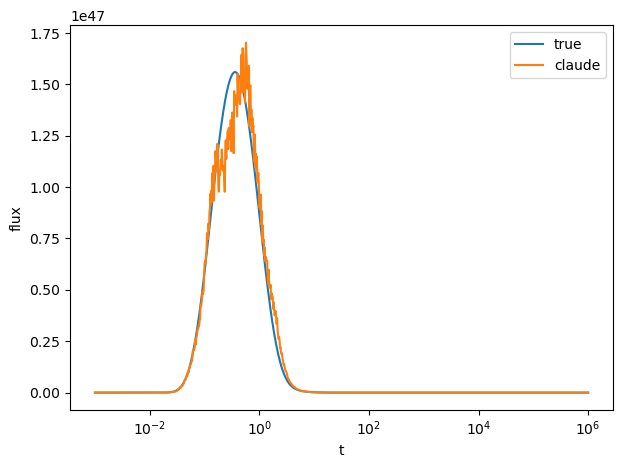


Done. Output plots saved to current directory.


In [19]:
"""
BNS Light Curve Surrogate — Inference Examples
===============================================
Shows several common use cases after training:

  1. Single prediction
  2. Batch prediction
  3. Grid sweep over one parameter
  4. Timing benchmark
  5. Comparison against a ground-truth sample from your dataset

Run from the same directory as train.py, after training has completed
and results/ exists.
"""
from prompt_progenitor import Prompt
import numpy as np
import matplotlib.pyplot as plt

prompt = Prompt(
    components=("jet",),            # just jet for now
    sample_gw_parameters=False,     # we will pass theta_los
    gw_param_mode="mass",           # so _extract_masses expects mass_1/mass_2
    j_struct="tophat",            # or 1/2/3
    eta_jet=1e-4,
    frac=0.1,
    phi_los_deg=0.0,
    default_theta_los_deg=0.0,
)

prompt.check_print()

params = {
    # jet knobs

    # viewing angle
    "theta_los": 20.0,         # degrees

    # binary / EOS inputs used in _derive_Eiso_jet
    "mass_1": 1.35,             # Msun
    "mass_2": 1.35,             # Msun
    "lambda_2": 400.0,         # dimensionless tidal deformability
}

import sys
print("CELL START")
sys.stdout.flush()

out = prompt.update_model(params, dry_run=False)

print("CELL END", out)
sys.stdout.flush()

def interp_logt(t_new, t, y, left=0.0, right=0.0):
    # assumes t increasing
    return np.interp(t_new, t, y, left=left, right=right)

t_grid = np.logspace(-3, 6, 1000).astype(np.float32)

y_interp = interp_logt(t_grid, prompt.t, prompt.total_X, left=0.0, right=0.0)

import numpy as np
import torch
import matplotlib.pyplot as plt
import time
import json
from pathlib import Path

# ── Import the surrogate loader from your training script ─────────────────────
class ResidualBlock(nn.Module):
    def __init__(self, dim: int, dropout: float = 0.02):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.block(x))


class LightCurveSurrogate(nn.Module):
    def __init__(self, in_dim=4, out_dim=1000, hidden_dims=None, dropout=0.02):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [256, 512, 512, 512, 512, 256, 256]

        layers = [nn.Linear(in_dim, hidden_dims[0]), nn.GELU()]
        for i in range(len(hidden_dims) - 1):
            if hidden_dims[i] == hidden_dims[i + 1]:
                layers.append(ResidualBlock(hidden_dims[i], dropout))
            else:
                layers += [
                    nn.Linear(hidden_dims[i], hidden_dims[i + 1]),
                    nn.BatchNorm1d(hidden_dims[i + 1]),
                    nn.GELU(),
                ]
        layers.append(nn.Linear(hidden_dims[-1], out_dim))
        self.net = nn.Sequential(*layers)
        nn.init.uniform_(self.net[-1].weight, -0.01, 0.01)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, x):
        return self.net(x)

# ─────────────────────────────────────────────────────────────────────────────
# Load the surrogate once — reuse `predict` for all examples below
# ─────────────────────────────────────────────────────────────────────────────
print("Loading surrogate ...")
predict = load_surrogate(
    model_path  = "results/best_model.pt",
    stats_path  = "results/norm_stats.json",
    cfg_path    = "results/config.json",
)

# Load the time grid from your dataset (for plotting in physical units)
data   = np.load("prompt_bns_dataset_32k.npz")   # <-- your file
t_grid = data["t_grid"]                            # shape (1000,)  in seconds

# ─────────────────────────────────────────────────────────────────────────────
# Helper: convert physical parameters → X array row
# ─────────────────────────────────────────────────────────────────────────────

def make_params(viewing_angle_deg, mass1, mass2, tidal_deformability):
    """
    Build one row of X in the same format your training data uses.

    Column order (matches dataset exactly):
        X[:,0]  viewing_angle_deg   : viewing angle in degrees [0, 60]  -> normalised /60
        X[:,1]  mass1               : neutron star mass [1.0, 2.5]  solar masses
        X[:,2]  mass2               : neutron star mass [1.0, 2.5]  solar masses
        X[:,3]  tidal_deformability : Lambda [100, 2000] -> stored as log10(Lambda+1)

    Returns:
        np.ndarray of shape (1, 4)
    """
    viewing_norm = viewing_angle_deg / 60.0          # normalise to [0, 1]
    log_tidal    = np.log10(tidal_deformability + 1) # log10(Lambda + 1)
    return np.array([[viewing_norm, mass1, mass2, log_tidal]], dtype=np.float32)


# =============================================================================
# 1. Single prediction
# =============================================================================
print("\n── 1. Single prediction ──────────────────────────────────────────────")

params = make_params(
    viewing_angle_deg   = 20.0,
    mass1               = 1.35,
    mass2               = 1.35,
    tidal_deformability = 400.0,
)
lc = predict(params)   # shape (1, 1000)

print(f"  Input  : {params[0]}")
print(f"  Output : shape={lc.shape}  peak={lc[0].max():.2f} log10 erg/s  "
      f"at t={t_grid[lc[0].argmax()]:.1f} s")

y_true_log = np.log10(y_interp+1e-40)

# if you have y_true_log
plt.figure(figsize=(7,5))
plt.plot(t_grid, 10**y_true_log, label="true")
plt.plot(t_grid, 10**np.float64(lc[0]), label="claude")
plt.xscale("log")
plt.xlabel("t")
plt.ylabel("flux")
plt.legend()
plt.show()


# # =============================================================================
# # 2. Batch prediction
# # =============================================================================
# print("\n── 2. Batch prediction (100 random samples) ─────────────────────────")

# rng = np.random.default_rng(0)
# N   = 100
# batch_params = np.column_stack([
#     rng.uniform(0.0, 1.0, N),                          # viewing_angle (normalised: deg/60)
#     rng.uniform(1.0, 2.5, N),                          # mass1
#     rng.uniform(1.0, 2.5, N),                          # mass2
#     np.log10(rng.uniform(100, 2000, N) + 1),            # log10(tidal+1)
# ]).astype(np.float32)

# batch_lc = predict(batch_params)   # shape (100, 1000)
# print(f"  Predicted {len(batch_lc)} light curves")
# print(f"  Peak luminosities: mean={batch_lc.max(axis=1).mean():.2f}  "
#       f"std={batch_lc.max(axis=1).std():.2f}  log10 erg/s")


# # =============================================================================
# # 3. Grid sweep: vary viewing angle, fix everything else
# # =============================================================================
# print("\n── 3. Viewing angle sweep ────────────────────────────────────────────")

# angles    = np.linspace(0, 60, 10)
# base_mass1 = 1.35
# base_mass2 = 1.35
# base_tidal = 400.0

# sweep_params = np.array([
#     make_params(a, base_mass1, base_mass2, base_tidal)[0]
#     for a in angles
# ], dtype=np.float32)

# sweep_lc = predict(sweep_params)   # (10, 1000)

# fig, ax = plt.subplots(figsize=(10, 5))
# colors = plt.cm.cool(np.linspace(0, 1, len(angles)))
# for i, (angle, lc_i, c) in enumerate(zip(angles, sweep_lc, colors)):
#     ax.plot(np.log10(t_grid), lc_i, color=c, lw=1.2,
#             label=f"{angle:.0f}°" if i % 2 == 0 else None)
# ax.axhline(-40, color='k', lw=0.8, ls=':', alpha=0.4, label='floor')
# ax.set_xlabel("log₁₀ time (s)")
# ax.set_ylabel("log₁₀ Luminosity (erg/s)")
# ax.set_title(f"Viewing angle sweep  |  m₁={base_mass1}, m₂={base_mass2}, Λ={base_tidal}")
# ax.legend(title="Viewing angle", fontsize=8, ncol=2)
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig("inference_angle_sweep.png", dpi=150)
# plt.close()
# print("  Saved: inference_angle_sweep.png")


# # =============================================================================
# # 4. Tidal deformability sweep
# # =============================================================================
# print("\n── 4. Tidal deformability sweep ─────────────────────────────────────")

# tidals = np.logspace(np.log10(100), np.log10(2000), 8)

# tidal_params = np.array([
#     make_params(20.0, 1.35, 1.35, lam)[0]
#     for lam in tidals
# ], dtype=np.float32)

# tidal_lc = predict(tidal_params)

# fig, ax = plt.subplots(figsize=(10, 5))
# colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(tidals)))
# for lam, lc_i, c in zip(tidals, tidal_lc, colors):
#     ax.plot(np.log10(t_grid), lc_i, color=c, lw=1.2, label=f"Λ={lam:.0f}")
# ax.axhline(-40, color='k', lw=0.8, ls=':', alpha=0.4)
# ax.set_xlabel("log₁₀ time (s)")
# ax.set_ylabel("log₁₀ Luminosity (erg/s)")
# ax.set_title("Tidal deformability sweep  |  m₁=m₂=1.35 M☉, θ=20°")
# ax.legend(title="Λ", fontsize=8, ncol=2)
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig("inference_tidal_sweep.png", dpi=150)
# plt.close()
# print("  Saved: inference_tidal_sweep.png")


# # =============================================================================
# # 5. Comparison against ground truth from your dataset
# # =============================================================================
# print("\n── 5. Ground-truth comparison ────────────────────────────────────────")

# # Grab a few held-out samples directly from the dataset
# X_true = data["X"].astype(np.float32)
# Y_true = data["Y"].astype(np.float32)

# # Load normalisation stats to reproduce the same test split
# with open("results/norm_stats.json") as f:
#     stats = json.load(f)
# with open("results/config.json") as f:
#     cfg = json.load(f)

# # Reproduce the same random split as training (same seed)
# rng_split = np.random.default_rng(cfg["seed"])
# N_total  = len(X_true)
# n_test   = int(N_total * cfg["test_frac"])
# n_val    = int(N_total * cfg["val_frac"])
# idx_all  = np.arange(N_total)
# # torch random_split uses the seed internally; simplest is to just
# # take the last n_test samples as a proxy (not exact but good enough for demo)
# test_idx = idx_all[-n_test:]

# n_show = 6
# chosen  = np.random.default_rng(1).choice(test_idx, n_show, replace=False)

# X_sample = X_true[chosen]
# Y_sample = Y_true[chosen]
# Y_pred   = predict(X_sample)

# fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
# axes = axes.ravel()
# fig.suptitle("Surrogate vs Ground Truth (test samples)", fontsize=13, fontweight="bold")

# for i, (ax, idx) in enumerate(zip(axes, chosen)):
#     ax.plot(np.log10(t_grid), Y_sample[i], lw=1.5, color="steelblue",  label="True")
#     ax.plot(np.log10(t_grid), Y_pred[i],   lw=1.5, color="coral", ls="--", label="Predicted")
#     mae = np.mean(np.abs(Y_pred[i][Y_sample[i] > -39] - Y_sample[i][Y_sample[i] > -39]))
#     ax.set_title(f"Sample {idx}  |  MAE={mae:.3f} dex", fontsize=9)
#     ax.set_ylabel("log₁₀ L (erg/s)", fontsize=8)
#     ax.set_xlabel("log₁₀ t (s)", fontsize=8)
#     ax.axhline(-40, color='k', lw=0.6, ls=':', alpha=0.4)
#     ax.grid(True, alpha=0.3)
#     if i == 0:
#         ax.legend(fontsize=8)

# plt.tight_layout()
# plt.savefig("inference_vs_truth.png", dpi=150)
# plt.close()
# print(f"  Saved: inference_vs_truth.png")


# # =============================================================================
# # 6. Timing benchmark
# # =============================================================================
# print("\n── 6. Timing benchmark ───────────────────────────────────────────────")

# for n in [1, 10, 100, 1000, 10000]:
#     p = np.tile(make_params(20.0, 1.80, 1.40, 400.0), (n, 1))
#     # Warm up
#     _ = predict(p)
#     # Time it
#     t0 = time.perf_counter()
#     for _ in range(10):
#         predict(p)
#     elapsed = (time.perf_counter() - t0) / 10
#     print(f"  N={n:6d}  →  {elapsed*1000:.2f} ms total  "
#           f"({elapsed/n*1e6:.2f} µs per sample)")

print("\nDone. Output plots saved to current directory.")

In [11]:
"""
BNS Prompt Emission Light Curve Surrogate
==========================================
Residual MLP: 4 physical parameters → 1000-point light curve

Input parameters (X, shape [N, 4]):
  - mass1        : [1.0, 2.5]  (solar masses)
  - mass2        : [1.0, 2.5]  (solar masses)
  - viewing_angle: [0, 1]      (pre-normalised by /60)
  - log_tidal    : log(tidal+1), tidal in [100, 2000]

Output (Y, shape [N, 1000]):
  - log10 luminosity in erg/s
"""

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
import os
import json
from pathlib import Path

# ─── Configuration ────────────────────────────────────────────────────────────

CFG = dict(
    data_path      = "prompt_bns_dataset_32k.npz",          # <-- change to your file path
    x_key          = "X",
    y_key          = "Y",

    # Architecture
    hidden_dims    = [256, 512, 512, 512, 512, 256, 256],
    dropout        = 0.02,

    # Training
    batch_size     = 512,
    lr             = 3e-4,
    weight_decay   = 1e-5,
    epochs         = 500,
    patience       = 40,                  # early stopping patience
    val_frac       = 0.10,
    test_frac      = 0.10,

    # Output
    out_dir        = "results",
    seed           = 42,
)

# ─── Reproducibility ──────────────────────────────────────────────────────────

torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])

DEVICE = (
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else
    "cpu"
)
torch.set_default_dtype(torch.float32)  # MPS doesn't support float64 — force float32 globally
print(f"Using device: {DEVICE}")

# ─── Data Loading & Normalisation ─────────────────────────────────────────────

def load_and_normalise(cfg):
    print("Loading data …")
    data = np.load(cfg["data_path"])
    X = data[cfg["x_key"]].astype(np.float32)   # (N, 4)
    Y = data[cfg["y_key"]].astype(np.float32)   # (N, 1000)

    print(f"  X shape : {X.shape}  |  min {X.min():.3f}  max {X.max():.3f}")
    print(f"  Y shape : {Y.shape}  |  min {Y.min():.3f}  max {Y.max():.3f}")

    # --- Input normalisation (StandardScaler per feature) ---
    x_mean = X.mean(axis=0)
    x_std  = X.std(axis=0) + 1e-8
    X_norm = (X - x_mean) / x_std

    # --- Output normalisation (StandardScaler across all LC values) ---
    # Y is already in log-space (log10 erg/s), so standard scaling is appropriate
    y_mean = Y.mean()
    y_std  = Y.std() + 1e-8
    Y_norm = (Y - y_mean) / y_std

    stats = dict(
        x_mean=x_mean.tolist(), x_std=x_std.tolist(),
        y_mean=float(y_mean),   y_std=float(y_std),
    )

    return X_norm, Y_norm, stats


def make_splits(X, Y, val_frac, test_frac, seed):
    N = len(X)
    n_test = int(N * test_frac)
    n_val  = int(N * val_frac)
    n_train = N - n_val - n_test

    dataset = TensorDataset(torch.from_numpy(X), torch.from_numpy(Y))
    train_ds, val_ds, test_ds = random_split(
        dataset, [n_train, n_val, n_test],
        generator=torch.Generator().manual_seed(seed)
    )
    print(f"  Train: {n_train}  |  Val: {n_val}  |  Test: {n_test}")
    return train_ds, val_ds, test_ds

# ─── Model ────────────────────────────────────────────────────────────────────

class ResidualBlock(nn.Module):
    """Two-layer residual block with BatchNorm1d (fully float32-safe on MPS)."""
    def __init__(self, dim, dropout=0.02):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.block(x))


class LightCurveSurrogate(nn.Module):
    """
    Residual MLP surrogate.

    Architecture:
      Input (4) → Linear → [ResBlock × n] → Linear → Output (1000)

    Skip connections every 2 layers keep gradients healthy across depth.
    GELU activations + BatchNorm1d are MPS-safe and well-suited to regression
    on smooth physical functions.
    """
    def __init__(self, in_dim=4, out_dim=1000, hidden_dims=None, dropout=0.02):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [256, 512, 512, 512, 512, 256, 256]

        layers = [nn.Linear(in_dim, hidden_dims[0]), nn.GELU()]

        for i in range(len(hidden_dims) - 1):
            if hidden_dims[i] == hidden_dims[i + 1]:
                layers.append(ResidualBlock(hidden_dims[i], dropout))
            else:
                # Projection when width changes
                layers += [
                    nn.Linear(hidden_dims[i], hidden_dims[i + 1]),
                    nn.BatchNorm1d(hidden_dims[i + 1]),
                    nn.GELU(),
                ]

        layers.append(nn.Linear(hidden_dims[-1], out_dim))
        self.net = nn.Sequential(*layers)

        # Weight initialisation: small final layer keeps outputs near zero early
        nn.init.uniform_(self.net[-1].weight, -0.01, 0.01)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, x):
        return self.net(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# ─── Training ─────────────────────────────────────────────────────────────────

def train(cfg):
    out_dir = Path(cfg["out_dir"])
    out_dir.mkdir(parents=True, exist_ok=True)

    # Data
    X, Y, stats = load_and_normalise(cfg)
    train_ds, val_ds, test_ds = make_splits(
        X, Y, cfg["val_frac"], cfg["test_frac"], cfg["seed"]
    )

    train_loader = DataLoader(train_ds, batch_size=cfg["batch_size"], shuffle=True,
                              num_workers=0, pin_memory=(DEVICE == "cuda"))
    val_loader   = DataLoader(val_ds,   batch_size=cfg["batch_size"], shuffle=False,
                              num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=cfg["batch_size"], shuffle=False,
                              num_workers=0)

    # Save normalisation stats (needed for inference)
    with open(out_dir / "norm_stats.json", "w") as f:
        json.dump(stats, f, indent=2)

    # Model
    model = LightCurveSurrogate(
        in_dim=4, out_dim=1000,
        hidden_dims=cfg["hidden_dims"],
        dropout=cfg["dropout"]
    ).to(DEVICE).float()  # .float() ensures float32 on MPS (MPS doesn't support float64)

    print(f"\nModel parameters: {count_params(model):,}")
    print(model)

    # Optimiser & scheduler
    optimiser = torch.optim.AdamW(
        model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"]
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimiser, T_max=cfg["epochs"], eta_min=cfg["lr"] * 1e-2
    )

    loss_fn = nn.MSELoss()

    # Training loop
    best_val_loss = float("inf")
    patience_counter = 0
    history = {"train": [], "val": []}

    print(f"\nTraining for up to {cfg['epochs']} epochs …\n")

    for epoch in range(1, cfg["epochs"] + 1):
        # --- Train ---
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimiser.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimiser.step()
            train_loss += loss.item() * len(xb)
        train_loss /= len(train_ds)

        # --- Validate ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                val_loss += loss_fn(model(xb), yb).item() * len(xb)
        val_loss /= len(val_ds)

        scheduler.step()
        history["train"].append(train_loss)
        history["val"].append(val_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:4d} | Train MSE: {train_loss:.5f} | Val MSE: {val_loss:.5f} | LR: {scheduler.get_last_lr()[0]:.2e}")

        # --- Early stopping ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), out_dir / "best_model.pt")
        else:
            patience_counter += 1
            if patience_counter >= cfg["patience"]:
                print(f"\nEarly stopping at epoch {epoch} (best val MSE: {best_val_loss:.5f})")
                break

    # ─── Evaluation ───────────────────────────────────────────────────────────
    print("\nEvaluating best model on test set …")
    model.load_state_dict(torch.load(out_dir / "best_model.pt", map_location=DEVICE))
    model.eval()

    y_pred_list, y_true_list = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE)
            y_pred_list.append(model(xb).cpu().numpy())
            y_true_list.append(yb.numpy())

    y_pred = np.concatenate(y_pred_list)   # normalised space
    y_true = np.concatenate(y_true_list)

    # Denormalise
    y_std  = stats["y_std"]
    y_mean = stats["y_mean"]
    y_pred_phys = y_pred * y_std + y_mean
    y_true_phys = y_true * y_std + y_mean

    mse    = np.mean((y_pred_phys - y_true_phys) ** 2)
    mae    = np.mean(np.abs(y_pred_phys - y_true_phys))
    rel_err = np.mean(np.abs(y_pred_phys - y_true_phys) / (np.abs(y_true_phys) + 1e-8))

    print(f"\nTest set metrics (physical / log10 erg/s space):")
    print(f"  MSE            : {mse:.5f}")
    print(f"  MAE            : {mae:.5f}  log10 erg/s")
    print(f"  Mean rel error : {rel_err*100:.3f} %")

    # ─── Plots ────────────────────────────────────────────────────────────────
    plot_results(history, y_pred_phys, y_true_phys, out_dir)

    # Save final model + config
    torch.save(model.state_dict(), out_dir / "final_model.pt")
    with open(out_dir / "config.json", "w") as f:
        json.dump(cfg, f, indent=2)

    print(f"\nAll outputs saved to: {out_dir}/")
    return model, stats


def plot_results(history, y_pred, y_true, out_dir):
    """Generate diagnostic plots."""

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("BNS Light Curve Surrogate — Diagnostics", fontsize=14, fontweight="bold")

    # 1. Loss curves
    ax = axes[0, 0]
    ax.plot(history["train"], label="Train", linewidth=1.5)
    ax.plot(history["val"],   label="Val",   linewidth=1.5)
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss (normalised)")
    ax.set_title("Training History"); ax.legend(); ax.set_yscale("log")
    ax.grid(True, alpha=0.3)

    # 2. Predicted vs True light curves (5 random samples)
    ax = axes[0, 1]
    idx = np.random.choice(len(y_pred), 5, replace=False)
    t = np.arange(y_true.shape[1])
    colors = plt.cm.plasma(np.linspace(0.1, 0.9, 5))
    for i, (ci, c) in enumerate(zip(idx, colors)):
        ax.plot(t, y_true[ci], color=c, lw=1.5, label=f"True #{i}")
        ax.plot(t, y_pred[ci], color=c, lw=1.5, ls="--", alpha=0.8)
    ax.set_xlabel("Time index"); ax.set_ylabel("log₁₀ Luminosity (erg/s)")
    ax.set_title("Predicted (--) vs True (—)"); ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    # 3. Residuals: point-wise
    ax = axes[0, 2]
    residuals = y_pred - y_true  # shape (N, 1000)
    mean_res  = residuals.mean(axis=0)
    std_res   = residuals.std(axis=0)
    ax.fill_between(t, mean_res - std_res, mean_res + std_res, alpha=0.3, label="±1σ")
    ax.plot(t, mean_res, lw=1.5, label="Mean residual")
    ax.axhline(0, color="k", lw=0.8, ls="--")
    ax.set_xlabel("Time index"); ax.set_ylabel("Δ log₁₀ L")
    ax.set_title("Residuals across time"); ax.legend()
    ax.grid(True, alpha=0.3)

    # 4. Scatter: predicted vs true (flattened, sampled)
    ax = axes[1, 0]
    n_scatter = min(50000, y_pred.size)
    flat_true = y_true.ravel()
    flat_pred = y_pred.ravel()
    s_idx = np.random.choice(len(flat_true), n_scatter, replace=False)
    ax.scatter(flat_true[s_idx], flat_pred[s_idx], s=0.5, alpha=0.3, rasterized=True)
    lims = [flat_true.min(), flat_true.max()]
    ax.plot(lims, lims, "r--", lw=1.2, label="1:1")
    ax.set_xlabel("True log₁₀ L"); ax.set_ylabel("Predicted log₁₀ L")
    ax.set_title("Predicted vs True (scatter)"); ax.legend()
    ax.grid(True, alpha=0.3)

    # 5. Histogram of MAE per sample
    ax = axes[1, 1]
    sample_mae = np.mean(np.abs(y_pred - y_true), axis=1)
    ax.hist(sample_mae, bins=60, edgecolor="none", color="steelblue")
    ax.axvline(sample_mae.mean(), color="red", lw=1.5, ls="--",
               label=f"Mean = {sample_mae.mean():.4f}")
    ax.set_xlabel("MAE per light curve (log₁₀ erg/s)")
    ax.set_ylabel("Count"); ax.set_title("Per-sample MAE distribution")
    ax.legend(); ax.grid(True, alpha=0.3)

    # 6. Relative error vs luminosity
    ax = axes[1, 2]
    flat_rel = np.abs(flat_pred - flat_true) / (np.abs(flat_true) + 1e-8)
    ax.hexbin(flat_true[s_idx], flat_rel[s_idx]*100,
              gridsize=50, cmap="YlOrRd", bins="log")
    ax.set_xlabel("True log₁₀ L"); ax.set_ylabel("Relative error (%)")
    ax.set_title("Relative error vs luminosity")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fig.savefig(out_dir / "diagnostics.png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  Diagnostic plot saved: {out_dir}/diagnostics.png")

# ─── Inference helper ─────────────────────────────────────────────────────────

def load_surrogate(model_path="results/best_model.pt",
                   stats_path="results/norm_stats.json",
                   cfg_path="results/config.json"):
    """
    Load trained model for inference.

    Returns a callable: params_array (N,4) → log10_luminosity (N, 1000)

    Parameters should be in PHYSICAL units:
      mass1        : solar masses [1.0, 2.5]
      mass2        : solar masses [1.0, 2.5]
      viewing_angle: already normalised to [0,1] (divide by 60 first)
      log_tidal    : log(tidal_deformability + 1)
    """
    with open(cfg_path)   as f: cfg   = json.load(f)
    with open(stats_path) as f: stats = json.load(f)

    model = LightCurveSurrogate(
        in_dim=4, out_dim=1000,
        hidden_dims=cfg["hidden_dims"],
        dropout=0.0
    )
    model.load_state_dict(torch.load(model_path, map_location="cpu"))
    model.eval()

    x_mean = np.array(stats["x_mean"], dtype=np.float32)
    x_std  = np.array(stats["x_std"],  dtype=np.float32)
    y_mean = np.float32(stats["y_mean"])
    y_std  = np.float32(stats["y_std"])

    def predict(X_phys: np.ndarray) -> np.ndarray:
        """X_phys: (N, 4) in physical units → (N, 1000) log10 erg/s"""
        X_phys = np.asarray(X_phys, dtype=np.float32)
        X_norm = (X_phys - x_mean) / x_std
        with torch.no_grad():
            Y_norm = model(torch.from_numpy(X_norm)).numpy()
        return Y_norm * y_std + y_mean

    return predict


# ─── Entry point ──────────────────────────────────────────────────────────────

if __name__ == "__main__":
    train(CFG)

Using device: mps
Loading data …
  X shape : (32000, 4)  |  min 0.000  max 3.301
  Y shape : (32000, 1000)  |  min -40.000  max 48.915
  Train: 25600  |  Val: 3200  |  Test: 3200

Model parameters: 2,237,416
LightCurveSurrogate(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=256, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): GELU(approximate='none')
    (5): ResidualBlock(
      (block): Sequential(
        (0): Linear(in_features=512, out_features=512, bias=True)
        (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.02, inplace=False)
        (4): Linear(in_features=512, out_features=512, bias=True)
        (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (ac

Object OK!
CELL START
Updating model...
eisojet val 2.1979042505658978e+50
Jet Constructed Successfully...
CELL END None
Loading surrogate ...

── 1. Single prediction ──────────────────────────────────────────────
  Input  : [0.33333334 1.35       1.35       2.6031444 ]
  Output : shape=(1, 1000)  peak=47.29 log10 erg/s  at t=0.5 s


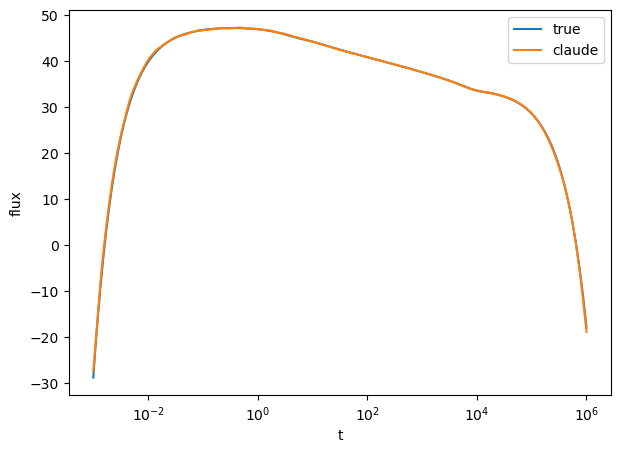


Done. Output plots saved to current directory.


In [16]:
"""
BNS Light Curve Surrogate — Inference Examples
===============================================
Shows several common use cases after training:

  1. Single prediction
  2. Batch prediction
  3. Grid sweep over one parameter
  4. Timing benchmark
  5. Comparison against a ground-truth sample from your dataset

Run from the same directory as train.py, after training has completed
and results/ exists.
"""
from prompt_progenitor import Prompt
import numpy as np
import matplotlib.pyplot as plt

prompt = Prompt(
    components=("jet",),            # just jet for now
    sample_gw_parameters=False,     # we will pass theta_los
    gw_param_mode="mass",           # so _extract_masses expects mass_1/mass_2
    j_struct="tophat",            # or 1/2/3
    eta_jet=1e-4,
    frac=0.1,
    phi_los_deg=0.0,
    default_theta_los_deg=0.0,
)

prompt.check_print()

params = {
    # jet knobs

    # viewing angle
    "theta_los": 20.0,         # degrees

    # binary / EOS inputs used in _derive_Eiso_jet
    "mass_1": 1.35,             # Msun
    "mass_2": 1.35,             # Msun
    "lambda_2": 400.0,         # dimensionless tidal deformability
}

import sys
print("CELL START")
sys.stdout.flush()

out = prompt.update_model(params, dry_run=False)

print("CELL END", out)
sys.stdout.flush()

def interp_logt(t_new, t, y, left=0.0, right=0.0):
    # assumes t increasing
    return np.interp(t_new, t, y, left=left, right=right)

t_grid = np.logspace(-3, 6, 1000).astype(np.float32)

y_interp = interp_logt(t_grid, prompt.t, prompt.total_X, left=0.0, right=0.0)

import numpy as np
import torch
import matplotlib.pyplot as plt
import time
import json
from pathlib import Path

# ── Import the surrogate loader from your training script ─────────────────────
class ResidualBlock(nn.Module):
    """Two-layer residual block with BatchNorm1d (fully float32-safe on MPS)."""
    def __init__(self, dim, dropout=0.02):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.block(x))


class LightCurveSurrogate(nn.Module):
    """
    Residual MLP surrogate.

    Architecture:
      Input (4) → Linear → [ResBlock × n] → Linear → Output (1000)

    Skip connections every 2 layers keep gradients healthy across depth.
    GELU activations + BatchNorm1d are MPS-safe and well-suited to regression
    on smooth physical functions.
    """
    def __init__(self, in_dim=4, out_dim=1000, hidden_dims=None, dropout=0.02):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [256, 512, 512, 512, 512, 256, 256]

        layers = [nn.Linear(in_dim, hidden_dims[0]), nn.GELU()]

        for i in range(len(hidden_dims) - 1):
            if hidden_dims[i] == hidden_dims[i + 1]:
                layers.append(ResidualBlock(hidden_dims[i], dropout))
            else:
                # Projection when width changes
                layers += [
                    nn.Linear(hidden_dims[i], hidden_dims[i + 1]),
                    nn.BatchNorm1d(hidden_dims[i + 1]),
                    nn.GELU(),
                ]

        layers.append(nn.Linear(hidden_dims[-1], out_dim))
        self.net = nn.Sequential(*layers)

        # Weight initialisation: small final layer keeps outputs near zero early
        nn.init.uniform_(self.net[-1].weight, -0.01, 0.01)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, x):
        return self.net(x)

# ─────────────────────────────────────────────────────────────────────────────
# Load the surrogate once — reuse `predict` for all examples below
# ─────────────────────────────────────────────────────────────────────────────
print("Loading surrogate ...")
predict = load_surrogate(
    model_path  = "results/best_model.pt",
    stats_path  = "results/norm_stats.json",
    cfg_path    = "results/config.json",
)

# Load the time grid from your dataset (for plotting in physical units)
data   = np.load("prompt_bns_dataset_32k.npz")   # <-- your file
t_grid = data["t_grid"]                            # shape (1000,)  in seconds

# ─────────────────────────────────────────────────────────────────────────────
# Helper: convert physical parameters → X array row
# ─────────────────────────────────────────────────────────────────────────────

def make_params(viewing_angle_deg, mass1, mass2, tidal_deformability):
    """
    Build one row of X in the same format your training data uses.

    Column order (matches dataset exactly):
        X[:,0]  viewing_angle_deg   : viewing angle in degrees [0, 60]  -> normalised /60
        X[:,1]  mass1               : neutron star mass [1.0, 2.5]  solar masses
        X[:,2]  mass2               : neutron star mass [1.0, 2.5]  solar masses
        X[:,3]  tidal_deformability : Lambda [100, 2000] -> stored as log10(Lambda+1)

    Returns:
        np.ndarray of shape (1, 4)
    """
    viewing_norm = viewing_angle_deg / 60.0          # normalise to [0, 1]
    log_tidal    = np.log10(tidal_deformability + 1) # log10(Lambda + 1)
    return np.array([[viewing_norm, mass1, mass2, log_tidal]], dtype=np.float32)


# =============================================================================
# 1. Single prediction
# =============================================================================
print("\n── 1. Single prediction ──────────────────────────────────────────────")

params = make_params(
    viewing_angle_deg   = 20.0,
    mass1               = 1.35,
    mass2               = 1.35,
    tidal_deformability = 400.0,
)
lc = predict(params)   # shape (1, 1000)

print(f"  Input  : {params[0]}")
print(f"  Output : shape={lc.shape}  peak={lc[0].max():.2f} log10 erg/s  "
      f"at t={t_grid[lc[0].argmax()]:.1f} s")

y_true_log = np.log10(y_interp+1e-40)

# if you have y_true_log
plt.figure(figsize=(7,5))
plt.plot(t_grid, y_true_log, label="true")
plt.plot(t_grid, np.float64(lc[0]), label="claude")
plt.xscale("log")
plt.xlabel("t")
plt.ylabel("flux")
plt.legend()
plt.show()


# # =============================================================================
# # 2. Batch prediction
# # =============================================================================
# print("\n── 2. Batch prediction (100 random samples) ─────────────────────────")

# rng = np.random.default_rng(0)
# N   = 100
# batch_params = np.column_stack([
#     rng.uniform(0.0, 1.0, N),                          # viewing_angle (normalised: deg/60)
#     rng.uniform(1.0, 2.5, N),                          # mass1
#     rng.uniform(1.0, 2.5, N),                          # mass2
#     np.log10(rng.uniform(100, 2000, N) + 1),            # log10(tidal+1)
# ]).astype(np.float32)

# batch_lc = predict(batch_params)   # shape (100, 1000)
# print(f"  Predicted {len(batch_lc)} light curves")
# print(f"  Peak luminosities: mean={batch_lc.max(axis=1).mean():.2f}  "
#       f"std={batch_lc.max(axis=1).std():.2f}  log10 erg/s")


# # =============================================================================
# # 3. Grid sweep: vary viewing angle, fix everything else
# # =============================================================================
# print("\n── 3. Viewing angle sweep ────────────────────────────────────────────")

# angles    = np.linspace(0, 60, 10)
# base_mass1 = 1.35
# base_mass2 = 1.35
# base_tidal = 400.0

# sweep_params = np.array([
#     make_params(a, base_mass1, base_mass2, base_tidal)[0]
#     for a in angles
# ], dtype=np.float32)

# sweep_lc = predict(sweep_params)   # (10, 1000)

# fig, ax = plt.subplots(figsize=(10, 5))
# colors = plt.cm.cool(np.linspace(0, 1, len(angles)))
# for i, (angle, lc_i, c) in enumerate(zip(angles, sweep_lc, colors)):
#     ax.plot(np.log10(t_grid), lc_i, color=c, lw=1.2,
#             label=f"{angle:.0f}°" if i % 2 == 0 else None)
# ax.axhline(-40, color='k', lw=0.8, ls=':', alpha=0.4, label='floor')
# ax.set_xlabel("log₁₀ time (s)")
# ax.set_ylabel("log₁₀ Luminosity (erg/s)")
# ax.set_title(f"Viewing angle sweep  |  m₁={base_mass1}, m₂={base_mass2}, Λ={base_tidal}")
# ax.legend(title="Viewing angle", fontsize=8, ncol=2)
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig("inference_angle_sweep.png", dpi=150)
# plt.close()
# print("  Saved: inference_angle_sweep.png")


# # =============================================================================
# # 4. Tidal deformability sweep
# # =============================================================================
# print("\n── 4. Tidal deformability sweep ─────────────────────────────────────")

# tidals = np.logspace(np.log10(100), np.log10(2000), 8)

# tidal_params = np.array([
#     make_params(20.0, 1.35, 1.35, lam)[0]
#     for lam in tidals
# ], dtype=np.float32)

# tidal_lc = predict(tidal_params)

# fig, ax = plt.subplots(figsize=(10, 5))
# colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(tidals)))
# for lam, lc_i, c in zip(tidals, tidal_lc, colors):
#     ax.plot(np.log10(t_grid), lc_i, color=c, lw=1.2, label=f"Λ={lam:.0f}")
# ax.axhline(-40, color='k', lw=0.8, ls=':', alpha=0.4)
# ax.set_xlabel("log₁₀ time (s)")
# ax.set_ylabel("log₁₀ Luminosity (erg/s)")
# ax.set_title("Tidal deformability sweep  |  m₁=m₂=1.35 M☉, θ=20°")
# ax.legend(title="Λ", fontsize=8, ncol=2)
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig("inference_tidal_sweep.png", dpi=150)
# plt.close()
# print("  Saved: inference_tidal_sweep.png")


# # =============================================================================
# # 5. Comparison against ground truth from your dataset
# # =============================================================================
# print("\n── 5. Ground-truth comparison ────────────────────────────────────────")

# # Grab a few held-out samples directly from the dataset
# X_true = data["X"].astype(np.float32)
# Y_true = data["Y"].astype(np.float32)

# # Load normalisation stats to reproduce the same test split
# with open("results/norm_stats.json") as f:
#     stats = json.load(f)
# with open("results/config.json") as f:
#     cfg = json.load(f)

# # Reproduce the same random split as training (same seed)
# rng_split = np.random.default_rng(cfg["seed"])
# N_total  = len(X_true)
# n_test   = int(N_total * cfg["test_frac"])
# n_val    = int(N_total * cfg["val_frac"])
# idx_all  = np.arange(N_total)
# # torch random_split uses the seed internally; simplest is to just
# # take the last n_test samples as a proxy (not exact but good enough for demo)
# test_idx = idx_all[-n_test:]

# n_show = 6
# chosen  = np.random.default_rng(1).choice(test_idx, n_show, replace=False)

# X_sample = X_true[chosen]
# Y_sample = Y_true[chosen]
# Y_pred   = predict(X_sample)

# fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
# axes = axes.ravel()
# fig.suptitle("Surrogate vs Ground Truth (test samples)", fontsize=13, fontweight="bold")

# for i, (ax, idx) in enumerate(zip(axes, chosen)):
#     ax.plot(np.log10(t_grid), Y_sample[i], lw=1.5, color="steelblue",  label="True")
#     ax.plot(np.log10(t_grid), Y_pred[i],   lw=1.5, color="coral", ls="--", label="Predicted")
#     mae = np.mean(np.abs(Y_pred[i][Y_sample[i] > -39] - Y_sample[i][Y_sample[i] > -39]))
#     ax.set_title(f"Sample {idx}  |  MAE={mae:.3f} dex", fontsize=9)
#     ax.set_ylabel("log₁₀ L (erg/s)", fontsize=8)
#     ax.set_xlabel("log₁₀ t (s)", fontsize=8)
#     ax.axhline(-40, color='k', lw=0.6, ls=':', alpha=0.4)
#     ax.grid(True, alpha=0.3)
#     if i == 0:
#         ax.legend(fontsize=8)

# plt.tight_layout()
# plt.savefig("inference_vs_truth.png", dpi=150)
# plt.close()
# print(f"  Saved: inference_vs_truth.png")


# # =============================================================================
# # 6. Timing benchmark
# # =============================================================================
# print("\n── 6. Timing benchmark ───────────────────────────────────────────────")

# for n in [1, 10, 100, 1000, 10000]:
#     p = np.tile(make_params(20.0, 1.80, 1.40, 400.0), (n, 1))
#     # Warm up
#     _ = predict(p)
#     # Time it
#     t0 = time.perf_counter()
#     for _ in range(10):
#         predict(p)
#     elapsed = (time.perf_counter() - t0) / 10
#     print(f"  N={n:6d}  →  {elapsed*1000:.2f} ms total  "
#           f"({elapsed/n*1e6:.2f} µs per sample)")

print("\nDone. Output plots saved to current directory.")

In [2]:
# train_lightcurve_spline_surrogate_v2.py
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.interpolate import PchipInterpolator

# -----------------------------
# Config
# -----------------------------
DATA_PATH = "prompt_bns_dataset_32k.npz"
MODEL_OUT = "lightcurve_spline_surrogate_v2.pt"

BATCH_SIZE = 256
EPOCHS = 250
LR = 2e-4
WEIGHT_DECAY = 1e-5
VAL_FRAC = 0.1
TEST_FRAC = 0.1

HIDDEN = 512
DEPTH = 4
DROPOUT = 0.05
N_CTRL = 48

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

torch.set_default_dtype(torch.float64)

# -----------------------------
# Reproducibility
# -----------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# -----------------------------
# Helpers
# -----------------------------
def make_splits(N, val_frac=0.1, test_frac=0.1, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(N)
    rng.shuffle(idx)

    n_test = int(test_frac * N)
    n_val = int(val_frac * N)
    n_train = N - n_val - n_test

    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train + n_val]
    test_idx = idx[n_train + n_val:]
    return train_idx, val_idx, test_idx

def normalize_X_minmax(X, x_min, x_scale):
    return (X - x_min) / x_scale

def make_control_indices(t_grid, n_ctrl):
    """
    Mixed control grid:
    - half uniform over full log-time range
    - half concentrated in a peak-sensitive window
    """
    logt = np.log10(t_grid)

    n_full = n_ctrl // 2
    n_peak = n_ctrl - n_full

    full_pts = np.linspace(logt.min(), logt.max(), n_full)

    # peak-sensitive region; adjust if needed
    peak_lo = max(logt.min(), -2.0)
    peak_hi = min(logt.max(),  1.0)
    peak_pts = np.linspace(peak_lo, peak_hi, n_peak)

    pts = np.concatenate([full_pts, peak_pts])
    idx = np.unique([np.argmin(np.abs(logt - x)) for x in pts])

    if len(idx) < n_ctrl:
        extra = np.linspace(0, len(t_grid) - 1, n_ctrl, dtype=int)
        idx = np.unique(np.concatenate([idx, extra]))

    if len(idx) > n_ctrl:
        idx = idx[:n_ctrl]

    return np.array(idx, dtype=int)

def reconstruct_from_ctrl_pchip(y_ctrl, ctrl_logt, full_logt):
    y_ctrl = np.asarray(y_ctrl, dtype=np.float64)
    if y_ctrl.ndim == 1:
        interp = PchipInterpolator(ctrl_logt, y_ctrl)
        return interp(full_logt)

    out = np.empty((y_ctrl.shape[0], len(full_logt)), dtype=np.float64)
    for i in range(y_ctrl.shape[0]):
        interp = PchipInterpolator(ctrl_logt, y_ctrl[i])
        out[i] = interp(full_logt)
    return out

def reconstruct_from_ctrl_linear_torch(y_ctrl, n_full):
    """
    Differentiable reconstruction for training.
    Assumes control points are ordered; uses linear interpolation in index space.
    y_ctrl: (B, K)
    returns: (B, n_full)
    """
    y = y_ctrl.unsqueeze(1)  # (B,1,K)
    y_up = F.interpolate(y, size=n_full, mode="linear", align_corners=True)
    return y_up.squeeze(1)   # (B,n_full)

def smoothness_penalty(y):
    if y.shape[1] < 3:
        return torch.zeros((), dtype=y.dtype, device=y.device)
    d2 = y[:, 2:] - 2.0 * y[:, 1:-1] + y[:, :-2]
    return (d2 ** 2).mean()

# -----------------------------
# Dataset
# -----------------------------
class CtrlDataset(Dataset):
    def __init__(self, Xn, Cn, Craw, Yraw):
        self.Xn = torch.from_numpy(Xn).to(torch.float64)
        self.Cn = torch.from_numpy(Cn).to(torch.float64)
        self.Craw = torch.from_numpy(Craw).to(torch.float64)
        self.Yraw = torch.from_numpy(Yraw).to(torch.float64)

    def __len__(self):
        return self.Xn.shape[0]

    def __getitem__(self, idx):
        return self.Xn[idx], self.Cn[idx], self.Craw[idx], self.Yraw[idx]

# -----------------------------
# Model
# -----------------------------
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.net(x))

class ControlPointMLP(nn.Module):
    def __init__(self, in_dim=4, out_dim=48, hidden=512, depth=4, dropout=0.05):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.GELU()]
        for _ in range(depth):
            layers.append(ResidualBlock(hidden, dropout=dropout))
        layers += [nn.Dropout(dropout), nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# -----------------------------
# Loss / metrics
# -----------------------------
def reconstructed_curve_loss(
    pred_ctrl_n,
    target_ctrl_n,
    target_ctrl_raw,
    target_full_raw,
    c_mean_t,
    c_std_t,
    floor_log=-40.0,
    margin=0.5,
    beta=0.5,
    bright_weight=3.0,
    smooth_weight=1e-3,
):
    # control-point supervision
    diff_ctrl = pred_ctrl_n - target_ctrl_n
    abs_diff_ctrl = torch.abs(diff_ctrl)
    huber_ctrl = torch.where(
        abs_diff_ctrl < beta,
        0.5 * diff_ctrl * diff_ctrl / beta,
        abs_diff_ctrl - 0.5 * beta,
    )

    mask_ctrl = target_ctrl_raw > (floor_log + margin)
    if mask_ctrl.sum() > 0:
        bright_ctrl = torch.clamp(target_ctrl_raw - (floor_log + margin), min=0.0)
        weights_ctrl = 1.0 + bright_weight * bright_ctrl / bright_ctrl.mean().clamp_min(1e-12)
        loss_ctrl = (huber_ctrl[mask_ctrl] * weights_ctrl[mask_ctrl]).mean()
    else:
        loss_ctrl = huber_ctrl.mean()

    # reconstructed full-curve supervision
    pred_ctrl_raw = pred_ctrl_n * c_std_t + c_mean_t
    pred_full_raw = reconstruct_from_ctrl_linear_torch(pred_ctrl_raw, target_full_raw.shape[1])

    diff_full = pred_full_raw - target_full_raw
    abs_diff_full = torch.abs(diff_full)
    huber_full = torch.where(
        abs_diff_full < beta,
        0.5 * diff_full * diff_full / beta,
        abs_diff_full - 0.5 * beta,
    )

    mask_full = target_full_raw > (floor_log + margin)
    if mask_full.sum() > 0:
        bright_full = torch.clamp(target_full_raw - (floor_log + margin), min=0.0)
        weights_full = 1.0 + bright_weight * bright_full / bright_full.mean().clamp_min(1e-12)
        loss_full = (huber_full[mask_full] * weights_full[mask_full]).mean()
    else:
        loss_full = huber_full.mean()

    loss_smooth = smoothness_penalty(pred_full_raw)

    return 0.5 * loss_ctrl + 1.0 * loss_full + smooth_weight * loss_smooth

def evaluate(model, loader, c_mean_t, c_std_t, ctrl_logt, full_logt, floor_log):
    model.eval()
    total_loss = 0.0
    total_mae_log = 0.0
    total_peak_mae_log = 0.0
    n = 0

    with torch.no_grad():
        for xb, cb_n, cb_raw, yb_raw in loader:
            xb = xb.to(DEVICE)
            cb_n = cb_n.to(DEVICE)
            cb_raw = cb_raw.to(DEVICE)
            yb_raw = yb_raw.to(DEVICE)

            pred_n = model(xb)

            loss = reconstructed_curve_loss(
                pred_n, cb_n, cb_raw, yb_raw,
                c_mean_t, c_std_t,
                floor_log=floor_log,
            )

            pred_ctrl = (pred_n * c_std_t + c_mean_t).detach().cpu().numpy()
            y_true_batch = yb_raw.detach().cpu().numpy()
            y_pred_full = reconstruct_from_ctrl_pchip(pred_ctrl, ctrl_logt, full_logt)

            mask = y_true_batch > (floor_log + 0.5)
            if mask.sum() > 0:
                mae_log = np.mean(np.abs(y_pred_full - y_true_batch)[mask])
            else:
                mae_log = np.mean(np.abs(y_pred_full - y_true_batch))

            peak_mae_log = np.mean(np.abs(np.max(y_pred_full, axis=1) - np.max(y_true_batch, axis=1)))

            batch_size = pred_ctrl.shape[0]
            total_loss += loss.item() * batch_size
            total_mae_log += mae_log * batch_size
            total_peak_mae_log += peak_mae_log * batch_size
            n += batch_size

    return total_loss / n, total_mae_log / n, total_peak_mae_log / n

# -----------------------------
# Train
# -----------------------------
def train():
    d = np.load(DATA_PATH)
    X = d["X"].astype(np.float64)
    Y = d["Y"].astype(np.float64)
    t_grid = d["t_grid"].astype(np.float64)
    y_floor = float(d["y_floor"]) if "y_floor" in d else 1e-40
    floor_log = np.log10(y_floor)

    train_idx, val_idx, test_idx = make_splits(X.shape[0], VAL_FRAC, TEST_FRAC, SEED)

    logt = np.log10(t_grid)
    ctrl_idx = make_control_indices(t_grid, N_CTRL)
    ctrl_logt = logt[ctrl_idx]

    X_train_raw = X[train_idx]
    x_min = X_train_raw.min(axis=0, keepdims=True)
    x_max = X_train_raw.max(axis=0, keepdims=True)
    x_scale = np.maximum(x_max - x_min, 1e-12)

    X_train = normalize_X_minmax(X[train_idx], x_min, x_scale)
    X_val   = normalize_X_minmax(X[val_idx],   x_min, x_scale)
    X_test  = normalize_X_minmax(X[test_idx],  x_min, x_scale)

    C_train_raw = Y[train_idx][:, ctrl_idx]
    C_val_raw   = Y[val_idx][:, ctrl_idx]
    C_test_raw  = Y[test_idx][:, ctrl_idx]

    c_mean = C_train_raw.mean(axis=0, keepdims=True)
    c_std = C_train_raw.std(axis=0, keepdims=True)
    c_std = np.maximum(c_std, 1e-12)

    C_train = (C_train_raw - c_mean) / c_std
    C_val   = (C_val_raw   - c_mean) / c_std
    C_test  = (C_test_raw  - c_mean) / c_std

    train_ds = CtrlDataset(X_train, C_train, C_train_raw, Y[train_idx])
    val_ds   = CtrlDataset(X_val,   C_val,   C_val_raw,   Y[val_idx])
    test_ds  = CtrlDataset(X_test,  C_test,  C_test_raw,  Y[test_idx])

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = ControlPointMLP(
        in_dim=4,
        out_dim=len(ctrl_idx),
        hidden=HIDDEN,
        depth=DEPTH,
        dropout=DROPOUT,
    ).to(DEVICE).double()

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=12
    )

    c_mean_t = torch.tensor(c_mean, dtype=torch.float64, device=DEVICE)
    c_std_t = torch.tensor(c_std, dtype=torch.float64, device=DEVICE)

    best_val = float("inf")
    patience = 30
    bad_epochs = 0

    print(f"Device: {DEVICE}")
    print(f"Train/Val/Test = {len(train_ds)}/{len(val_ds)}/{len(test_ds)}")
    print(f"N_CTRL = {len(ctrl_idx)}")
    print(f"ctrl_idx = {ctrl_idx}")

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_train = 0.0
        n = 0

        for xb, cb_n, cb_raw, yb_raw in train_loader:
            xb = xb.to(DEVICE)
            cb_n = cb_n.to(DEVICE)
            cb_raw = cb_raw.to(DEVICE)
            yb_raw = yb_raw.to(DEVICE)

            optimizer.zero_grad()
            pred_n = model(xb)

            loss = reconstructed_curve_loss(
                pred_n, cb_n, cb_raw, yb_raw,
                c_mean_t, c_std_t,
                floor_log=floor_log,
            )

            if not torch.isfinite(loss):
                optimizer.zero_grad()
                continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_train += loss.item() * xb.size(0)
            n += xb.size(0)

        train_loss = total_train / max(n, 1)
        val_loss, val_mae_log, val_peak_mae_log = evaluate(
            model, val_loader, c_mean_t, c_std_t, ctrl_logt, logt, floor_log
        )
        scheduler.step(val_loss)

        lr_now = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch:03d} | "
            f"train {train_loss:.6f} | "
            f"val {val_loss:.6f} | "
            f"val_mae_log {val_mae_log:.6f} | "
            f"val_peak_mae_log {val_peak_mae_log:.6f} | "
            f"lr {lr_now:.2e}"
        )

        if val_loss < best_val:
            best_val = val_loss
            bad_epochs = 0
            ckpt = {
                "model_state": model.state_dict(),
                "x_min": torch.tensor(x_min, dtype=torch.float64),
                "x_scale": torch.tensor(x_scale, dtype=torch.float64),
                "c_mean": torch.tensor(c_mean, dtype=torch.float64),
                "c_std": torch.tensor(c_std, dtype=torch.float64),
                "ctrl_idx": torch.tensor(ctrl_idx, dtype=torch.int64),
                "t_grid": torch.tensor(t_grid, dtype=torch.float64),
                "y_floor": y_floor,
                "config": {
                    "hidden": HIDDEN,
                    "depth": DEPTH,
                    "dropout": DROPOUT,
                    "n_ctrl": len(ctrl_idx),
                    "batch_size": BATCH_SIZE,
                    "lr": LR,
                    "weight_decay": WEIGHT_DECAY,
                },
            }
            torch.save(ckpt, MODEL_OUT)
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            print("Early stopping.")
            break

    print(f"Best val loss: {best_val:.6f}")
    print(f"Saved model to: {MODEL_OUT}")

    # optional final test
    test_loss, test_mae_log, test_peak_mae_log = evaluate(
        model, test_loader, c_mean_t, c_std_t, ctrl_logt, logt, floor_log
    )
    print(f"Test loss: {test_loss:.6f}")
    print(f"Test MAE(log10): {test_mae_log:.6f}")
    print(f"Test peak MAE(log10): {test_peak_mae_log:.6f}")

if __name__ == "__main__":
    train()

Device: cpu
Train/Val/Test = 25600/3200/3200
N_CTRL = 48
ctrl_idx = [  0  43  87 111 125 130 140 154 169 174 183 198 212 217 227 241 256 261
 270 285 299 304 314 328 343 347 357 372 386 391 401 415 430 434 444 478
 521 565 608 652 695 738 782 825 869 912 956 999]
Epoch 001 | train 20.416869 | val 9.835306 | val_mae_log 6.181893 | val_peak_mae_log 1.911277 | lr 2.00e-04
Epoch 002 | train 8.647135 | val 6.545977 | val_mae_log 6.305288 | val_peak_mae_log 0.704935 | lr 2.00e-04
Epoch 003 | train 6.819435 | val 4.723625 | val_mae_log 6.524541 | val_peak_mae_log 0.519650 | lr 2.00e-04
Epoch 004 | train 5.473663 | val 3.950649 | val_mae_log 6.663593 | val_peak_mae_log 0.399718 | lr 2.00e-04
Epoch 005 | train 4.844654 | val 3.464370 | val_mae_log 6.810897 | val_peak_mae_log 0.258430 | lr 2.00e-04
Epoch 006 | train 4.518424 | val 3.617877 | val_mae_log 6.836547 | val_peak_mae_log 0.219346 | lr 2.00e-04
Epoch 007 | train 4.333655 | val 3.345180 | val_mae_log 6.807882 | val_peak_mae_log 0.285756 

In [3]:
# predict_lightcurve_spline_surrogate_v2.py
import numpy as np
import torch
import torch.nn as nn
from scipy.interpolate import PchipInterpolator

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_PATH = "lightcurve_spline_surrogate_v2.pt"

torch.set_default_dtype(torch.float64)

class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.net(x))

class ControlPointMLP(nn.Module):
    def __init__(self, in_dim=4, out_dim=48, hidden=512, depth=4, dropout=0.05):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.GELU()]
        for _ in range(depth):
            layers.append(ResidualBlock(hidden, dropout=dropout))
        layers += [nn.Dropout(dropout), nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def featurize_physical(theta_los, mass_1, mass_2, lambda_2):
    m1, m2 = mass_1, mass_2
    if m2 > m1:
        m1, m2 = m2, m1
    return np.array([theta_los / 60.0, m1, m2, np.log10(lambda_2 + 1.0)], dtype=np.float64)

def load_model():
    ckpt = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
    cfg = ckpt["config"]

    model = ControlPointMLP(
        in_dim=4,
        out_dim=cfg["n_ctrl"],
        hidden=cfg["hidden"],
        depth=cfg["depth"],
        dropout=cfg["dropout"],
    ).to(DEVICE).double()
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    return model, ckpt

def predict_physical(theta_los, mass_1, mass_2, lambda_2):
    model, ckpt = load_model()

    x_feat = featurize_physical(theta_los, mass_1, mass_2, lambda_2)
    x = torch.tensor(x_feat, dtype=torch.float64, device=DEVICE).unsqueeze(0)

    x_min = ckpt["x_min"].to(DEVICE, dtype=torch.float64)
    x_scale = ckpt["x_scale"].to(DEVICE, dtype=torch.float64)
    c_mean = ckpt["c_mean"].to(DEVICE, dtype=torch.float64)
    c_std = ckpt["c_std"].to(DEVICE, dtype=torch.float64)
    ctrl_idx = ckpt["ctrl_idx"].detach().cpu().numpy()
    t_grid = ckpt["t_grid"].detach().cpu().numpy()

    logt = np.log10(t_grid)
    ctrl_logt = logt[ctrl_idx]

    xn = (x - x_min) / x_scale
    xn = torch.clamp(xn, 0.0, 1.0)

    with torch.no_grad():
        c_n = model(xn)
        c = (c_n * c_std + c_mean).detach().cpu().numpy()[0]

    interp = PchipInterpolator(ctrl_logt, c)
    y_pred = interp(logt)

    floor_log = np.log10(float(ckpt["y_floor"]))
    y_pred = np.maximum(y_pred, floor_log)

    return t_grid, y_pred[None, :]

Object OK!
CELL START
Updating model...
eisojet val 1.1403765767974741e+49
Jet Constructed Successfully...
CELL END None


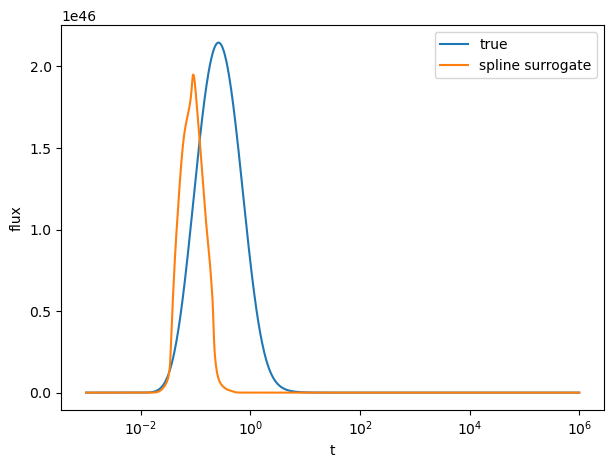

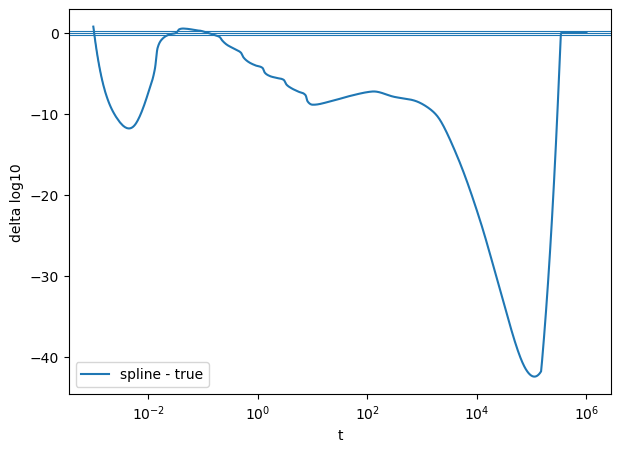

In [4]:
from prompt_progenitor import Prompt
import numpy as np
import matplotlib.pyplot as plt

prompt = Prompt(
    components=("jet",),            # just jet for now
    sample_gw_parameters=False,     # we will pass theta_los
    gw_param_mode="mass",           # so _extract_masses expects mass_1/mass_2
    j_struct="tophat",            # or 1/2/3
    eta_jet=1e-4,
    frac=0.1,
    phi_los_deg=0.0,
    default_theta_los_deg=0.0,
)

prompt.check_print()

params = {
    # jet knobs

    # viewing angle
    "theta_los": 10.0,         # degrees

    # binary / EOS inputs used in _derive_Eiso_jet
    "mass_1": 1.8,             # Msun
    "mass_2": 1.4,             # Msun
    "lambda_2": 300.0,         # dimensionless tidal deformability
}

import sys
print("CELL START")
sys.stdout.flush()

out = prompt.update_model(params, dry_run=False)

print("CELL END", out)
sys.stdout.flush()

def interp_logt(t_new, t, y, left=0.0, right=0.0):
    # assumes t increasing
    return np.interp(t_new, t, y, left=left, right=right)

t_grid = np.logspace(-3, 6, 1000).astype(np.float32)

y_interp = interp_logt(t_grid, prompt.t, prompt.total_X, left=0.0, right=0.0)

import matplotlib.pyplot as plt
import numpy as np

t_grid, y_pred_log = predict_physical(
    theta_los=10.0,
    mass_1=1.8,
    mass_2=1.4,
    lambda_2=300.0,
)
y_pred_log = y_pred_log[0]
y_true_log = np.log10(y_interp+1e-40)

# if you have y_true_log
plt.figure(figsize=(7,5))
plt.plot(t_grid, 10**y_true_log, label="true")
plt.plot(t_grid, 10**y_pred_log, label="spline surrogate")
plt.xscale("log")
plt.xlabel("t")
plt.ylabel("flux")
plt.legend()
plt.show()

plt.figure(figsize=(7,5))
diag = y_pred_log - y_true_log
plt.plot(t_grid, diag, label="spline - true")
plt.xscale("log")
plt.axhline(0.0, lw=0.8)
plt.axhline(0.25, lw=0.8)
plt.axhline(-0.25, lw=0.8)
plt.xlabel("t")
plt.ylabel("delta log10")
plt.legend()
plt.show()

In [15]:
# train_lightcurve_autoencoder.py
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# Config
# -----------------------------
DATA_PATH = "prompt_bns_dataset_32k.npz"
MODEL_OUT = "lightcurve_autoencoder.pt"

BATCH_SIZE = 256
EPOCHS = 300
LR = 2e-4
WEIGHT_DECAY = 1e-5
VAL_FRAC = 0.1
TEST_FRAC = 0.1

LATENT_DIM = 16
HIDDEN1 = 512
HIDDEN2 = 256
DROPOUT = 0.05

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

torch.set_default_dtype(torch.float64)

# -----------------------------
# Reproducibility
# -----------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# -----------------------------
# Helpers
# -----------------------------
def make_splits(N, val_frac=0.1, test_frac=0.1, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(N)
    rng.shuffle(idx)

    n_test = int(test_frac * N)
    n_val = int(val_frac * N)
    n_train = N - n_val - n_test

    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train + n_val]
    test_idx = idx[n_train + n_val:]
    return train_idx, val_idx, test_idx

# -----------------------------
# Dataset
# -----------------------------
class CurveDataset(Dataset):
    def __init__(self, Yn):
        self.Yn = torch.from_numpy(Yn).to(torch.float64)

    def __len__(self):
        return self.Yn.shape[0]

    def __getitem__(self, idx):
        return self.Yn[idx]

# -----------------------------
# Model
# -----------------------------
class CurveAutoencoder(nn.Module):
    def __init__(self, in_dim=1000, latent_dim=16, hidden1=512, hidden2=256, dropout=0.05):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(in_dim, hidden1),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, hidden1),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, in_dim),
        )

    def encode(self, y):
        return self.encoder(y)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, y):
        z = self.encode(y)
        yhat = self.decode(z)
        return z, yhat

# -----------------------------
# Loss / metrics
# -----------------------------
def smoothness_penalty(y):
    if y.shape[1] < 3:
        return torch.zeros((), dtype=y.dtype, device=y.device)
    d2 = y[:, 2:] - 2.0 * y[:, 1:-1] + y[:, :-2]
    return (d2 ** 2).mean()

def ae_reconstruction_loss(
    pred_n,
    target_n,
    target_raw,
    floor_log=-40.0,
    margin=0.5,
    beta=0.5,
    bright_weight=3.0,
    smooth_weight=1e-3,
    y_mean_t=None,
    y_std_t=None,
):
    diff = pred_n - target_n
    abs_diff = torch.abs(diff)
    huber = torch.where(
        abs_diff < beta,
        0.5 * diff * diff / beta,
        abs_diff - 0.5 * beta,
    )

    mask = target_raw > (floor_log + margin)

    if mask.sum() > 0:
        bright = torch.clamp(target_raw - (floor_log + margin), min=0.0)
        weights = 1.0 + bright_weight * bright / bright.mean().clamp_min(1e-12)
        recon_loss = (huber[mask] * weights[mask]).mean()
    else:
        recon_loss = huber.mean()

    pred_raw = pred_n * y_std_t + y_mean_t
    smooth_loss = smoothness_penalty(pred_raw)

    return recon_loss + smooth_weight * smooth_loss

def evaluate(model, loader, y_mean_t, y_std_t, floor_log):
    model.eval()
    total_loss = 0.0
    total_mae_log = 0.0
    total_peak_mae_log = 0.0
    n = 0

    with torch.no_grad():
        for yb_n in loader:
            yb_n = yb_n.to(DEVICE)
            _, pred_n = model(yb_n)

            yb_raw = yb_n * y_std_t + y_mean_t
            loss = ae_reconstruction_loss(
                pred_n, yb_n, yb_raw,
                floor_log=floor_log,
                y_mean_t=y_mean_t,
                y_std_t=y_std_t,
            )

            pred_raw = pred_n * y_std_t + y_mean_t
            mask = yb_raw > (floor_log + 0.5)

            if mask.sum() > 0:
                mae_log = torch.abs(pred_raw - yb_raw)[mask].mean()
            else:
                mae_log = torch.abs(pred_raw - yb_raw).mean()

            pred_peak = pred_raw.max(dim=1).values
            true_peak = yb_raw.max(dim=1).values
            peak_mae_log = torch.abs(pred_peak - true_peak).mean()

            bs = yb_n.size(0)
            total_loss += loss.item() * bs
            total_mae_log += mae_log.item() * bs
            total_peak_mae_log += peak_mae_log.item() * bs
            n += bs

    return total_loss / n, total_mae_log / n, total_peak_mae_log / n

# -----------------------------
# Train
# -----------------------------
def train():
    d = np.load(DATA_PATH)
    Y = d["Y"].astype(np.float64)
    t_grid = d["t_grid"].astype(np.float64)
    y_floor = float(d["y_floor"]) if "y_floor" in d else 1e-40
    floor_log = np.log10(y_floor)

    N = Y.shape[0]
    T = Y.shape[1]

    train_idx, val_idx, test_idx = make_splits(N, VAL_FRAC, TEST_FRAC, SEED)

    Y_train_raw = Y[train_idx]

    y_mean = Y_train_raw.mean(axis=0, keepdims=True)
    y_std = Y_train_raw.std(axis=0, keepdims=True)
    y_std = np.maximum(y_std, 1e-12)

    Y_train = (Y[train_idx] - y_mean) / y_std
    Y_val   = (Y[val_idx]   - y_mean) / y_std
    Y_test  = (Y[test_idx]  - y_mean) / y_std

    train_ds = CurveDataset(Y_train)
    val_ds = CurveDataset(Y_val)
    test_ds = CurveDataset(Y_test)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = CurveAutoencoder(
        in_dim=T,
        latent_dim=LATENT_DIM,
        hidden1=HIDDEN1,
        hidden2=HIDDEN2,
        dropout=DROPOUT,
    ).to(DEVICE).double()

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=12
    )

    y_mean_t = torch.tensor(y_mean, dtype=torch.float64, device=DEVICE)
    y_std_t = torch.tensor(y_std, dtype=torch.float64, device=DEVICE)

    best_val = float("inf")
    patience = 30
    bad_epochs = 0

    print(f"Device: {DEVICE}")
    print(f"Train/Val/Test = {len(train_ds)}/{len(val_ds)}/{len(test_ds)}")
    print(f"Curve dim = {T}, latent dim = {LATENT_DIM}")

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_train = 0.0
        n = 0

        for yb_n in train_loader:
            yb_n = yb_n.to(DEVICE)

            optimizer.zero_grad()
            _, pred_n = model(yb_n)

            yb_raw = yb_n * y_std_t + y_mean_t
            loss = ae_reconstruction_loss(
                pred_n, yb_n, yb_raw,
                floor_log=floor_log,
                y_mean_t=y_mean_t,
                y_std_t=y_std_t,
            )

            if not torch.isfinite(loss):
                optimizer.zero_grad()
                continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_train += loss.item() * yb_n.size(0)
            n += yb_n.size(0)

        train_loss = total_train / max(n, 1)
        val_loss, val_mae_log, val_peak_mae_log = evaluate(model, val_loader, y_mean_t, y_std_t, floor_log)
        scheduler.step(val_loss)

        lr_now = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch:03d} | "
            f"train {train_loss:.6f} | "
            f"val {val_loss:.6f} | "
            f"val_mae_log {val_mae_log:.6f} | "
            f"val_peak_mae_log {val_peak_mae_log:.6f} | "
            f"lr {lr_now:.2e}"
        )

        if val_loss < best_val:
            best_val = val_loss
            bad_epochs = 0

            ckpt = {
                "model_state": model.state_dict(),
                "y_mean": torch.tensor(y_mean, dtype=torch.float64),
                "y_std": torch.tensor(y_std, dtype=torch.float64),
                "t_grid": torch.tensor(t_grid, dtype=torch.float64),
                "y_floor": y_floor,
                "config": {
                    "latent_dim": LATENT_DIM,
                    "hidden1": HIDDEN1,
                    "hidden2": HIDDEN2,
                    "dropout": DROPOUT,
                    "batch_size": BATCH_SIZE,
                    "lr": LR,
                    "weight_decay": WEIGHT_DECAY,
                },
            }
            torch.save(ckpt, MODEL_OUT)
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            print("Early stopping.")
            break

    print(f"Best val loss: {best_val:.6f}")
    print(f"Saved model to: {MODEL_OUT}")

    ckpt = torch.load(MODEL_OUT, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    test_loss, test_mae_log, test_peak_mae_log = evaluate(model, test_loader, y_mean_t, y_std_t, floor_log)
    print(f"Test loss: {test_loss:.6f}")
    print(f"Test MAE(log10): {test_mae_log:.6f}")
    print(f"Test peak MAE(log10): {test_peak_mae_log:.6f}")

if __name__ == "__main__":
    train()

Device: cpu
Train/Val/Test = 25600/3200/3200
Curve dim = 1000, latent dim = 16
Epoch 001 | train 0.550191 | val 0.079045 | val_mae_log 2.047837 | val_peak_mae_log 1.666226 | lr 2.00e-04
Epoch 002 | train 0.093607 | val 0.040633 | val_mae_log 1.280981 | val_peak_mae_log 1.027268 | lr 2.00e-04
Epoch 003 | train 0.062529 | val 0.026400 | val_mae_log 0.972772 | val_peak_mae_log 0.781091 | lr 2.00e-04
Epoch 004 | train 0.045661 | val 0.017119 | val_mae_log 0.742097 | val_peak_mae_log 0.571676 | lr 2.00e-04
Epoch 005 | train 0.034838 | val 0.011497 | val_mae_log 0.576949 | val_peak_mae_log 0.564319 | lr 2.00e-04
Epoch 006 | train 0.028201 | val 0.008903 | val_mae_log 0.494524 | val_peak_mae_log 0.531735 | lr 2.00e-04
Epoch 007 | train 0.024459 | val 0.009229 | val_mae_log 0.449977 | val_peak_mae_log 0.384046 | lr 2.00e-04
Epoch 008 | train 0.021248 | val 0.005707 | val_mae_log 0.379709 | val_peak_mae_log 0.446735 | lr 2.00e-04
Epoch 009 | train 0.018858 | val 0.005973 | val_mae_log 0.369455 

AE ceiling MAE(log10):      2.788310
AE ceiling RMSE(log10):     14.118072
AE ceiling Peak err(log10): 0.322987
AE ceiling Peak factor:      2.103716


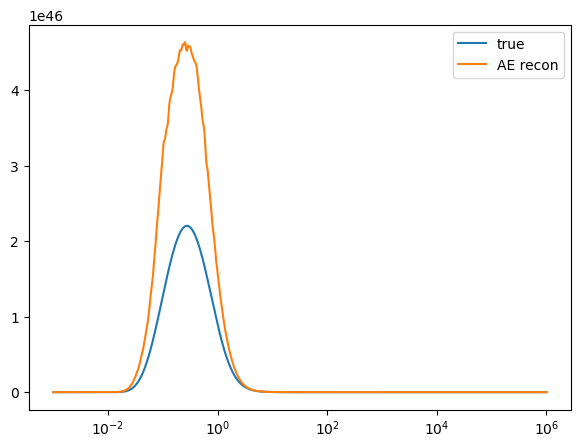

In [17]:
# diagnose_lightcurve_autoencoder.py
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_PATH = "lightcurve_autoencoder.pt"

torch.set_default_dtype(torch.float64)

class CurveAutoencoder(nn.Module):
    def __init__(self, in_dim=1000, latent_dim=16, hidden1=512, hidden2=256, dropout=0.05):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, hidden1),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, hidden1),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, in_dim),
        )

    def encode(self, y):
        return self.encoder(y)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, y):
        z = self.encode(y)
        yhat = self.decode(z)
        return z, yhat

def load_model(model_path=MODEL_PATH):
    ckpt = torch.load(model_path, map_location=DEVICE, weights_only=False)
    cfg = ckpt["config"]

    y_mean = ckpt["y_mean"].to(DEVICE, dtype=torch.float64)
    y_std = ckpt["y_std"].to(DEVICE, dtype=torch.float64)
    t_grid = ckpt["t_grid"].detach().cpu().numpy()

    model = CurveAutoencoder(
        in_dim=y_mean.shape[1],
        latent_dim=cfg["latent_dim"],
        hidden1=cfg["hidden1"],
        hidden2=cfg["hidden2"],
        dropout=cfg["dropout"],
    ).to(DEVICE).double()

    model.load_state_dict(ckpt["model_state"])
    model.eval()
    return model, y_mean, y_std, t_grid

def reconstruct_true_curve(y_true_log):
    model, y_mean, y_std, t_grid = load_model()

    y = np.asarray(y_true_log, dtype=np.float64)
    if y.ndim == 1:
        y = y[None, :]

    y_t = torch.tensor(y, dtype=torch.float64, device=DEVICE)
    y_n = (y_t - y_mean) / y_std

    with torch.no_grad():
        _, yhat_n = model(y_n)
        yhat = yhat_n * y_std + y_mean

    return t_grid, yhat.detach().cpu().numpy()

def summarize_curve_error(y_pred_log, y_true_log, name=""):
    delta = np.asarray(y_pred_log) - np.asarray(y_true_log)
    mae_log = np.mean(np.abs(delta))
    rmse_log = np.sqrt(np.mean(delta**2))
    peak_err_log = np.max(y_pred_log) - np.max(y_true_log)

    print(f"{name} MAE(log10):      {mae_log:.6f}")
    print(f"{name} RMSE(log10):     {rmse_log:.6f}")
    print(f"{name} Peak err(log10): {peak_err_log:.6f}")
    print(f"{name} Peak factor:      {10**abs(peak_err_log):.6f}")

t_grid, y_ae_recon = reconstruct_true_curve(np.log10(y_interp+1e-40))
y_ae_recon = y_ae_recon[0]

summarize_curve_error(y_ae_recon, np.log10(y_interp+1e-40), name="AE ceiling")

plt.figure(figsize=(7,5))
plt.plot(t_grid, 10**np.log10(y_interp+1e-40), label="true")
plt.plot(t_grid, 10**y_ae_recon, label="AE recon")
plt.xscale("log")
plt.legend()
plt.show()

In [18]:
import numpy as np
import torch
import torch.nn as nn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_PATH = "lightcurve_autoencoder.pt"
DATA_PATH = "prompt_bns_dataset_32k.npz"

torch.set_default_dtype(torch.float64)

class CurveAutoencoder(nn.Module):
    def __init__(self, in_dim=1000, latent_dim=16, hidden1=512, hidden2=256, dropout=0.05):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, hidden1),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, hidden1),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, in_dim),
        )

    def forward(self, y):
        z = self.encoder(y)
        yhat = self.decoder(z)
        return z, yhat

def load_ae():
    ckpt = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
    cfg = ckpt["config"]

    model = CurveAutoencoder(
        in_dim=ckpt["y_mean"].shape[1],
        latent_dim=cfg["latent_dim"],
        hidden1=cfg["hidden1"],
        hidden2=cfg["hidden2"],
        dropout=cfg["dropout"],
    ).to(DEVICE).double()
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    y_mean = ckpt["y_mean"].to(DEVICE, dtype=torch.float64)
    y_std = ckpt["y_std"].to(DEVICE, dtype=torch.float64)
    t_grid = ckpt["t_grid"].detach().cpu().numpy()
    return model, y_mean, y_std, t_grid

def summarize_curve_error(y_pred_log, y_true_log, name=""):
    delta = np.asarray(y_pred_log) - np.asarray(y_true_log)
    mae_log = np.mean(np.abs(delta))
    rmse_log = np.sqrt(np.mean(delta**2))
    peak_err_log = np.max(y_pred_log) - np.max(y_true_log)

    print(f"{name} MAE(log10):      {mae_log:.6f}")
    print(f"{name} RMSE(log10):     {rmse_log:.6f}")
    print(f"{name} Peak err(log10): {peak_err_log:.6f}")
    print(f"{name} Peak factor:      {10**abs(peak_err_log):.6f}")

# load exact dataset curve
d = np.load(DATA_PATH)
Y = d["Y"].astype(np.float64)
t_grid_data = d["t_grid"].astype(np.float64)

# pick any sample
i = 0
y_true_log = Y[i:i+1]   # shape (1,1000)

model, y_mean, y_std, t_grid_ckpt = load_ae()

print("t_grid equal:", np.allclose(t_grid_data, t_grid_ckpt))

y_true_t = torch.tensor(y_true_log, dtype=torch.float64, device=DEVICE)
y_true_n = (y_true_t - y_mean) / y_std

with torch.no_grad():
    _, y_pred_n = model(y_true_n)
    y_pred_log = (y_pred_n * y_std + y_mean).detach().cpu().numpy()

summarize_curve_error(y_pred_log[0], y_true_log[0], name="AE on dataset sample")

t_grid equal: True
AE on dataset sample MAE(log10):      0.034588
AE on dataset sample RMSE(log10):     0.054889
AE on dataset sample Peak err(log10): 0.040227
AE on dataset sample Peak factor:      1.097052


In [19]:
# train_param_to_latent.py
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# Config
# -----------------------------
DATA_PATH = "prompt_bns_dataset_32k.npz"
AE_MODEL_PATH = "lightcurve_autoencoder.pt"
MODEL_OUT = "param_to_latent.pt"

BATCH_SIZE = 256
EPOCHS = 250
LR = 2e-4
WEIGHT_DECAY = 1e-5
VAL_FRAC = 0.1
TEST_FRAC = 0.1

HIDDEN = 256
DEPTH = 4
DROPOUT = 0.05

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

torch.set_default_dtype(torch.float64)

# -----------------------------
# Reproducibility
# -----------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# -----------------------------
# Helpers
# -----------------------------
def make_splits(N, val_frac=0.1, test_frac=0.1, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(N)
    rng.shuffle(idx)

    n_test = int(test_frac * N)
    n_val = int(val_frac * N)
    n_train = N - n_val - n_test

    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train + n_val]
    test_idx = idx[n_train + n_val:]
    return train_idx, val_idx, test_idx

def normalize_X_minmax(X, x_min, x_scale):
    return (X - x_min) / x_scale

# -----------------------------
# AE model
# -----------------------------
class CurveAutoencoder(nn.Module):
    def __init__(self, in_dim=1000, latent_dim=16, hidden1=512, hidden2=256, dropout=0.05):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, hidden1),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, hidden1),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, in_dim),
        )

    def encode(self, y):
        return self.encoder(y)

    def decode(self, z):
        return self.decoder(z)

# -----------------------------
# Param -> latent model
# -----------------------------
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.net(x))

class ParamToLatentMLP(nn.Module):
    def __init__(self, in_dim=4, out_dim=16, hidden=256, depth=4, dropout=0.05):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.GELU()]
        for _ in range(depth):
            layers.append(ResidualBlock(hidden, dropout=dropout))
        layers += [nn.Dropout(dropout), nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# -----------------------------
# Dataset
# -----------------------------
class LatentDataset(Dataset):
    def __init__(self, Xn, Zn, Yn):
        self.Xn = torch.from_numpy(Xn).to(torch.float64)
        self.Zn = torch.from_numpy(Zn).to(torch.float64)
        self.Yn = torch.from_numpy(Yn).to(torch.float64)

    def __len__(self):
        return self.Xn.shape[0]

    def __getitem__(self, idx):
        return self.Xn[idx], self.Zn[idx], self.Yn[idx]

# -----------------------------
# Loss / metrics
# -----------------------------
def smoothness_penalty(y):
    if y.shape[1] < 3:
        return torch.zeros((), dtype=y.dtype, device=y.device)
    d2 = y[:, 2:] - 2.0 * y[:, 1:-1] + y[:, :-2]
    return (d2 ** 2).mean()

def reconstruction_loss_from_latent(
    pred_z,
    true_y_n,
    decoder,
    y_mean_t,
    y_std_t,
    floor_log=-40.0,
    margin=0.5,
    beta=0.5,
    bright_weight=3.0,
    smooth_weight=1e-3,
):
    pred_y_n = decoder(pred_z)
    true_y_raw = true_y_n * y_std_t + y_mean_t

    diff = pred_y_n - true_y_n
    abs_diff = torch.abs(diff)
    huber = torch.where(
        abs_diff < beta,
        0.5 * diff * diff / beta,
        abs_diff - 0.5 * beta,
    )

    mask = true_y_raw > (floor_log + margin)

    if mask.sum() > 0:
        bright = torch.clamp(true_y_raw - (floor_log + margin), min=0.0)
        weights = 1.0 + bright_weight * bright / bright.mean().clamp_min(1e-12)
        recon_loss = (huber[mask] * weights[mask]).mean()
    else:
        recon_loss = huber.mean()

    pred_y_raw = pred_y_n * y_std_t + y_mean_t
    smooth_loss = smoothness_penalty(pred_y_raw)

    return recon_loss + smooth_weight * smooth_loss

def evaluate(model, loader, decoder, y_mean_t, y_std_t, floor_log):
    model.eval()
    total_loss = 0.0
    total_mae_log = 0.0
    total_peak_mae_log = 0.0
    n = 0

    with torch.no_grad():
        for xb, zb, yb_n in loader:
            xb = xb.to(DEVICE)
            yb_n = yb_n.to(DEVICE)

            pred_z = model(xb)
            loss = reconstruction_loss_from_latent(
                pred_z, yb_n, decoder,
                y_mean_t, y_std_t,
                floor_log=floor_log,
            )

            pred_y_n = decoder(pred_z)
            pred_y_raw = pred_y_n * y_std_t + y_mean_t
            true_y_raw = yb_n * y_std_t + y_mean_t

            mask = true_y_raw > (floor_log + 0.5)
            if mask.sum() > 0:
                mae_log = torch.abs(pred_y_raw - true_y_raw)[mask].mean()
            else:
                mae_log = torch.abs(pred_y_raw - true_y_raw).mean()

            pred_peak = pred_y_raw.max(dim=1).values
            true_peak = true_y_raw.max(dim=1).values
            peak_mae_log = torch.abs(pred_peak - true_peak).mean()

            bs = xb.size(0)
            total_loss += loss.item() * bs
            total_mae_log += mae_log.item() * bs
            total_peak_mae_log += peak_mae_log.item() * bs
            n += bs

    return total_loss / n, total_mae_log / n, total_peak_mae_log / n

# -----------------------------
# Train
# -----------------------------
def train():
    d = np.load(DATA_PATH)
    X = d["X"].astype(np.float64)
    Y = d["Y"].astype(np.float64)
    t_grid = d["t_grid"].astype(np.float64)
    y_floor = float(d["y_floor"]) if "y_floor" in d else 1e-40
    floor_log = np.log10(y_floor)

    train_idx, val_idx, test_idx = make_splits(X.shape[0], VAL_FRAC, TEST_FRAC, SEED)

    ae_ckpt = torch.load(AE_MODEL_PATH, map_location=DEVICE, weights_only=False)
    cfg = ae_ckpt["config"]

    y_mean = ae_ckpt["y_mean"].detach().cpu().numpy()
    y_std = ae_ckpt["y_std"].detach().cpu().numpy()

    ae = CurveAutoencoder(
        in_dim=y_mean.shape[1],
        latent_dim=cfg["latent_dim"],
        hidden1=cfg["hidden1"],
        hidden2=cfg["hidden2"],
        dropout=cfg["dropout"],
    ).to(DEVICE).double()
    ae.load_state_dict(ae_ckpt["model_state"])
    ae.eval()

    for p in ae.parameters():
        p.requires_grad = False

    # X normalization from train only
    X_train_raw = X[train_idx]
    x_min = X_train_raw.min(axis=0, keepdims=True)
    x_max = X_train_raw.max(axis=0, keepdims=True)
    x_scale = np.maximum(x_max - x_min, 1e-12)

    X_train = normalize_X_minmax(X[train_idx], x_min, x_scale)
    X_val   = normalize_X_minmax(X[val_idx],   x_min, x_scale)
    X_test  = normalize_X_minmax(X[test_idx],  x_min, x_scale)

    Y_train_n = (Y[train_idx] - y_mean) / y_std
    Y_val_n   = (Y[val_idx]   - y_mean) / y_std
    Y_test_n  = (Y[test_idx]  - y_mean) / y_std

    def encode_batch(Yn):
        out = []
        bs = 256
        with torch.no_grad():
            for i in range(0, len(Yn), bs):
                yb = torch.tensor(Yn[i:i+bs], dtype=torch.float64, device=DEVICE)
                zb = ae.encode(yb).detach().cpu().numpy()
                out.append(zb)
        return np.concatenate(out, axis=0)

    Z_train = encode_batch(Y_train_n)
    Z_val   = encode_batch(Y_val_n)
    Z_test  = encode_batch(Y_test_n)

    z_mean = Z_train.mean(axis=0, keepdims=True)
    z_std = Z_train.std(axis=0, keepdims=True)
    z_std = np.maximum(z_std, 1e-12)

    Z_train_n = (Z_train - z_mean) / z_std
    Z_val_n   = (Z_val   - z_mean) / z_std
    Z_test_n  = (Z_test  - z_mean) / z_std

    train_ds = LatentDataset(X_train, Z_train_n, Y_train_n)
    val_ds   = LatentDataset(X_val, Z_val_n, Y_val_n)
    test_ds  = LatentDataset(X_test, Z_test_n, Y_test_n)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = ParamToLatentMLP(
        in_dim=4,
        out_dim=Z_train.shape[1],
        hidden=HIDDEN,
        depth=DEPTH,
        dropout=DROPOUT,
    ).to(DEVICE).double()

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=12
    )

    z_mean_t = torch.tensor(z_mean, dtype=torch.float64, device=DEVICE)
    z_std_t = torch.tensor(z_std, dtype=torch.float64, device=DEVICE)
    y_mean_t = ae_ckpt["y_mean"].to(DEVICE, dtype=torch.float64)
    y_std_t = ae_ckpt["y_std"].to(DEVICE, dtype=torch.float64)

    decoder = ae.decode

    best_val = float("inf")
    patience = 30
    bad_epochs = 0

    print(f"Device: {DEVICE}")
    print(f"Train/Val/Test = {len(train_ds)}/{len(val_ds)}/{len(test_ds)}")
    print(f"Latent dim = {Z_train.shape[1]}")

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_train = 0.0
        n = 0

        for xb, zb_n, yb_n in train_loader:
            xb = xb.to(DEVICE)
            zb_n = zb_n.to(DEVICE)
            yb_n = yb_n.to(DEVICE)

            optimizer.zero_grad()

            pred_z_n = model(xb)
            pred_z = pred_z_n * z_std_t + z_mean_t

            loss = reconstruction_loss_from_latent(
                pred_z, yb_n, decoder,
                y_mean_t, y_std_t,
                floor_log=floor_log,
            )

            if not torch.isfinite(loss):
                optimizer.zero_grad()
                continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_train += loss.item() * xb.size(0)
            n += xb.size(0)

        train_loss = total_train / max(n, 1)
        val_loss, val_mae_log, val_peak_mae_log = evaluate(
            model, val_loader, decoder, y_mean_t, y_std_t, floor_log
        )
        scheduler.step(val_loss)

        lr_now = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch:03d} | "
            f"train {train_loss:.6f} | "
            f"val {val_loss:.6f} | "
            f"val_mae_log {val_mae_log:.6f} | "
            f"val_peak_mae_log {val_peak_mae_log:.6f} | "
            f"lr {lr_now:.2e}"
        )

        if val_loss < best_val:
            best_val = val_loss
            bad_epochs = 0

            ckpt = {
                "model_state": model.state_dict(),
                "ae_model_path": AE_MODEL_PATH,
                "x_min": torch.tensor(x_min, dtype=torch.float64),
                "x_scale": torch.tensor(x_scale, dtype=torch.float64),
                "z_mean": torch.tensor(z_mean, dtype=torch.float64),
                "z_std": torch.tensor(z_std, dtype=torch.float64),
                "t_grid": torch.tensor(t_grid, dtype=torch.float64),
                "y_floor": y_floor,
                "config": {
                    "hidden": HIDDEN,
                    "depth": DEPTH,
                    "dropout": DROPOUT,
                    "latent_dim": Z_train.shape[1],
                    "batch_size": BATCH_SIZE,
                    "lr": LR,
                    "weight_decay": WEIGHT_DECAY,
                },
            }
            torch.save(ckpt, MODEL_OUT)
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            print("Early stopping.")
            break

    print(f"Best val loss: {best_val:.6f}")
    print(f"Saved model to: {MODEL_OUT}")

if __name__ == "__main__":
    train()

Device: cpu
Train/Val/Test = 25600/3200/3200
Latent dim = 16
Epoch 001 | train 0.940544 | val 0.541512 | val_mae_log 3.222928 | val_peak_mae_log 1.137420 | lr 2.00e-04
Epoch 002 | train 0.228667 | val 0.293554 | val_mae_log 2.775956 | val_peak_mae_log 1.441738 | lr 2.00e-04
Epoch 003 | train 0.095911 | val 0.280633 | val_mae_log 2.663132 | val_peak_mae_log 1.350786 | lr 2.00e-04
Epoch 004 | train 0.069041 | val 0.248273 | val_mae_log 2.566713 | val_peak_mae_log 1.310332 | lr 2.00e-04
Epoch 005 | train 0.056107 | val 0.244039 | val_mae_log 2.559203 | val_peak_mae_log 1.393959 | lr 2.00e-04
Epoch 006 | train 0.045824 | val 0.226724 | val_mae_log 2.432731 | val_peak_mae_log 1.231127 | lr 2.00e-04
Epoch 007 | train 0.041522 | val 0.210648 | val_mae_log 2.362921 | val_peak_mae_log 1.221580 | lr 2.00e-04
Epoch 008 | train 0.037657 | val 0.208775 | val_mae_log 2.392831 | val_peak_mae_log 1.130324 | lr 2.00e-04
Epoch 009 | train 0.033197 | val 0.206111 | val_mae_log 2.403664 | val_peak_mae_log

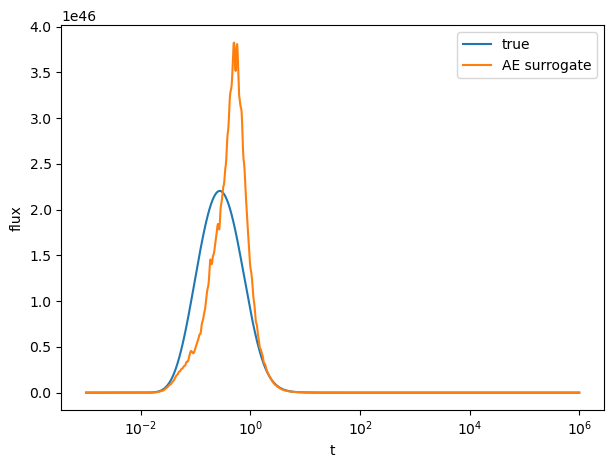

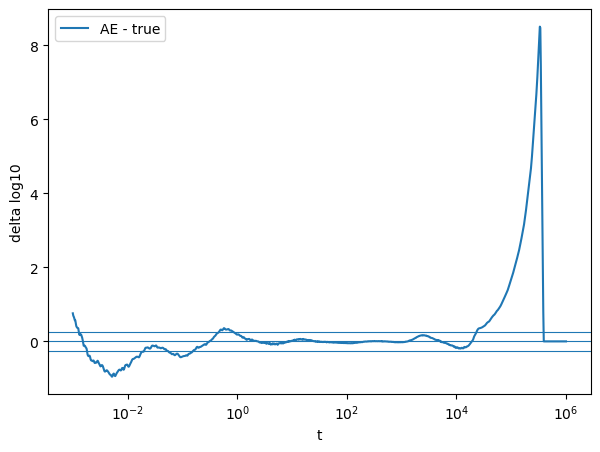

In [20]:
# predict_lightcurve_autoencoder_surrogate.py
import numpy as np
import torch
import torch.nn as nn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
AE_MODEL_PATH = "lightcurve_autoencoder.pt"
SURR_MODEL_PATH = "param_to_latent.pt"

torch.set_default_dtype(torch.float64)

class CurveAutoencoder(nn.Module):
    def __init__(self, in_dim=1000, latent_dim=16, hidden1=512, hidden2=256, dropout=0.05):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, hidden1),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, hidden1),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, in_dim),
        )

    def decode(self, z):
        return self.decoder(z)

class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.net(x))

class ParamToLatentMLP(nn.Module):
    def __init__(self, in_dim=4, out_dim=16, hidden=256, depth=4, dropout=0.05):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.GELU()]
        for _ in range(depth):
            layers.append(ResidualBlock(hidden, dropout=dropout))
        layers += [nn.Dropout(dropout), nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def load_models():
    ae_ckpt = torch.load(AE_MODEL_PATH, map_location=DEVICE, weights_only=False)
    ae_cfg = ae_ckpt["config"]

    ae = CurveAutoencoder(
        in_dim=ae_ckpt["y_mean"].shape[1],
        latent_dim=ae_cfg["latent_dim"],
        hidden1=ae_cfg["hidden1"],
        hidden2=ae_cfg["hidden2"],
        dropout=ae_cfg["dropout"],
    ).to(DEVICE).double()
    ae.load_state_dict(ae_ckpt["model_state"])
    ae.eval()

    s_ckpt = torch.load(SURR_MODEL_PATH, map_location=DEVICE, weights_only=False)
    s_cfg = s_ckpt["config"]

    surr = ParamToLatentMLP(
        in_dim=4,
        out_dim=s_cfg["latent_dim"],
        hidden=s_cfg["hidden"],
        depth=s_cfg["depth"],
        dropout=s_cfg["dropout"],
    ).to(DEVICE).double()
    surr.load_state_dict(s_ckpt["model_state"])
    surr.eval()

    return ae, ae_ckpt, surr, s_ckpt

def predict_from_features(x_feat):
    ae, ae_ckpt, surr, s_ckpt = load_models()

    x = torch.tensor(x_feat, dtype=torch.float64, device=DEVICE).unsqueeze(0)

    x_min = s_ckpt["x_min"].to(DEVICE, dtype=torch.float64)
    x_scale = s_ckpt["x_scale"].to(DEVICE, dtype=torch.float64)
    z_mean = s_ckpt["z_mean"].to(DEVICE, dtype=torch.float64)
    z_std = s_ckpt["z_std"].to(DEVICE, dtype=torch.float64)
    y_mean = ae_ckpt["y_mean"].to(DEVICE, dtype=torch.float64)
    y_std = ae_ckpt["y_std"].to(DEVICE, dtype=torch.float64)
    t_grid = ae_ckpt["t_grid"].detach().cpu().numpy()

    xn = (x - x_min) / x_scale
    xn = torch.clamp(xn, 0.0, 1.0)

    with torch.no_grad():
        z_n = surr(xn)
        z = z_n * z_std + z_mean
        y_n = ae.decode(z)
        y = y_n * y_std + y_mean

        floor_log = np.log10(float(ae_ckpt["y_floor"]))
        y = torch.clamp(y, min=floor_log)

    return t_grid, y.detach().cpu().numpy()

def featurize_physical(theta_los, mass_1, mass_2, lambda_2):
    m1, m2 = mass_1, mass_2
    if m2 > m1:
        m1, m2 = m2, m1
    return np.array(
        [theta_los / 60.0, m1, m2, np.log10(lambda_2 + 1.0)],
        dtype=np.float64,
    )

def predict_physical(theta_los, mass_1, mass_2, lambda_2):
    x_feat = featurize_physical(theta_los, mass_1, mass_2, lambda_2)
    return predict_from_features(x_feat)

t_grid, y_pred_log = predict_physical(
    theta_los=20.0,
    mass_1=1.8,
    mass_2=1.4,
    lambda_2=300.0,
)
y_pred_log = y_pred_log[0]

# linear plot
plt.figure(figsize=(7,5))
plt.plot(t_grid, 10**np.log10(y_interp+1e-40), label="true")
plt.plot(t_grid, 10**y_pred_log, label="AE surrogate")
plt.xscale("log")
plt.xlabel("t")
plt.ylabel("flux")
plt.legend()
plt.show()

# diagnostic
diag = y_pred_log - np.log10(y_interp+1e-40)
plt.figure(figsize=(7,5))
plt.plot(t_grid, diag, label="AE - true")
plt.xscale("log")
plt.axhline(0.0, lw=0.8)
plt.axhline(0.25, lw=0.8)
plt.axhline(-0.25, lw=0.8)
plt.xlabel("t")
plt.ylabel("delta log10")
plt.legend()
plt.show()

In [2]:
# train_lightcurve_conditional_time.py
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# Config
# -----------------------------
DATA_PATH = "prompt_bns_dataset_32k.npz"
MODEL_OUT = "lightcurve_conditional_time.pt"

BATCH_SIZE = 4096
EPOCHS = 80
LR = 2e-4
WEIGHT_DECAY = 1e-5
VAL_FRAC = 0.1
TEST_FRAC = 0.1

HIDDEN = 256
DEPTH = 4
DROPOUT = 0.05

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# subsample time points per curve per epoch for speed
TIME_SAMPLES_PER_CURVE_TRAIN = 128
TIME_SAMPLES_PER_CURVE_EVAL = 1000  # full grid for eval

torch.set_default_dtype(torch.float64)

# -----------------------------
# Reproducibility
# -----------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# -----------------------------
# Helpers
# -----------------------------
def make_splits(N, val_frac=0.1, test_frac=0.1, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(N)
    rng.shuffle(idx)

    n_test = int(test_frac * N)
    n_val = int(val_frac * N)
    n_train = N - n_val - n_test

    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train + n_val]
    test_idx = idx[n_train + n_val:]
    return train_idx, val_idx, test_idx

def normalize_X_minmax(X, x_min, x_scale):
    return (X - x_min) / x_scale

def normalize_scalar_zscore(x, mean, std):
    return (x - mean) / std

def denormalize_scalar_zscore(xn, mean, std):
    return xn * std + mean

# -----------------------------
# Dataset
# -----------------------------
class ConditionalTimeDataset(Dataset):
    """
    Stores whole curves. Each __getitem__ samples random times from that curve.
    """
    def __init__(
        self,
        Xn,
        Y,
        logt_grid,
        n_time_samples,
        y_mean,
        y_std,
        train=True,
    ):
        self.Xn = Xn.astype(np.float64)          # (N,4)
        self.Y = Y.astype(np.float64)            # (N,T) in log10 space
        self.logt_grid = logt_grid.astype(np.float64)  # (T,)
        self.n_time_samples = n_time_samples
        self.y_mean = float(y_mean)
        self.y_std = float(y_std)
        self.train = train
        self.T = self.Y.shape[1]

    def __len__(self):
        return self.Xn.shape[0]

    def __getitem__(self, idx):
        x = self.Xn[idx]      # (4,)
        y = self.Y[idx]       # (T,)

        if self.train:
            t_idx = np.random.choice(self.T, size=self.n_time_samples, replace=False)
        else:
            t_idx = np.arange(self.T)

        logt = self.logt_grid[t_idx]                     # (K,)
        y_sel = y[t_idx]                                 # (K,)
        y_sel_n = (y_sel - self.y_mean) / self.y_std     # scalar z-score

        # repeat x across sampled times
        x_rep = np.repeat(x[None, :], len(t_idx), axis=0)  # (K,4)
        inp = np.concatenate([x_rep, logt[:, None]], axis=1)  # (K,5)

        return (
            torch.from_numpy(inp).to(torch.float64),       # (K,5)
            torch.from_numpy(y_sel_n).to(torch.float64),   # (K,)
            torch.from_numpy(y_sel).to(torch.float64),     # (K,)
        )

def conditional_collate(batch):
    """
    Flattens per-curve sampled points into a single batch of points.
    """
    X_list, Yn_list, Yraw_list = zip(*batch)
    X = torch.cat(X_list, dim=0)       # (B*K,5)
    Yn = torch.cat(Yn_list, dim=0)     # (B*K,)
    Yraw = torch.cat(Yraw_list, dim=0) # (B*K,)
    return X, Yn, Yraw

# -----------------------------
# Model
# -----------------------------
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.net(x))

class ConditionalTimeMLP(nn.Module):
    def __init__(self, in_dim=5, hidden=256, depth=4, dropout=0.05):
        super().__init__()
        layers = [
            nn.Linear(in_dim, hidden),
            nn.GELU(),
        ]
        for _ in range(depth):
            layers.append(ResidualBlock(hidden, dropout=dropout))
        layers += [
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        ]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)   # (N,)

# -----------------------------
# Loss / metrics
# -----------------------------
def smooth_l1_masked_weighted(
    pred_n,
    target_n,
    target_raw,
    floor_log=-40.0,
    margin=0.5,
    beta=0.5,
    bright_weight=3.0,
):
    mask = target_raw > (floor_log + margin)

    diff = pred_n - target_n
    abs_diff = torch.abs(diff)
    huber = torch.where(
        abs_diff < beta,
        0.5 * diff * diff / beta,
        abs_diff - 0.5 * beta,
    )

    if mask.sum() == 0:
        return huber.mean()

    bright = torch.clamp(target_raw - (floor_log + margin), min=0.0)
    weights = 1.0 + bright_weight * bright / bright.mean().clamp_min(1e-12)
    return (huber[mask] * weights[mask]).mean()

def evaluate(model, loader, y_mean, y_std, floor_log):
    model.eval()
    total_loss = 0.0
    total_mae_log = 0.0
    n = 0

    with torch.no_grad():
        for xb, yb_n, yb_raw in loader:
            xb = xb.to(DEVICE)
            yb_n = yb_n.to(DEVICE)
            yb_raw = yb_raw.to(DEVICE)

            pred_n = model(xb)
            loss = smooth_l1_masked_weighted(
                pred_n, yb_n, yb_raw,
                floor_log=floor_log,
                bright_weight=3.0,
            )

            pred_raw = pred_n * y_std + y_mean
            mask = yb_raw > (floor_log + 0.5)
            if mask.sum() > 0:
                mae_log = torch.abs(pred_raw - yb_raw)[mask].mean()
            else:
                mae_log = torch.abs(pred_raw - yb_raw).mean()

            bs = xb.shape[0]
            total_loss += loss.item() * bs
            total_mae_log += mae_log.item() * bs
            n += bs

    return total_loss / n, total_mae_log / n

# -----------------------------
# Train
# -----------------------------
def train():
    d = np.load(DATA_PATH)
    X = d["X"].astype(np.float64)      # already featurized
    Y = d["Y"].astype(np.float64)      # (N,T) in log10 space
    t_grid = d["t_grid"].astype(np.float64)
    y_floor = float(d["y_floor"]) if "y_floor" in d else 1e-40
    floor_log = np.log10(y_floor)

    assert X.ndim == 2 and X.shape[1] == 4
    assert Y.ndim == 2 and X.shape[0] == Y.shape[0]

    logt_grid = np.log10(t_grid)

    N = X.shape[0]
    train_idx, val_idx, test_idx = make_splits(N, VAL_FRAC, TEST_FRAC, SEED)

    X_train_raw = X[train_idx]
    Y_train_raw = Y[train_idx]

    # X normalization from train only
    x_min = X_train_raw.min(axis=0, keepdims=True)
    x_max = X_train_raw.max(axis=0, keepdims=True)
    x_scale = np.maximum(x_max - x_min, 1e-12)

    X_train = normalize_X_minmax(X[train_idx], x_min, x_scale)
    X_val   = normalize_X_minmax(X[val_idx],   x_min, x_scale)
    X_test  = normalize_X_minmax(X[test_idx],  x_min, x_scale)

    # scalar y normalization
    y_mean = Y_train_raw.mean()
    y_std = Y_train_raw.std()
    y_std = max(y_std, 1e-12)

    train_ds = ConditionalTimeDataset(
        X_train, Y[train_idx], logt_grid,
        n_time_samples=TIME_SAMPLES_PER_CURVE_TRAIN,
        y_mean=y_mean, y_std=y_std,
        train=True,
    )
    val_ds = ConditionalTimeDataset(
        X_val, Y[val_idx], logt_grid,
        n_time_samples=TIME_SAMPLES_PER_CURVE_EVAL,
        y_mean=y_mean, y_std=y_std,
        train=False,
    )
    test_ds = ConditionalTimeDataset(
        X_test, Y[test_idx], logt_grid,
        n_time_samples=TIME_SAMPLES_PER_CURVE_EVAL,
        y_mean=y_mean, y_std=y_std,
        train=False,
    )

    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE // TIME_SAMPLES_PER_CURVE_TRAIN,
        shuffle=True, num_workers=0, collate_fn=conditional_collate
    )
    val_loader = DataLoader(
        val_ds, batch_size=8,
        shuffle=False, num_workers=0, collate_fn=conditional_collate
    )
    test_loader = DataLoader(
        test_ds, batch_size=8,
        shuffle=False, num_workers=0, collate_fn=conditional_collate
    )

    model = ConditionalTimeMLP(
        in_dim=5,
        hidden=HIDDEN,
        depth=DEPTH,
        dropout=DROPOUT,
    ).to(DEVICE).double()

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=8
    )

    y_mean_t = torch.tensor(y_mean, dtype=torch.float64, device=DEVICE)
    y_std_t = torch.tensor(y_std, dtype=torch.float64, device=DEVICE)

    best_val = float("inf")
    patience = 20
    bad_epochs = 0

    print(f"Device: {DEVICE}")
    print(f"Train/Val/Test = {len(train_ds)}/{len(val_ds)}/{len(test_ds)}")
    print(f"Input dim = 5 (4 params + log10 t)")
    print(f"Target y scalar mean/std = {y_mean:.6f} / {y_std:.6f}")

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_train = 0.0
        n = 0

        for xb, yb_n, yb_raw in train_loader:
            xb = xb.to(DEVICE)
            yb_n = yb_n.to(DEVICE)
            yb_raw = yb_raw.to(DEVICE)

            optimizer.zero_grad()
            pred_n = model(xb)

            loss = smooth_l1_masked_weighted(
                pred_n, yb_n, yb_raw,
                floor_log=floor_log,
                bright_weight=3.0,
            )

            if not torch.isfinite(loss):
                optimizer.zero_grad()
                continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            bs = xb.shape[0]
            total_train += loss.item() * bs
            n += bs

        train_loss = total_train / max(n, 1)
        val_loss, val_mae_log = evaluate(model, val_loader, y_mean_t, y_std_t, floor_log)
        scheduler.step(val_loss)

        lr_now = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch:03d} | "
            f"train {train_loss:.6f} | "
            f"val {val_loss:.6f} | "
            f"val_mae_log {val_mae_log:.6f} | "
            f"lr {lr_now:.2e}"
        )

        if val_loss < best_val:
            best_val = val_loss
            bad_epochs = 0

            ckpt = {
                "model_state": model.state_dict(),
                "x_min": torch.tensor(x_min, dtype=torch.float64),
                "x_scale": torch.tensor(x_scale, dtype=torch.float64),
                "y_mean": torch.tensor(y_mean, dtype=torch.float64),
                "y_std": torch.tensor(y_std, dtype=torch.float64),
                "t_grid": torch.tensor(t_grid, dtype=torch.float64),
                "logt_grid": torch.tensor(logt_grid, dtype=torch.float64),
                "y_floor": y_floor,
                "config": {
                    "hidden": HIDDEN,
                    "depth": DEPTH,
                    "dropout": DROPOUT,
                    "batch_size": BATCH_SIZE,
                    "lr": LR,
                    "weight_decay": WEIGHT_DECAY,
                    "time_samples_per_curve_train": TIME_SAMPLES_PER_CURVE_TRAIN,
                },
            }
            torch.save(ckpt, MODEL_OUT)
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            print("Early stopping.")
            break

    print(f"Best val loss: {best_val:.6f}")
    print(f"Saved model to: {MODEL_OUT}")

    ckpt = torch.load(MODEL_OUT, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    test_loss, test_mae_log = evaluate(model, test_loader, y_mean_t, y_std_t, floor_log)
    print(f"Test loss: {test_loss:.6f}")
    print(f"Test MAE(log10): {test_mae_log:.6f}")

if __name__ == "__main__":
    train()

Device: cpu
Train/Val/Test = 25600/3200/3200
Input dim = 5 (4 params + log10 t)
Target y scalar mean/std = 24.409222 / 28.364696
Epoch 001 | train 0.138706 | val 0.058677 | val_mae_log 1.960748 | lr 2.00e-04
Epoch 002 | train 0.052798 | val 0.033178 | val_mae_log 1.340649 | lr 2.00e-04
Epoch 003 | train 0.028104 | val 0.015416 | val_mae_log 0.863740 | lr 2.00e-04
Epoch 004 | train 0.015980 | val 0.015999 | val_mae_log 1.098493 | lr 2.00e-04
Epoch 005 | train 0.012980 | val 0.005402 | val_mae_log 0.482699 | lr 2.00e-04
Epoch 006 | train 0.010785 | val 0.003999 | val_mae_log 0.513283 | lr 2.00e-04
Epoch 007 | train 0.010029 | val 0.004589 | val_mae_log 0.488991 | lr 2.00e-04
Epoch 008 | train 0.009386 | val 0.007289 | val_mae_log 0.604834 | lr 2.00e-04
Epoch 009 | train 0.007638 | val 0.004022 | val_mae_log 0.448209 | lr 2.00e-04
Epoch 010 | train 0.008424 | val 0.007586 | val_mae_log 0.591879 | lr 2.00e-04
Epoch 011 | train 0.007471 | val 0.006286 | val_mae_log 0.430063 | lr 2.00e-04
Ep

Object OK!
CELL START
Updating model...
eisojet val 1.1403765767974741e+49
Jet Constructed Successfully...
CELL END None


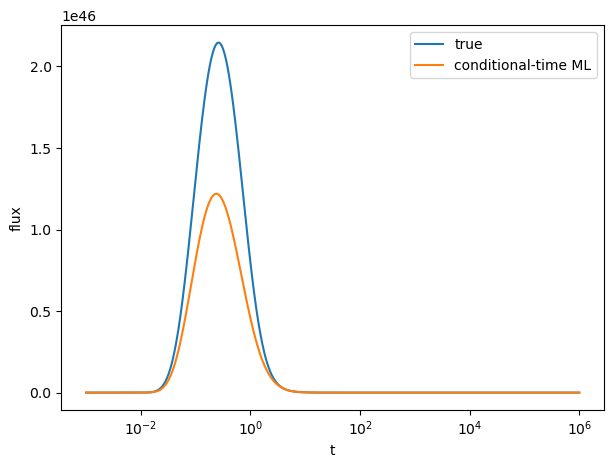

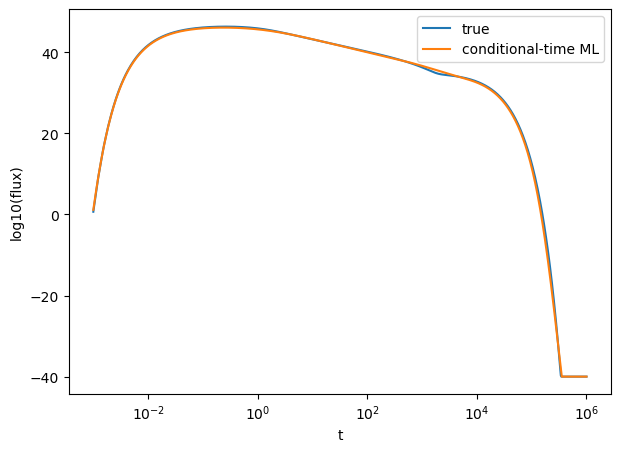

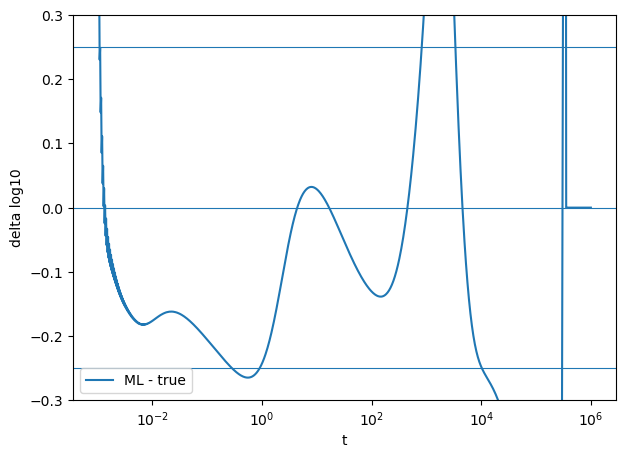

In [5]:
from prompt_progenitor import Prompt
import numpy as np
import matplotlib.pyplot as plt

prompt = Prompt(
    components=("jet",),            # just jet for now
    sample_gw_parameters=False,     # we will pass theta_los
    gw_param_mode="mass",           # so _extract_masses expects mass_1/mass_2
    j_struct="tophat",            # or 1/2/3
    eta_jet=1e-4,
    frac=0.1,
    phi_los_deg=0.0,
    default_theta_los_deg=0.0,
)

prompt.check_print()

params = {
    # jet knobs

    # viewing angle
    "theta_los": 10.0,         # degrees

    # binary / EOS inputs used in _derive_Eiso_jet
    "mass_1": 1.8,             # Msun
    "mass_2": 1.4,             # Msun
    "lambda_2": 300.0,         # dimensionless tidal deformability
}

import sys
print("CELL START")
sys.stdout.flush()

out = prompt.update_model(params, dry_run=False)

print("CELL END", out)
sys.stdout.flush()

def interp_logt(t_new, t, y, left=0.0, right=0.0):
    # assumes t increasing
    return np.interp(t_new, t, y, left=left, right=right)

t_grid = np.logspace(-3, 6, 1000).astype(np.float32)

y_interp = interp_logt(t_grid, prompt.t, prompt.total_X, left=0.0, right=0.0)

# predict_lightcurve_conditional_time.py
import numpy as np
import torch
import torch.nn as nn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_PATH = "lightcurve_conditional_time.pt"

torch.set_default_dtype(torch.float64)

class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.net(x))

class ConditionalTimeMLP(nn.Module):
    def __init__(self, in_dim=5, hidden=256, depth=4, dropout=0.05):
        super().__init__()
        layers = [
            nn.Linear(in_dim, hidden),
            nn.GELU(),
        ]
        for _ in range(depth):
            layers.append(ResidualBlock(hidden, dropout=dropout))
        layers += [
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        ]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

def featurize_physical(theta_los, mass_1, mass_2, lambda_2):
    m1, m2 = mass_1, mass_2
    if m2 > m1:
        m1, m2 = m2, m1
    return np.array(
        [
            theta_los / 60.0,
            m1,
            m2,
            np.log10(lambda_2 + 1.0),
        ],
        dtype=np.float64,
    )

def load_model(model_path=MODEL_PATH):
    ckpt = torch.load(model_path, map_location=DEVICE, weights_only=False)

    hidden = ckpt["config"]["hidden"]
    depth = ckpt["config"]["depth"]
    dropout = ckpt["config"]["dropout"]

    model = ConditionalTimeMLP(
        in_dim=5,
        hidden=hidden,
        depth=depth,
        dropout=dropout,
    ).to(DEVICE).double()

    model.load_state_dict(ckpt["model_state"])
    model.eval()
    return model, ckpt

def predict_physical(theta_los, mass_1, mass_2, lambda_2):
    model, ckpt = load_model(MODEL_PATH)

    x_feat = featurize_physical(theta_los, mass_1, mass_2, lambda_2)
    x_min = ckpt["x_min"].to(DEVICE, dtype=torch.float64)
    x_scale = ckpt["x_scale"].to(DEVICE, dtype=torch.float64)
    y_mean = ckpt["y_mean"].to(DEVICE, dtype=torch.float64)
    y_std = ckpt["y_std"].to(DEVICE, dtype=torch.float64)
    t_grid = ckpt["t_grid"].detach().cpu().numpy()
    logt_grid = ckpt["logt_grid"].detach().cpu().numpy()

    x = torch.tensor(x_feat, dtype=torch.float64, device=DEVICE).unsqueeze(0)
    xn = (x - x_min) / x_scale
    xn = torch.clamp(xn, 0.0, 1.0)

    x_rep = xn.repeat(len(logt_grid), 1)
    t_col = torch.tensor(logt_grid, dtype=torch.float64, device=DEVICE).unsqueeze(1)
    inp = torch.cat([x_rep, t_col], dim=1)

    with torch.no_grad():
        y_pred_n = model(inp)
        y_pred = y_pred_n * y_std + y_mean

        floor_log = np.log10(float(ckpt["y_floor"]))
        y_pred = torch.clamp(y_pred, min=floor_log)

    return t_grid, y_pred.detach().cpu().numpy()[None, :]

t_grid, y_pred_log = predict_physical(
    theta_los=10.0,
    mass_1=1.8,
    mass_2=1.4,
    lambda_2=300.0,
)

y_pred_log = y_pred_log[0]
y_true_log = np.log10(y_interp+1e-40)

# linear comparison
plt.figure(figsize=(7,5))
plt.plot(t_grid, 10**y_true_log, label="true")
plt.plot(t_grid, 10**y_pred_log, label="conditional-time ML")
plt.xscale("log")
plt.xlabel("t")
plt.ylabel("flux")
plt.legend()
plt.show()

# log-space comparison
plt.figure(figsize=(7,5))
plt.plot(t_grid, y_true_log, label="true")
plt.plot(t_grid, y_pred_log, label="conditional-time ML")
plt.xscale("log")
plt.xlabel("t")
plt.ylabel("log10(flux)")
plt.legend()
plt.show()

# diagnostic
diag = y_pred_log - y_true_log
plt.figure(figsize=(7,5))
plt.plot(t_grid, diag, label="ML - true")
plt.xscale("log")
plt.axhline(0.0, lw=0.8)
plt.axhline(0.25, lw=0.8)
plt.axhline(-0.25, lw=0.8)
plt.xlabel("t")
plt.ylabel("delta log10")
plt.ylim(-0.3,0.3)
plt.legend()
plt.show()

In [7]:
# train_lightcurve_pca_residual.py
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# Config
# -----------------------------
DATA_PATH = "prompt_bns_dataset_32k.npz"
BASE_MODEL_PATH = "lightcurve_pca_mlp_v2.pt"   # trained stage-1 PCA surrogate
MODEL_OUT = "lightcurve_pca_residual.pt"

BATCH_SIZE = 256
EPOCHS = 250
LR = 2e-4
WEIGHT_DECAY = 1e-5
VAL_FRAC = 0.1
TEST_FRAC = 0.1

HIDDEN = 256
DEPTH = 3
DROPOUT = 0.05
RESID_COMPONENTS = 16

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

torch.set_default_dtype(torch.float64)

# -----------------------------
# Reproducibility
# -----------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# -----------------------------
# Dataset
# -----------------------------
class CoeffDataset(Dataset):
    def __init__(self, Xn, Zn):
        self.Xn = torch.from_numpy(Xn).to(torch.float64)
        self.Zn = torch.from_numpy(Zn).to(torch.float64)

    def __len__(self):
        return self.Xn.shape[0]

    def __getitem__(self, idx):
        return self.Xn[idx], self.Zn[idx]

# -----------------------------
# Model
# -----------------------------
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.net(x))

class ResidualPCAMLP(nn.Module):
    def __init__(self, in_dim=4, out_dim=16, hidden=256, depth=3, dropout=0.05):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.GELU()]
        for _ in range(depth):
            layers.append(ResidualBlock(hidden, dropout=dropout))
        layers += [nn.Dropout(dropout), nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# -----------------------------
# Helpers
# -----------------------------
def make_splits(N, val_frac=0.1, test_frac=0.1, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(N)
    rng.shuffle(idx)

    n_test = int(test_frac * N)
    n_val = int(val_frac * N)
    n_train = N - n_val - n_test

    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train + n_val]
    test_idx = idx[n_train + n_val:]
    return train_idx, val_idx, test_idx

def normalize_X_minmax(X, x_min, x_scale):
    return (X - x_min) / x_scale

def fit_pca(Y_train, n_components):
    y_mean_curve = Y_train.mean(axis=0, keepdims=True)
    Yc = Y_train - y_mean_curve
    U, S, Vt = np.linalg.svd(Yc, full_matrices=False)

    K = min(n_components, Vt.shape[0])
    components = Vt[:K]
    coeffs_train = Yc @ components.T

    eigvals = (S ** 2) / max(Y_train.shape[0] - 1, 1)
    explained_var_ratio = eigvals[:K] / eigvals.sum()

    return y_mean_curve, components, coeffs_train, explained_var_ratio

def pca_encode(Y, y_mean_curve, components):
    return (Y - y_mean_curve) @ components.T

def pca_decode(Z, y_mean_curve, components):
    return Z @ components + y_mean_curve

# -----------------------------
# Stage-1 PCA surrogate loader
# -----------------------------
class BaseResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.net(x))

class BasePCAMLP(nn.Module):
    def __init__(self, in_dim=4, out_dim=32, hidden=512, depth=4, dropout=0.05):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.GELU()]
        for _ in range(depth):
            layers.append(BaseResidualBlock(hidden, dropout=dropout))
        layers += [nn.Dropout(dropout), nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def load_base_model(model_path):
    ckpt = torch.load(model_path, map_location=DEVICE, weights_only=False)

    hidden = ckpt["config"]["hidden"]
    depth = ckpt["config"]["depth"]
    dropout = ckpt["config"]["dropout"]
    n_components = ckpt["config"]["n_components"]

    model = BasePCAMLP(
        in_dim=4,
        out_dim=n_components,
        hidden=hidden,
        depth=depth,
        dropout=dropout,
    ).to(DEVICE).double()

    model.load_state_dict(ckpt["model_state"])
    model.eval()
    return model, ckpt

def predict_base_curve_from_normalized_x(Xn, base_model, base_ckpt):
    x = torch.from_numpy(Xn).to(torch.float64).to(DEVICE)

    z_mean = base_ckpt["z_mean"].to(DEVICE, dtype=torch.float64)
    z_std = base_ckpt["z_std"].to(DEVICE, dtype=torch.float64)
    y_mean_curve = base_ckpt["y_mean_curve"].to(DEVICE, dtype=torch.float64)
    components = base_ckpt["components"].to(DEVICE, dtype=torch.float64)

    with torch.no_grad():
        zn_pred = base_model(x)
        z_pred = zn_pred * z_std + z_mean
        y_pred = z_pred @ components + y_mean_curve

    return y_pred.detach().cpu().numpy()

# -----------------------------
# Loss and metrics
# -----------------------------
def smoothness_penalty(y):
    if y.shape[1] < 3:
        return torch.zeros((), dtype=y.dtype, device=y.device)
    d2 = y[:, 2:] - 2.0 * y[:, 1:-1] + y[:, :-2]
    return (d2 ** 2).mean()

def residual_reconstruction_loss(
    pred_rz,
    true_rz,
    rz_mean_t,
    rz_std_t,
    r_mean_curve_t,
    r_components_t,
    base_pred_y_t,
    true_y_t,
    floor_log=-40.0,
    margin=0.5,
    beta=0.5,
    bright_weight=3.0,
    smooth_weight=1e-3,
):
    pred_rz_denorm = pred_rz * rz_std_t + rz_mean_t
    true_rz_denorm = true_rz * rz_std_t + rz_mean_t

    pred_resid = pred_rz_denorm @ r_components_t + r_mean_curve_t
    # true_resid = true_rz_denorm @ r_components_t + r_mean_curve_t  # not needed directly

    pred_y = base_pred_y_t + pred_resid
    target_y = true_y_t

    mask = target_y > (floor_log + margin)

    diff = pred_y - target_y
    abs_diff = torch.abs(diff)
    huber = torch.where(
        abs_diff < beta,
        0.5 * diff * diff / beta,
        abs_diff - 0.5 * beta,
    )

    if mask.sum() > 0:
        bright = torch.clamp(target_y - (floor_log + margin), min=0.0)
        weights = 1.0 + bright_weight * bright / bright.mean().clamp_min(1e-12)
        recon_loss = (huber[mask] * weights[mask]).mean()
    else:
        recon_loss = huber.mean()

    smooth_loss = smoothness_penalty(pred_y)
    return recon_loss + smooth_weight * smooth_loss

def evaluate(
    model,
    loader,
    rz_mean_t,
    rz_std_t,
    r_mean_curve_t,
    r_components_t,
    floor_log,
):
    model.eval()
    total_loss = 0.0
    total_mae_log = 0.0
    total_peak_mae_log = 0.0
    n = 0

    with torch.no_grad():
        for xb, rzb, base_yb, true_yb in loader:
            xb = xb.to(DEVICE)
            rzb = rzb.to(DEVICE)
            base_yb = base_yb.to(DEVICE)
            true_yb = true_yb.to(DEVICE)

            pred = model(xb)
            loss = residual_reconstruction_loss(
                pred, rzb,
                rz_mean_t, rz_std_t,
                r_mean_curve_t, r_components_t,
                base_yb, true_yb,
                floor_log=floor_log,
            )

            pred_rz_denorm = pred * rz_std_t + rz_mean_t
            pred_resid = pred_rz_denorm @ r_components_t + r_mean_curve_t
            pred_y = base_yb + pred_resid

            mask = true_yb > (floor_log + 0.5)
            if mask.sum() > 0:
                mae_log = torch.abs(pred_y - true_yb)[mask].mean()
            else:
                mae_log = torch.abs(pred_y - true_yb).mean()

            pred_peak = pred_y.max(dim=1).values
            true_peak = true_yb.max(dim=1).values
            peak_mae_log = torch.abs(pred_peak - true_peak).mean()

            bs = xb.size(0)
            total_loss += loss.item() * bs
            total_mae_log += mae_log.item() * bs
            total_peak_mae_log += peak_mae_log.item() * bs
            n += bs

    return total_loss / n, total_mae_log / n, total_peak_mae_log / n

# -----------------------------
# Dataset with base predictions
# -----------------------------
class ResidualDataset(Dataset):
    def __init__(self, Xn, RZn, baseY, trueY):
        self.Xn = torch.from_numpy(Xn).to(torch.float64)
        self.RZn = torch.from_numpy(RZn).to(torch.float64)
        self.baseY = torch.from_numpy(baseY).to(torch.float64)
        self.trueY = torch.from_numpy(trueY).to(torch.float64)

    def __len__(self):
        return self.Xn.shape[0]

    def __getitem__(self, idx):
        return self.Xn[idx], self.RZn[idx], self.baseY[idx], self.trueY[idx]

# -----------------------------
# Train
# -----------------------------
def train():
    # load raw data
    d = np.load(DATA_PATH)
    X = d["X"].astype(np.float64)
    Y = d["Y"].astype(np.float64)
    t_grid = d["t_grid"].astype(np.float64)
    y_floor = float(d["y_floor"]) if "y_floor" in d else 1e-40
    floor_log = np.log10(y_floor)

    N = X.shape[0]
    train_idx, val_idx, test_idx = make_splits(N, VAL_FRAC, TEST_FRAC, SEED)

    # load stage-1 model
    base_model, base_ckpt = load_base_model(BASE_MODEL_PATH)

    # use exact same X normalization as stage-1
    x_min = base_ckpt["x_min"].detach().cpu().numpy()
    x_scale = base_ckpt["x_scale"].detach().cpu().numpy()

    X_train = normalize_X_minmax(X[train_idx], x_min, x_scale)
    X_val   = normalize_X_minmax(X[val_idx],   x_min, x_scale)
    X_test  = normalize_X_minmax(X[test_idx],  x_min, x_scale)

    X_train = np.clip(X_train, 0.0, 1.0)
    X_val   = np.clip(X_val,   0.0, 1.0)
    X_test  = np.clip(X_test,  0.0, 1.0)

    # stage-1 predictions
    baseY_train = predict_base_curve_from_normalized_x(X_train, base_model, base_ckpt)
    baseY_val   = predict_base_curve_from_normalized_x(X_val,   base_model, base_ckpt)
    baseY_test  = predict_base_curve_from_normalized_x(X_test,  base_model, base_ckpt)

    # residuals in log space
    R_train = Y[train_idx] - baseY_train
    R_val   = Y[val_idx]   - baseY_val
    R_test  = Y[test_idx]  - baseY_test

    # PCA on residuals
    r_mean_curve, r_components, RZ_train_raw, explained = fit_pca(R_train, RESID_COMPONENTS)
    RZ_val_raw  = pca_encode(R_val,  r_mean_curve, r_components)
    RZ_test_raw = pca_encode(R_test, r_mean_curve, r_components)

    # normalize residual latent coeffs
    rz_mean = RZ_train_raw.mean(axis=0, keepdims=True)
    rz_std = RZ_train_raw.std(axis=0, keepdims=True)
    rz_std = np.maximum(rz_std, 1e-12)

    RZ_train = (RZ_train_raw - rz_mean) / rz_std
    RZ_val   = (RZ_val_raw   - rz_mean) / rz_std
    RZ_test  = (RZ_test_raw  - rz_mean) / rz_std

    train_ds = ResidualDataset(X_train, RZ_train, baseY_train, Y[train_idx])
    val_ds   = ResidualDataset(X_val,   RZ_val,   baseY_val,   Y[val_idx])
    test_ds  = ResidualDataset(X_test,  RZ_test,  baseY_test,  Y[test_idx])

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = ResidualPCAMLP(
        in_dim=4,
        out_dim=r_components.shape[0],
        hidden=HIDDEN,
        depth=DEPTH,
        dropout=DROPOUT,
    ).to(DEVICE).double()

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=12
    )

    rz_mean_t = torch.tensor(rz_mean, dtype=torch.float64, device=DEVICE)
    rz_std_t = torch.tensor(rz_std, dtype=torch.float64, device=DEVICE)
    r_mean_curve_t = torch.tensor(r_mean_curve, dtype=torch.float64, device=DEVICE)
    r_components_t = torch.tensor(r_components, dtype=torch.float64, device=DEVICE)

    best_val = float("inf")
    patience = 30
    bad_epochs = 0

    print(f"Device: {DEVICE}")
    print(f"Residual PCA dim = {r_components.shape[0]}")
    print(f"Residual explained variance: {explained.sum():.6f}")

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_train = 0.0
        n = 0

        for xb, rzb, base_yb, true_yb in train_loader:
            xb = xb.to(DEVICE)
            rzb = rzb.to(DEVICE)
            base_yb = base_yb.to(DEVICE)
            true_yb = true_yb.to(DEVICE)

            optimizer.zero_grad()
            pred = model(xb)

            loss = residual_reconstruction_loss(
                pred, rzb,
                rz_mean_t, rz_std_t,
                r_mean_curve_t, r_components_t,
                base_yb, true_yb,
                floor_log=floor_log,
            )

            if not torch.isfinite(loss):
                optimizer.zero_grad()
                continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_train += loss.item() * xb.size(0)
            n += xb.size(0)

        train_loss = total_train / max(n, 1)
        val_loss, val_mae_log, val_peak_mae_log = evaluate(
            model, val_loader,
            rz_mean_t, rz_std_t,
            r_mean_curve_t, r_components_t,
            floor_log
        )
        scheduler.step(val_loss)

        lr_now = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch:03d} | "
            f"train {train_loss:.6f} | "
            f"val {val_loss:.6f} | "
            f"val_mae_log {val_mae_log:.6f} | "
            f"val_peak_mae_log {val_peak_mae_log:.6f} | "
            f"lr {lr_now:.2e}"
        )

        if val_loss < best_val:
            best_val = val_loss
            bad_epochs = 0

            ckpt = {
                "model_state": model.state_dict(),
                "base_model_path": BASE_MODEL_PATH,
                "rz_mean": torch.tensor(rz_mean, dtype=torch.float64),
                "rz_std": torch.tensor(rz_std, dtype=torch.float64),
                "r_mean_curve": torch.tensor(r_mean_curve, dtype=torch.float64),
                "r_components": torch.tensor(r_components, dtype=torch.float64),
                "t_grid": torch.tensor(t_grid, dtype=torch.float64),
                "y_floor": y_floor,
                "residual_explained_variance_ratio": torch.tensor(explained, dtype=torch.float64),
                "config": {
                    "hidden": HIDDEN,
                    "depth": DEPTH,
                    "dropout": DROPOUT,
                    "resid_components": r_components.shape[0],
                    "batch_size": BATCH_SIZE,
                    "lr": LR,
                    "weight_decay": WEIGHT_DECAY,
                },
            }
            torch.save(ckpt, MODEL_OUT)
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            print("Early stopping.")
            break

    print(f"Best val loss: {best_val:.6f}")
    print(f"Saved model to: {MODEL_OUT}")

    ckpt = torch.load(MODEL_OUT, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    test_loss, test_mae_log, test_peak_mae_log = evaluate(
        model, test_loader,
        rz_mean_t, rz_std_t,
        r_mean_curve_t, r_components_t,
        floor_log
    )
    print(f"Test loss: {test_loss:.6f}")
    print(f"Test MAE(log10): {test_mae_log:.6f}")
    print(f"Test peak MAE(log10): {test_peak_mae_log:.6f}")

if __name__ == "__main__":
    train()

Device: cpu
Residual PCA dim = 16
Residual explained variance: 0.997430
Epoch 001 | train 1.603973 | val 0.157070 | val_mae_log 0.138939 | val_peak_mae_log 0.062155 | lr 2.00e-04
Epoch 002 | train 0.218170 | val 0.145124 | val_mae_log 0.132117 | val_peak_mae_log 0.055420 | lr 2.00e-04
Epoch 003 | train 0.214910 | val 0.146439 | val_mae_log 0.133433 | val_peak_mae_log 0.049367 | lr 2.00e-04
Epoch 004 | train 0.196725 | val 0.150971 | val_mae_log 0.135509 | val_peak_mae_log 0.053062 | lr 2.00e-04
Epoch 005 | train 0.194748 | val 0.150588 | val_mae_log 0.137277 | val_peak_mae_log 0.056209 | lr 2.00e-04
Epoch 006 | train 0.186867 | val 0.149893 | val_mae_log 0.136998 | val_peak_mae_log 0.068823 | lr 2.00e-04
Epoch 007 | train 0.185244 | val 0.144012 | val_mae_log 0.131199 | val_peak_mae_log 0.048508 | lr 2.00e-04
Epoch 008 | train 0.180183 | val 0.142200 | val_mae_log 0.129748 | val_peak_mae_log 0.049248 | lr 2.00e-04
Epoch 009 | train 0.180513 | val 0.183175 | val_mae_log 0.151951 | val_p

In [12]:
# predict_lightcurve_pca_residual.py
import numpy as np
import torch
import torch.nn as nn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BASE_MODEL_PATH = "lightcurve_pca_mlp_v2.pt"
RESID_MODEL_PATH = "lightcurve_pca_residual.pt"

torch.set_default_dtype(torch.float64)

# ---------- shared blocks ----------
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.net(x))

# ---------- stage-1 ----------
class BasePCAMLP(nn.Module):
    def __init__(self, in_dim=4, out_dim=32, hidden=512, depth=4, dropout=0.05):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.GELU()]
        for _ in range(depth):
            layers.append(ResidualBlock(hidden, dropout=dropout))
        layers += [nn.Dropout(dropout), nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# ---------- stage-2 ----------
class ResidualPCAMLP(nn.Module):
    def __init__(self, in_dim=4, out_dim=16, hidden=256, depth=3, dropout=0.05):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.GELU()]
        for _ in range(depth):
            layers.append(ResidualBlock(hidden, dropout=dropout))
        layers += [nn.Dropout(dropout), nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def featurize_physical(theta_los, mass_1, mass_2, lambda_2):
    m1, m2 = mass_1, mass_2
    if m2 > m1:
        m1, m2 = m2, m1
    return np.array(
        [
            theta_los / 60.0,
            m1,
            m2,
            np.log10(lambda_2 + 1.0),
        ],
        dtype=np.float64,
    )

def load_base_model(model_path=BASE_MODEL_PATH):
    ckpt = torch.load(model_path, map_location=DEVICE, weights_only=False)

    hidden = ckpt["config"]["hidden"]
    depth = ckpt["config"]["depth"]
    dropout = ckpt["config"]["dropout"]
    n_components = ckpt["config"]["n_components"]

    model = BasePCAMLP(
        in_dim=4,
        out_dim=n_components,
        hidden=hidden,
        depth=depth,
        dropout=dropout,
    ).to(DEVICE).double()
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    return model, ckpt

def load_resid_model(model_path=RESID_MODEL_PATH):
    ckpt = torch.load(model_path, map_location=DEVICE, weights_only=False)

    hidden = ckpt["config"]["hidden"]
    depth = ckpt["config"]["depth"]
    dropout = ckpt["config"]["dropout"]
    resid_components = ckpt["config"]["resid_components"]

    model = ResidualPCAMLP(
        in_dim=4,
        out_dim=resid_components,
        hidden=hidden,
        depth=depth,
        dropout=dropout,
    ).to(DEVICE).double()
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    return model, ckpt

def predict_physical(theta_los, mass_1, mass_2, lambda_2):
    x_feat = featurize_physical(theta_los, mass_1, mass_2, lambda_2)
    x = torch.tensor(x_feat, dtype=torch.float64, device=DEVICE).unsqueeze(0)

    # stage-1
    base_model, base_ckpt = load_base_model(BASE_MODEL_PATH)
    x_min = base_ckpt["x_min"].to(DEVICE, dtype=torch.float64)
    x_scale = base_ckpt["x_scale"].to(DEVICE, dtype=torch.float64)
    z_mean = base_ckpt["z_mean"].to(DEVICE, dtype=torch.float64)
    z_std = base_ckpt["z_std"].to(DEVICE, dtype=torch.float64)
    y_mean_curve = base_ckpt["y_mean_curve"].to(DEVICE, dtype=torch.float64)
    components = base_ckpt["components"].to(DEVICE, dtype=torch.float64)
    t_grid = base_ckpt["t_grid"].detach().cpu().numpy()

    xn = (x - x_min) / x_scale
    xn = torch.clamp(xn, 0.0, 1.0)

    with torch.no_grad():
        zn_pred = base_model(xn)
        z_pred = zn_pred * z_std + z_mean
        y_base = z_pred @ components + y_mean_curve

    # stage-2 residual
    resid_model, resid_ckpt = load_resid_model(RESID_MODEL_PATH)
    rz_mean = resid_ckpt["rz_mean"].to(DEVICE, dtype=torch.float64)
    rz_std = resid_ckpt["rz_std"].to(DEVICE, dtype=torch.float64)
    r_mean_curve = resid_ckpt["r_mean_curve"].to(DEVICE, dtype=torch.float64)
    r_components = resid_ckpt["r_components"].to(DEVICE, dtype=torch.float64)

    with torch.no_grad():
        rzn_pred = resid_model(xn)
        rz_pred = rzn_pred * rz_std + rz_mean
        y_resid = rz_pred @ r_components + r_mean_curve

        y_final = y_base + y_resid
        floor_log = np.log10(float(base_ckpt["y_floor"]))
        y_final = torch.clamp(y_final, min=floor_log)

    return t_grid, y_final.detach().cpu().numpy()

def predict_physical_full(theta_los, mass_1, mass_2, lambda_2):
    x_feat = featurize_physical(theta_los, mass_1, mass_2, lambda_2)
    x = torch.tensor(x_feat, dtype=torch.float64, device=DEVICE).unsqueeze(0)

    # stage-1
    base_model, base_ckpt = load_base_model(BASE_MODEL_PATH)
    x_min = base_ckpt["x_min"].to(DEVICE, dtype=torch.float64)
    x_scale = base_ckpt["x_scale"].to(DEVICE, dtype=torch.float64)
    z_mean = base_ckpt["z_mean"].to(DEVICE, dtype=torch.float64)
    z_std = base_ckpt["z_std"].to(DEVICE, dtype=torch.float64)
    y_mean_curve = base_ckpt["y_mean_curve"].to(DEVICE, dtype=torch.float64)
    components = base_ckpt["components"].to(DEVICE, dtype=torch.float64)
    t_grid = base_ckpt["t_grid"].detach().cpu().numpy()

    xn = (x - x_min) / x_scale
    xn = torch.clamp(xn, 0.0, 1.0)

    with torch.no_grad():
        zn_pred = base_model(xn)
        z_pred = zn_pred * z_std + z_mean
        y_base = z_pred @ components + y_mean_curve

    # stage-2 residual
    resid_model, resid_ckpt = load_resid_model(RESID_MODEL_PATH)
    rz_mean = resid_ckpt["rz_mean"].to(DEVICE, dtype=torch.float64)
    rz_std = resid_ckpt["rz_std"].to(DEVICE, dtype=torch.float64)
    r_mean_curve = resid_ckpt["r_mean_curve"].to(DEVICE, dtype=torch.float64)
    r_components = resid_ckpt["r_components"].to(DEVICE, dtype=torch.float64)

    with torch.no_grad():
        rzn_pred = resid_model(xn)
        rz_pred = rzn_pred * rz_std + rz_mean
        y_resid = rz_pred @ r_components + r_mean_curve

        y_final = y_base + y_resid
        floor_log = np.log10(float(base_ckpt["y_floor"]))
        y_base = torch.clamp(y_base, min=floor_log)
        y_final = torch.clamp(y_final, min=floor_log)

    return (
        t_grid,
        y_base.detach().cpu().numpy(),
        y_final.detach().cpu().numpy(),
    )

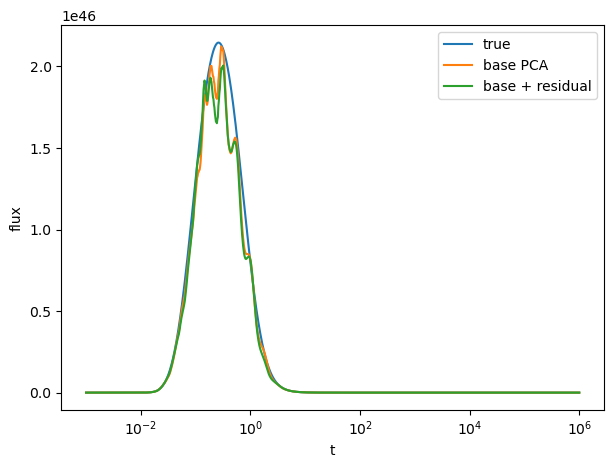

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# y_true_log should be shape (1000,)
t_grid, y_base_log, y_final_log = predict_physical_full(
    theta_los=10.0,
    mass_1=1.8,
    mass_2=1.4,
    lambda_2=300.0,
)

y_base_log = y_base_log[0]
y_final_log = y_final_log[0]

plt.figure(figsize=(7,5))
plt.plot(t_grid, 10**np.log10(y_interp+1e-40), label="true")
plt.plot(t_grid, 10**y_base_log, label="base PCA")
plt.plot(t_grid, 10**y_final_log, label="base + residual")
plt.xscale("log")
plt.xlabel("t")
plt.ylabel("flux")
plt.legend()
plt.show()

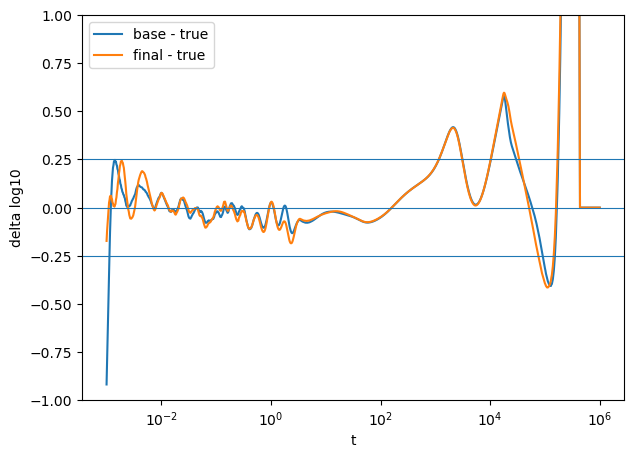

In [12]:
diag_base = y_base_log - np.log10(y_interp+1e-40)
diag_final = y_final_log - np.log10(y_interp+1e-40)

plt.figure(figsize=(7,5))
plt.plot(t_grid, diag_base, label="base - true")
plt.plot(t_grid, diag_final, label="final - true")
plt.xscale("log")
plt.axhline(0.25, lw=0.8)
plt.axhline(-0.25, lw=0.8)
plt.axhline(0.0, lw=0.8)
plt.ylim(-1,1)
plt.xlabel("t")
plt.ylabel("delta log10")
plt.legend()
plt.show()

PCA ceiling MAE(log10):      0.191283
PCA ceiling RMSE(log10):     0.385237
PCA ceiling Peak err(log10): 0.042100
PCA ceiling Peak factor:      1.101794
ML total MAE(log10):      0.825995
ML total RMSE(log10):     2.930306
ML total Peak err(log10): -0.005391
ML total Peak factor:      1.012492
ML vs PCA ceiling MAE(log10):      0.806527
ML vs PCA ceiling RMSE(log10):     2.904872
ML vs PCA ceiling Peak err(log10): -0.047492
ML vs PCA ceiling Peak factor:      1.115557


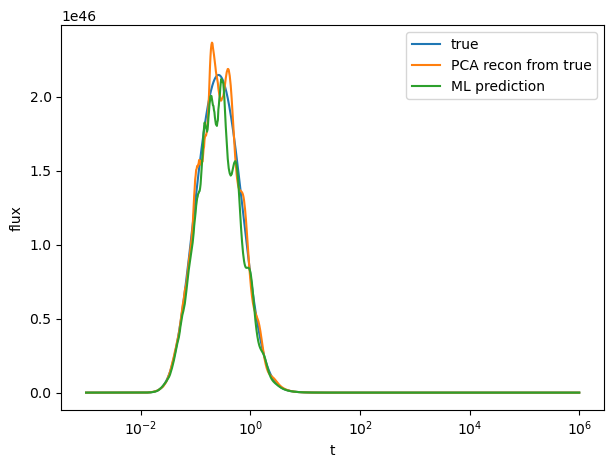

In [17]:
import numpy as np
import torch
import torch.nn as nn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_PATH = "lightcurve_pca_mlp_v2.pt"

class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.net(x))

class PCAMLP(nn.Module):
    def __init__(self, in_dim=4, out_dim=32, hidden=512, depth=4, dropout=0.05):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.GELU()]
        for _ in range(depth):
            layers.append(ResidualBlock(hidden, dropout=dropout))
        layers += [nn.Dropout(dropout), nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def load_pca_model(model_path=MODEL_PATH):
    ckpt = torch.load(model_path, map_location=DEVICE, weights_only=False)

    hidden = ckpt["config"]["hidden"]
    depth = ckpt["config"]["depth"]
    dropout = ckpt["config"]["dropout"]
    n_components = ckpt["config"]["n_components"]

    model = PCAMLP(
        in_dim=4,
        out_dim=n_components,
        hidden=hidden,
        depth=depth,
        dropout=dropout,
    ).to(DEVICE).double()

    model.load_state_dict(ckpt["model_state"])
    model.eval()
    return model, ckpt

def pca_encode(y_true_log, ckpt):
    """
    y_true_log: shape (1000,) or (1,1000), in log10 space
    returns z_true shape (1, K)
    """
    y = np.asarray(y_true_log, dtype=np.float64)
    if y.ndim == 1:
        y = y[None, :]

    y_mean_curve = ckpt["y_mean_curve"].detach().cpu().numpy()   # (1, T)
    components = ckpt["components"].detach().cpu().numpy()       # (K, T)

    z_true = (y - y_mean_curve) @ components.T
    return z_true

def pca_decode(z, ckpt):
    """
    z: shape (K,) or (1,K)
    returns reconstructed curve shape (1, T)
    """
    z = np.asarray(z, dtype=np.float64)
    if z.ndim == 1:
        z = z[None, :]

    y_mean_curve = ckpt["y_mean_curve"].detach().cpu().numpy()
    components = ckpt["components"].detach().cpu().numpy()

    y_recon = z @ components + y_mean_curve
    return y_recon

def predict_pca_curve_from_features(x_feat, model, ckpt):
    x = torch.tensor(x_feat, dtype=torch.float64, device=DEVICE)
    if x.ndim == 1:
        x = x.unsqueeze(0)

    x_min = ckpt["x_min"].to(DEVICE, dtype=torch.float64)
    x_scale = ckpt["x_scale"].to(DEVICE, dtype=torch.float64)
    z_mean = ckpt["z_mean"].to(DEVICE, dtype=torch.float64)
    z_std = ckpt["z_std"].to(DEVICE, dtype=torch.float64)
    y_mean_curve = ckpt["y_mean_curve"].to(DEVICE, dtype=torch.float64)
    components = ckpt["components"].to(DEVICE, dtype=torch.float64)

    xn = (x - x_min) / x_scale
    xn = torch.clamp(xn, 0.0, 1.0)

    with torch.no_grad():
        zn_pred = model(xn)
        z_pred = zn_pred * z_std + z_mean
        y_pred = z_pred @ components + y_mean_curve

    return z_pred.detach().cpu().numpy(), y_pred.detach().cpu().numpy()

def pca_diagnostic(y_true_log, x_feat=None, model_path=MODEL_PATH):
    model, ckpt = load_pca_model(model_path)

    y_true = np.asarray(y_true_log, dtype=np.float64)
    if y_true.ndim == 1:
        y_true = y_true[None, :]

    t_grid = ckpt["t_grid"].detach().cpu().numpy()

    # 1) PCA ceiling: true -> encode -> decode
    z_true = pca_encode(y_true, ckpt)
    y_pca_recon_true = pca_decode(z_true, ckpt)

    out = {
        "t_grid": t_grid,
        "y_true_log": y_true,
        "z_true": z_true,
        "y_pca_recon_true_log": y_pca_recon_true,
    }

    # 2) ML prediction, if x_feat is provided
    if x_feat is not None:
        z_pred, y_ml_pred = predict_pca_curve_from_features(x_feat, model, ckpt)
        out["z_pred"] = z_pred
        out["y_ml_pred_log"] = y_ml_pred

    return out

def summarize_curve_error(y_a_log, y_b_log, name=""):
    y_a = np.asarray(y_a_log)
    y_b = np.asarray(y_b_log)

    delta = y_a - y_b
    mae_log = np.mean(np.abs(delta))
    rmse_log = np.sqrt(np.mean(delta**2))
    peak_err_log = np.max(y_a) - np.max(y_b)

    print(f"{name} MAE(log10):      {mae_log:.6f}")
    print(f"{name} RMSE(log10):     {rmse_log:.6f}")
    print(f"{name} Peak err(log10): {peak_err_log:.6f}")
    print(f"{name} Peak factor:      {10**abs(peak_err_log):.6f}")

import matplotlib.pyplot as plt

def plot_pca_diagnostic(diag):
    t = diag["t_grid"]
    y_true = diag["y_true_log"][0]
    y_pca = diag["y_pca_recon_true_log"][0]

    plt.figure(figsize=(7,5))
    plt.plot(t, 10**y_true, label="true")
    plt.plot(t, 10**y_pca, label="PCA recon from true")

    if "y_ml_pred_log" in diag:
        y_ml = diag["y_ml_pred_log"][0]
        plt.plot(t, 10**y_ml, label="ML prediction")

    plt.xscale("log")
    plt.legend()
    plt.xlabel("t")
    plt.ylabel("flux")
    plt.show()

diag = pca_diagnostic(np.log10(y_interp+1e-40), x_feat=featurize_physical(10, 1.6, 1.4, 300), model_path="lightcurve_pca_mlp_v2.pt")

summarize_curve_error(
    diag["y_pca_recon_true_log"][0],
    diag["y_true_log"][0],
    name="PCA ceiling"
)

summarize_curve_error(
    diag["y_ml_pred_log"][0],
    diag["y_true_log"][0],
    name="ML total"
)

summarize_curve_error(
    diag["y_ml_pred_log"][0],
    diag["y_pca_recon_true_log"][0],
    name="ML vs PCA ceiling"
)

plot_pca_diagnostic(diag)

Object OK!
CELL START
Updating model...
eisojet val 1.1403765767974741e+49
Jet Constructed Successfully...
CELL END None


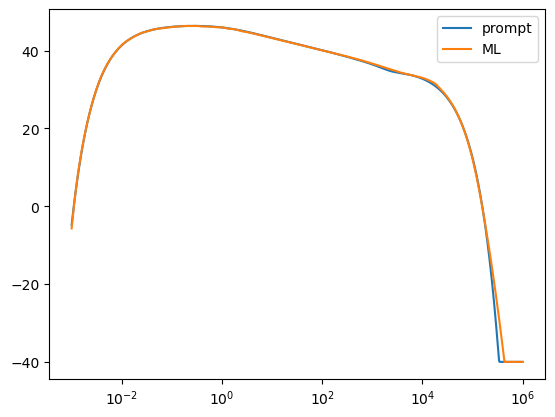

In [4]:
from prompt_progenitor import Prompt
import numpy as np
import matplotlib.pyplot as plt

prompt = Prompt(
    components=("jet",),            # just jet for now
    sample_gw_parameters=False,     # we will pass theta_los
    gw_param_mode="mass",           # so _extract_masses expects mass_1/mass_2
    j_struct="tophat",            # or 1/2/3
    eta_jet=1e-4,
    frac=0.1,
    phi_los_deg=0.0,
    default_theta_los_deg=0.0,
)

prompt.check_print()

params = {
    # jet knobs

    # viewing angle
    "theta_los": 20.0,         # degrees

    # binary / EOS inputs used in _derive_Eiso_jet
    "mass_1": 1.8,             # Msun
    "mass_2": 1.4,             # Msun
    "lambda_2": 300.0,         # dimensionless tidal deformability
}

import sys
print("CELL START")
sys.stdout.flush()

out = prompt.update_model(params, dry_run=False)

print("CELL END", out)
sys.stdout.flush()

def interp_logt(t_new, t, y, left=0.0, right=0.0):
    # assumes t increasing
    return np.interp(t_new, t, y, left=left, right=right)

t_grid = np.logspace(-3, 6, 1000).astype(np.float32)

y_interp = interp_logt(t_grid, prompt.t, prompt.total_X, left=0.0, right=0.0)

# plt.plot(t_grid, np.log10(prompt.total_X+1e-40))
plt.plot(t_grid, np.log10(y_interp+1e-40), label='prompt')
plt.plot(t_grid, np.float64(y_final), label='ML')

plt.xscale('log')
# plt.yscale('log')
plt.legend()
plt.show()

In [ ]:
from prompt_progenitor import Prompt
import numpy as np
import matplotlib.pyplot as plt

prompt = Prompt(
    components=("jet",),            # just jet for now
    sample_gw_parameters=False,     # we will pass theta_los
    gw_param_mode="mass",           # so _extract_masses expects mass_1/mass_2
    j_struct="tophat",            # or 1/2/3
    eta_jet=1e-4,
    frac=0.1,
    phi_los_deg=0.0,
    default_theta_los_deg=0.0,
)

prompt.check_print()

params = {
    # jet knobs

    # viewing angle
    "theta_los": 20.0,         # degrees

    # binary / EOS inputs used in _derive_Eiso_jet
    "mass_1": 1.8,             # Msun
    "mass_2": 1.4,             # Msun
    "lambda_2": 300.0,         # dimensionless tidal deformability
}

import sys
print("CELL START")
sys.stdout.flush()

out = prompt.update_model(params, dry_run=False)

print("CELL END", out)
sys.stdout.flush()

def interp_logt(t_new, t, y, left=0.0, right=0.0):
    # assumes t increasing
    return np.interp(t_new, t, y, left=left, right=right)

t_grid = np.logspace(-3, 6, 1000).astype(np.float32)

y_interp = interp_logt(t_grid, prompt.t, prompt.total_X, left=0.0, right=0.0)

# plt.plot(t_grid, np.log10(prompt.total_X+1e-40))
plt.plot(t_grid, (y_interp+1e-40), label='prompt')
plt.plot(t_grid, 10**np.float64(y[0]), label='ML')
# plt.xlim(1e4, 1e6)

plt.xscale('log')
# plt.yscale('log')
plt.legend()
plt.show()

In [3]:
# predict_lightcurve_pca.py
import numpy as np
import torch
import torch.nn as nn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_PATH = "lightcurve_pca_mlp_v2.pt"

torch.set_default_dtype(torch.float64)

class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.net(x))

class PCAMLP(nn.Module):
    def __init__(self, in_dim=4, out_dim=32, hidden=512, depth=4, dropout=0.05):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.GELU()]
        for _ in range(depth):
            layers.append(ResidualBlock(hidden, dropout=dropout))
        layers += [nn.Dropout(dropout), nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def featurize_physical(theta_los, mass_1, mass_2, lambda_2):
    m1, m2 = mass_1, mass_2
    if m2 > m1:
        m1, m2 = m2, m1
    return np.array(
        [
            theta_los / 60.0,
            m1,
            m2,
            np.log10(lambda_2 + 1.0),
        ],
        dtype=np.float64,
    )

def load_model(model_path=MODEL_PATH):
    ckpt = torch.load(model_path, map_location=DEVICE, weights_only=False)

    hidden = ckpt["config"]["hidden"]
    depth = ckpt["config"]["depth"]
    dropout = ckpt["config"]["dropout"]
    n_components = ckpt["config"]["n_components"]

    model = PCAMLP(
        in_dim=4,
        out_dim=n_components,
        hidden=hidden,
        depth=depth,
        dropout=dropout,
    ).to(DEVICE).double()

    model.load_state_dict(ckpt["model_state"])
    model.eval()
    return model, ckpt

def predict_from_features(x_feat):
    model, ckpt = load_model()

    x = torch.tensor(x_feat, dtype=torch.float64, device=DEVICE)
    if x.ndim == 1:
        x = x.unsqueeze(0)

    x_min = ckpt["x_min"].to(DEVICE, dtype=torch.float64)
    x_scale = ckpt["x_scale"].to(DEVICE, dtype=torch.float64)
    z_mean = ckpt["z_mean"].to(DEVICE, dtype=torch.float64)
    z_std = ckpt["z_std"].to(DEVICE, dtype=torch.float64)
    y_mean_curve = ckpt["y_mean_curve"].to(DEVICE, dtype=torch.float64)
    components = ckpt["components"].to(DEVICE, dtype=torch.float64)
    t_grid = ckpt["t_grid"].detach().cpu().numpy()

    xn = (x - x_min) / x_scale
    xn = torch.clamp(xn, 0.0, 1.0)

    with torch.no_grad():
        zn_pred = model(xn)
        z_pred = zn_pred * z_std + z_mean
        y_pred = z_pred @ components + y_mean_curve

        floor_log = np.log10(float(ckpt["y_floor"]))
        y_pred = torch.clamp(y_pred, min=floor_log)

    return t_grid, y_pred.detach().cpu().numpy()

def predict_physical(theta_los, mass_1, mass_2, lambda_2):
    x = featurize_physical(theta_los, mass_1, mass_2, lambda_2)
    return predict_from_features(x)

if __name__ == "__main__":
    t, y = predict_physical(
        theta_los=20,
        mass_1=1.8,
        mass_2=1.4,
        lambda_2=300.0,
    )
    print("t_grid shape:", t.shape)
    print("predicted curve shape:", y.shape)
    print("pred min/max:", y.min(), y.max())

t_grid shape: (1000,)
predicted curve shape: (1, 1000)
pred min/max: -40.0 46.349710794371134


In [57]:
# train_lightcurve_pca.py
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# Config
# -----------------------------
DATA_PATH = "prompt_bns_dataset_32k.npz"
BATCH_SIZE = 256
EPOCHS = 300
LR = 2e-4
WEIGHT_DECAY = 1e-5
VAL_FRAC = 0.1
TEST_FRAC = 0.1
HIDDEN = 512
DEPTH = 4
DROPOUT = 0.05
N_COMPONENTS = 16
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_OUT = "lightcurve_pca16_mlp.pt"

torch.set_default_dtype(torch.float64)

# -----------------------------
# Reproducibility
# -----------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# -----------------------------
# Featurization
# -----------------------------
def featurize_physical(theta_los, mass_1, mass_2, lambda_2):
    m1, m2 = mass_1, mass_2
    if m2 > m1:
        m1, m2 = m2, m1
    return np.array(
        [
            theta_los / 60.0,
            m1,
            m2,
            np.log10(lambda_2 + 1.0),
        ],
        dtype=np.float64,
    )

# -----------------------------
# Dataset
# -----------------------------
class CoeffDataset(Dataset):
    def __init__(self, Xn, Zn):
        self.Xn = torch.from_numpy(Xn).to(torch.float64)
        self.Zn = torch.from_numpy(Zn).to(torch.float64)

    def __len__(self):
        return self.Xn.shape[0]

    def __getitem__(self, idx):
        return self.Xn[idx], self.Zn[idx]

# -----------------------------
# Model
# -----------------------------
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.net(x))

class PCAMLP(nn.Module):
    def __init__(self, in_dim=4, out_dim=32, hidden=512, depth=4, dropout=0.05):
        super().__init__()
        layers = [
            nn.Linear(in_dim, hidden),
            nn.GELU(),
        ]
        for _ in range(depth):
            layers.append(ResidualBlock(hidden, dropout=dropout))
        layers += [
            nn.Dropout(dropout),
            nn.Linear(hidden, out_dim),
        ]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# -----------------------------
# Helpers
# -----------------------------
def make_splits(N, val_frac=0.1, test_frac=0.1, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(N)
    rng.shuffle(idx)

    n_test = int(test_frac * N)
    n_val = int(val_frac * N)
    n_train = N - n_val - n_test

    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train + n_val]
    test_idx = idx[n_train + n_val:]
    return train_idx, val_idx, test_idx

def normalize_X_minmax(X, x_min, x_scale):
    return (X - x_min) / x_scale

def fit_pca(Y_train, n_components):
    """
    Y_train: (N, T) in log space
    Returns:
      y_mean_curve: (1, T)
      components:   (K, T)
      coeffs_train: (N, K)
      explained_var_ratio: (K,)
    """
    y_mean_curve = Y_train.mean(axis=0, keepdims=True)
    Yc = Y_train - y_mean_curve

    # economy SVD
    U, S, Vt = np.linalg.svd(Yc, full_matrices=False)

    K = min(n_components, Vt.shape[0])
    components = Vt[:K]                      # (K, T)
    coeffs_train = Yc @ components.T        # (N, K)

    # explained variance ratio
    eigvals = (S ** 2) / max(Y_train.shape[0] - 1, 1)
    explained_var_ratio = eigvals[:K] / eigvals.sum()

    return y_mean_curve, components, coeffs_train, explained_var_ratio

def pca_encode(Y, y_mean_curve, components):
    return (Y - y_mean_curve) @ components.T

def pca_decode(Z, y_mean_curve, components):
    return Z @ components + y_mean_curve

def normalize_Z_zscore(Z, z_mean, z_std):
    return (Z - z_mean) / z_std

def denormalize_Z_zscore(Zn, z_mean, z_std):
    return Zn * z_std + z_mean

def weighted_coeff_loss(pred, target, beta=0.5):
    diff = pred - target
    abs_diff = torch.abs(diff)
    huber = torch.where(
        abs_diff < beta,
        0.5 * diff * diff / beta,
        abs_diff - 0.5 * beta,
    )
    return huber.mean()

def reconstruction_loss(
    pred_z,
    true_z,
    z_mean_t,
    z_std_t,
    y_mean_curve_t,
    components_t,
    floor_log=-40.0,
    margin=0.5,
    beta=0.5,
    bright_weight=3.0,
):
    pred_z_denorm = pred_z * z_std_t + z_mean_t
    true_z_denorm = true_z * z_std_t + z_mean_t

    pred_y = pred_z_denorm @ components_t + y_mean_curve_t
    true_y = true_z_denorm @ components_t + y_mean_curve_t

    mask = true_y > (floor_log + margin)

    diff = pred_y - true_y
    abs_diff = torch.abs(diff)
    huber = torch.where(
        abs_diff < beta,
        0.5 * diff * diff / beta,
        abs_diff - 0.5 * beta,
    )

    if mask.sum() == 0:
        return huber.mean()

    bright = torch.clamp(true_y - (floor_log + margin), min=0.0)
    weights = 1.0 + bright_weight * bright / bright.mean().clamp_min(1e-12)

    return (huber[mask] * weights[mask]).mean()

def reconstruction_metrics(pred_z, true_z, z_mean_t, z_std_t, y_mean_curve_t, components_t, floor_log):
    pred_z_denorm = pred_z * z_std_t + z_mean_t
    true_z_denorm = true_z * z_std_t + z_mean_t

    pred_y = pred_z_denorm @ components_t + y_mean_curve_t
    true_y = true_z_denorm @ components_t + y_mean_curve_t

    mask = true_y > (floor_log + 0.5)
    if mask.sum() > 0:
        mae_log = torch.abs(pred_y - true_y)[mask].mean()
    else:
        mae_log = torch.abs(pred_y - true_y).mean()

    pred_peak = pred_y.max(dim=1).values
    true_peak = true_y.max(dim=1).values
    peak_mae_log = torch.abs(pred_peak - true_peak).mean()

    return mae_log.item(), peak_mae_log.item()

def evaluate(model, loader, z_mean_t, z_std_t, y_mean_curve_t, components_t, floor_log):
    model.eval()
    total_loss = 0.0
    total_mae_log = 0.0
    total_peak_mae_log = 0.0
    n = 0

    with torch.no_grad():
        for xb, zb in loader:
            xb = xb.to(DEVICE)
            zb = zb.to(DEVICE)

            pred = model(xb)
            loss = reconstruction_loss(
                        pred, zb,
                        z_mean_t, z_std_t,
                        y_mean_curve_t, components_t,
                        floor_log=floor_log,
                        bright_weight=3.0,
                    )

            mae_log, peak_mae_log = reconstruction_metrics(
                pred, zb, z_mean_t, z_std_t, y_mean_curve_t, components_t, floor_log
            )

            bs = xb.size(0)
            total_loss += loss.item() * bs
            total_mae_log += mae_log * bs
            total_peak_mae_log += peak_mae_log * bs
            n += bs

    return total_loss / n, total_mae_log / n, total_peak_mae_log / n

# -----------------------------
# Train
# -----------------------------
def train():
    d = np.load(DATA_PATH)
    X = d["X"].astype(np.float64)      # already featurized
    Y = d["Y"].astype(np.float64)      # log10 light curves
    t_grid = d["t_grid"].astype(np.float64)
    y_floor = float(d["y_floor"]) if "y_floor" in d else 1e-40
    floor_log = np.log10(y_floor)

    assert X.ndim == 2 and X.shape[1] == 4
    assert Y.ndim == 2 and X.shape[0] == Y.shape[0]

    N = X.shape[0]
    train_idx, val_idx, test_idx = make_splits(N, VAL_FRAC, TEST_FRAC, SEED)

    X_train_raw = X[train_idx]
    Y_train_raw = Y[train_idx]

    # X normalization from train only
    x_min = X_train_raw.min(axis=0, keepdims=True)
    x_max = X_train_raw.max(axis=0, keepdims=True)
    x_scale = np.maximum(x_max - x_min, 1e-12)

    X_train = normalize_X_minmax(X[train_idx], x_min, x_scale)
    X_val   = normalize_X_minmax(X[val_idx],   x_min, x_scale)
    X_test  = normalize_X_minmax(X[test_idx],  x_min, x_scale)

    # PCA fit on Y_train only
    y_mean_curve, components, Z_train_raw, explained = fit_pca(Y_train_raw, N_COMPONENTS)
    Z_val_raw  = pca_encode(Y[val_idx],  y_mean_curve, components)
    Z_test_raw = pca_encode(Y[test_idx], y_mean_curve, components)

    # Normalize PCA coeffs
    z_mean = Z_train_raw.mean(axis=0, keepdims=True)
    z_std = Z_train_raw.std(axis=0, keepdims=True)
    z_std = np.maximum(z_std, 1e-12)

    Z_train = normalize_Z_zscore(Z_train_raw, z_mean, z_std)
    Z_val   = normalize_Z_zscore(Z_val_raw,   z_mean, z_std)
    Z_test  = normalize_Z_zscore(Z_test_raw,  z_mean, z_std)

    train_ds = CoeffDataset(X_train, Z_train)
    val_ds   = CoeffDataset(X_val, Z_val)
    test_ds  = CoeffDataset(X_test, Z_test)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = PCAMLP(
        in_dim=4,
        out_dim=components.shape[0],
        hidden=HIDDEN,
        depth=DEPTH,
        dropout=DROPOUT,
    ).to(DEVICE).double()

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=12
    )

    z_mean_t = torch.tensor(z_mean, dtype=torch.float64, device=DEVICE)
    z_std_t = torch.tensor(z_std, dtype=torch.float64, device=DEVICE)
    y_mean_curve_t = torch.tensor(y_mean_curve, dtype=torch.float64, device=DEVICE)
    components_t = torch.tensor(components, dtype=torch.float64, device=DEVICE)

    best_val = float("inf")
    patience = 30
    bad_epochs = 0

    print(f"Device: {DEVICE}")
    print(f"Train/Val/Test = {len(train_ds)}/{len(val_ds)}/{len(test_ds)}")
    print(f"Input dim = 4, PCA dim = {components.shape[0]}, Output dim = {Y.shape[1]}")
    print(f"Explained variance ({components.shape[0]} comps): {explained.sum():.6f}")

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_train = 0.0
        n = 0

        for xb, zb in train_loader:
            xb = xb.to(DEVICE)
            zb = zb.to(DEVICE)

            optimizer.zero_grad()
            pred = model(xb)
            loss = reconstruction_loss(
                    pred, zb,
                    z_mean_t, z_std_t,
                    y_mean_curve_t, components_t,
                    floor_log=floor_log,
                    bright_weight=3.0,
                )

            if not torch.isfinite(loss):
                optimizer.zero_grad()
                continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_train += loss.item() * xb.size(0)
            n += xb.size(0)

        train_loss = total_train / max(n, 1)
        val_loss, val_mae_log, val_peak_mae_log = evaluate(
            model, val_loader, z_mean_t, z_std_t, y_mean_curve_t, components_t, floor_log
        )
        scheduler.step(val_loss)

        lr_now = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch:03d} | "
            f"train {train_loss:.6f} | "
            f"val {val_loss:.6f} | "
            f"val_mae_log {val_mae_log:.6f} | "
            f"val_peak_mae_log {val_peak_mae_log:.6f} | "
            f"lr {lr_now:.2e}"
        )

        if val_loss < best_val:
            best_val = val_loss
            bad_epochs = 0

            ckpt = {
                "model_state": model.state_dict(),
                "x_min": torch.tensor(x_min, dtype=torch.float64),
                "x_scale": torch.tensor(x_scale, dtype=torch.float64),
                "z_mean": torch.tensor(z_mean, dtype=torch.float64),
                "z_std": torch.tensor(z_std, dtype=torch.float64),
                "y_mean_curve": torch.tensor(y_mean_curve, dtype=torch.float64),
                "components": torch.tensor(components, dtype=torch.float64),
                "t_grid": torch.tensor(t_grid, dtype=torch.float64),
                "y_floor": y_floor,
                "explained_variance_ratio": torch.tensor(explained, dtype=torch.float64),
                "config": {
                    "hidden": HIDDEN,
                    "depth": DEPTH,
                    "dropout": DROPOUT,
                    "n_components": components.shape[0],
                    "batch_size": BATCH_SIZE,
                    "lr": LR,
                    "weight_decay": WEIGHT_DECAY,
                },
            }
            torch.save(ckpt, MODEL_OUT)
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            print("Early stopping.")
            break

    print(f"Best val loss: {best_val:.6f}")
    print(f"Saved model to: {MODEL_OUT}")

    ckpt = torch.load(MODEL_OUT, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    test_loss, test_mae_log, test_peak_mae_log = evaluate(
        model, test_loader, z_mean_t, z_std_t, y_mean_curve_t, components_t, floor_log
    )
    print(f"Test loss: {test_loss:.6f}")
    print(f"Test MAE(log10): {test_mae_log:.6f}")
    print(f"Test peak MAE(log10): {test_peak_mae_log:.6f}")

if __name__ == "__main__":
    train()

Device: cpu
Train/Val/Test = 25600/3200/3200
Input dim = 4, PCA dim = 16, Output dim = 1000
Explained variance (16 comps): 0.999442
Epoch 001 | train 16.826304 | val 9.013867 | val_mae_log 3.843755 | val_peak_mae_log 1.225065 | lr 2.00e-04
Epoch 002 | train 8.230647 | val 6.754692 | val_mae_log 2.981886 | val_peak_mae_log 0.924932 | lr 2.00e-04
Epoch 003 | train 6.536471 | val 5.101243 | val_mae_log 2.407979 | val_peak_mae_log 0.894874 | lr 2.00e-04
Epoch 004 | train 5.158883 | val 3.826695 | val_mae_log 1.937329 | val_peak_mae_log 0.579281 | lr 2.00e-04
Epoch 005 | train 4.351314 | val 3.354609 | val_mae_log 1.726387 | val_peak_mae_log 0.505374 | lr 2.00e-04
Epoch 006 | train 3.825795 | val 2.913865 | val_mae_log 1.557177 | val_peak_mae_log 0.557188 | lr 2.00e-04
Epoch 007 | train 3.268654 | val 2.478590 | val_mae_log 1.319971 | val_peak_mae_log 0.476938 | lr 2.00e-04
Epoch 008 | train 2.920339 | val 1.953378 | val_mae_log 1.074539 | val_peak_mae_log 0.320852 | lr 2.00e-04
Epoch 009 |

In [72]:
# train_lightcurve_pca.py
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# Config
# -----------------------------
DATA_PATH = "prompt_bns_dataset_32k.npz"
BATCH_SIZE = 256
EPOCHS = 300
LR = 2e-4
WEIGHT_DECAY = 1e-5
VAL_FRAC = 0.1
TEST_FRAC = 0.1
HIDDEN = 512
DEPTH = 4
DROPOUT = 0.05
N_COMPONENTS = 32
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_OUT = "lightcurve_pca_mlp_v2.pt"

torch.set_default_dtype(torch.float64)

# -----------------------------
# Reproducibility
# -----------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# -----------------------------
# Featurization
# -----------------------------
def featurize_physical(theta_los, mass_1, mass_2, lambda_2):
    m1, m2 = mass_1, mass_2
    if m2 > m1:
        m1, m2 = m2, m1
    return np.array(
        [
            theta_los / 60.0,
            m1,
            m2,
            np.log10(lambda_2 + 1.0),
        ],
        dtype=np.float64,
    )

# -----------------------------
# Dataset
# -----------------------------
class CoeffDataset(Dataset):
    def __init__(self, Xn, Zn):
        self.Xn = torch.from_numpy(Xn).to(torch.float64)
        self.Zn = torch.from_numpy(Zn).to(torch.float64)

    def __len__(self):
        return self.Xn.shape[0]

    def __getitem__(self, idx):
        return self.Xn[idx], self.Zn[idx]

# -----------------------------
# Model
# -----------------------------
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.net(x))

class PCAMLP(nn.Module):
    def __init__(self, in_dim=4, out_dim=32, hidden=512, depth=4, dropout=0.05):
        super().__init__()
        layers = [
            nn.Linear(in_dim, hidden),
            nn.GELU(),
        ]
        for _ in range(depth):
            layers.append(ResidualBlock(hidden, dropout=dropout))
        layers += [
            nn.Dropout(dropout),
            nn.Linear(hidden, out_dim),
        ]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# -----------------------------
# Helpers
# -----------------------------
def make_splits(N, val_frac=0.1, test_frac=0.1, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(N)
    rng.shuffle(idx)

    n_test = int(test_frac * N)
    n_val = int(val_frac * N)
    n_train = N - n_val - n_test

    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train + n_val]
    test_idx = idx[n_train + n_val:]
    return train_idx, val_idx, test_idx

def normalize_X_minmax(X, x_min, x_scale):
    return (X - x_min) / x_scale

def fit_pca(Y_train, n_components):
    """
    Y_train: (N, T) in log space
    Returns:
      y_mean_curve: (1, T)
      components:   (K, T)
      coeffs_train: (N, K)
      explained_var_ratio: (K,)
    """
    y_mean_curve = Y_train.mean(axis=0, keepdims=True)
    Yc = Y_train - y_mean_curve

    # economy SVD
    U, S, Vt = np.linalg.svd(Yc, full_matrices=False)

    K = min(n_components, Vt.shape[0])
    components = Vt[:K]                      # (K, T)
    coeffs_train = Yc @ components.T        # (N, K)

    # explained variance ratio
    eigvals = (S ** 2) / max(Y_train.shape[0] - 1, 1)
    explained_var_ratio = eigvals[:K] / eigvals.sum()

    return y_mean_curve, components, coeffs_train, explained_var_ratio

def pca_encode(Y, y_mean_curve, components):
    return (Y - y_mean_curve) @ components.T

def pca_decode(Z, y_mean_curve, components):
    return Z @ components + y_mean_curve

def normalize_Z_zscore(Z, z_mean, z_std):
    return (Z - z_mean) / z_std

def denormalize_Z_zscore(Zn, z_mean, z_std):
    return Zn * z_std + z_mean

def weighted_coeff_loss(pred, target, beta=0.5):
    diff = pred - target
    abs_diff = torch.abs(diff)
    huber = torch.where(
        abs_diff < beta,
        0.5 * diff * diff / beta,
        abs_diff - 0.5 * beta,
    )
    return huber.mean()

def reconstruction_loss_v2(
    pred_z,
    true_z,
    z_mean_t,
    z_std_t,
    y_mean_curve_t,
    components_t,
    floor_log=-40.0,
    margin=0.5,
    beta=0.5,
    bright_weight=3.0,
    smooth_weight=1e-3,
):
    pred_z_denorm = pred_z * z_std_t + z_mean_t
    true_z_denorm = true_z * z_std_t + z_mean_t

    pred_y = pred_z_denorm @ components_t + y_mean_curve_t
    true_y = true_z_denorm @ components_t + y_mean_curve_t

    mask = true_y > (floor_log + margin)

    # main reconstruction loss in log space
    diff = pred_y - true_y
    abs_diff = torch.abs(diff)
    huber = torch.where(
        abs_diff < beta,
        0.5 * diff * diff / beta,
        abs_diff - 0.5 * beta,
    )

    if mask.sum() > 0:
        bright = torch.clamp(true_y - (floor_log + margin), min=0.0)
        weights = 1.0 + bright_weight * bright / bright.mean().clamp_min(1e-12)
        recon_loss = (huber[mask] * weights[mask]).mean()
    else:
        recon_loss = huber.mean()

    # smoothness penalty on reconstructed log-curve
    # penalize second differences to suppress wiggles
    if pred_y.shape[1] >= 3:
        d2 = pred_y[:, 2:] - 2.0 * pred_y[:, 1:-1] + pred_y[:, :-2]
        smooth_loss = (d2 ** 2).mean()
    else:
        smooth_loss = torch.zeros((), dtype=pred_y.dtype, device=pred_y.device)

    return recon_loss + smooth_weight * smooth_loss

def reconstruction_loss(
    pred_z,
    true_z,
    z_mean_t,
    z_std_t,
    y_mean_curve_t,
    components_t,
    floor_log=-40.0,
    margin=0.5,
    beta=0.5,
    bright_weight=3.0,
):
    pred_z_denorm = pred_z * z_std_t + z_mean_t
    true_z_denorm = true_z * z_std_t + z_mean_t

    pred_y = pred_z_denorm @ components_t + y_mean_curve_t
    true_y = true_z_denorm @ components_t + y_mean_curve_t

    mask = true_y > (floor_log + margin)

    diff = pred_y - true_y
    abs_diff = torch.abs(diff)
    huber = torch.where(
        abs_diff < beta,
        0.5 * diff * diff / beta,
        abs_diff - 0.5 * beta,
    )

    if mask.sum() == 0:
        return huber.mean()

    bright = torch.clamp(true_y - (floor_log + margin), min=0.0)
    weights = 1.0 + bright_weight * bright / bright.mean().clamp_min(1e-12)

    return (huber[mask] * weights[mask]).mean()

def reconstruction_metrics(pred_z, true_z, z_mean_t, z_std_t, y_mean_curve_t, components_t, floor_log):
    pred_z_denorm = pred_z * z_std_t + z_mean_t
    true_z_denorm = true_z * z_std_t + z_mean_t

    pred_y = pred_z_denorm @ components_t + y_mean_curve_t
    true_y = true_z_denorm @ components_t + y_mean_curve_t

    mask = true_y > (floor_log + 0.5)
    if mask.sum() > 0:
        mae_log = torch.abs(pred_y - true_y)[mask].mean()
    else:
        mae_log = torch.abs(pred_y - true_y).mean()

    pred_peak = pred_y.max(dim=1).values
    true_peak = true_y.max(dim=1).values
    peak_mae_log = torch.abs(pred_peak - true_peak).mean()

    return mae_log.item(), peak_mae_log.item()

def evaluate(model, loader, z_mean_t, z_std_t, y_mean_curve_t, components_t, floor_log):
    model.eval()
    total_loss = 0.0
    total_mae_log = 0.0
    total_peak_mae_log = 0.0
    n = 0

    with torch.no_grad():
        for xb, zb in loader:
            xb = xb.to(DEVICE)
            zb = zb.to(DEVICE)

            pred = model(xb)
            loss = reconstruction_loss_v2(
                        pred, zb,
                        z_mean_t, z_std_t,
                        y_mean_curve_t, components_t,
                        floor_log=floor_log,
                        bright_weight=3.0,
                    )

            mae_log, peak_mae_log = reconstruction_metrics(
                pred, zb, z_mean_t, z_std_t, y_mean_curve_t, components_t, floor_log
            )

            bs = xb.size(0)
            total_loss += loss.item() * bs
            total_mae_log += mae_log * bs
            total_peak_mae_log += peak_mae_log * bs
            n += bs

    return total_loss / n, total_mae_log / n, total_peak_mae_log / n

# -----------------------------
# Train
# -----------------------------
def train():
    d = np.load(DATA_PATH)
    X = d["X"].astype(np.float64)      # already featurized
    Y = d["Y"].astype(np.float64)      # log10 light curves
    t_grid = d["t_grid"].astype(np.float64)
    y_floor = float(d["y_floor"]) if "y_floor" in d else 1e-40
    floor_log = np.log10(y_floor)

    assert X.ndim == 2 and X.shape[1] == 4
    assert Y.ndim == 2 and X.shape[0] == Y.shape[0]

    N = X.shape[0]
    train_idx, val_idx, test_idx = make_splits(N, VAL_FRAC, TEST_FRAC, SEED)

    X_train_raw = X[train_idx]
    Y_train_raw = Y[train_idx]

    # X normalization from train only
    x_min = X_train_raw.min(axis=0, keepdims=True)
    x_max = X_train_raw.max(axis=0, keepdims=True)
    x_scale = np.maximum(x_max - x_min, 1e-12)

    X_train = normalize_X_minmax(X[train_idx], x_min, x_scale)
    X_val   = normalize_X_minmax(X[val_idx],   x_min, x_scale)
    X_test  = normalize_X_minmax(X[test_idx],  x_min, x_scale)

    # PCA fit on Y_train only
    y_mean_curve, components, Z_train_raw, explained = fit_pca(Y_train_raw, N_COMPONENTS)
    Z_val_raw  = pca_encode(Y[val_idx],  y_mean_curve, components)
    Z_test_raw = pca_encode(Y[test_idx], y_mean_curve, components)

    # Normalize PCA coeffs
    z_mean = Z_train_raw.mean(axis=0, keepdims=True)
    z_std = Z_train_raw.std(axis=0, keepdims=True)
    z_std = np.maximum(z_std, 1e-12)

    Z_train = normalize_Z_zscore(Z_train_raw, z_mean, z_std)
    Z_val   = normalize_Z_zscore(Z_val_raw,   z_mean, z_std)
    Z_test  = normalize_Z_zscore(Z_test_raw,  z_mean, z_std)

    train_ds = CoeffDataset(X_train, Z_train)
    val_ds   = CoeffDataset(X_val, Z_val)
    test_ds  = CoeffDataset(X_test, Z_test)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = PCAMLP(
        in_dim=4,
        out_dim=components.shape[0],
        hidden=HIDDEN,
        depth=DEPTH,
        dropout=DROPOUT,
    ).to(DEVICE).double()

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=12
    )

    z_mean_t = torch.tensor(z_mean, dtype=torch.float64, device=DEVICE)
    z_std_t = torch.tensor(z_std, dtype=torch.float64, device=DEVICE)
    y_mean_curve_t = torch.tensor(y_mean_curve, dtype=torch.float64, device=DEVICE)
    components_t = torch.tensor(components, dtype=torch.float64, device=DEVICE)

    best_val = float("inf")
    patience = 30
    bad_epochs = 0

    print(f"Device: {DEVICE}")
    print(f"Train/Val/Test = {len(train_ds)}/{len(val_ds)}/{len(test_ds)}")
    print(f"Input dim = 4, PCA dim = {components.shape[0]}, Output dim = {Y.shape[1]}")
    print(f"Explained variance ({components.shape[0]} comps): {explained.sum():.6f}")

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_train = 0.0
        n = 0

        for xb, zb in train_loader:
            xb = xb.to(DEVICE)
            zb = zb.to(DEVICE)

            optimizer.zero_grad()
            pred = model(xb)
            loss = reconstruction_loss_v2(
                    pred, zb,
                    z_mean_t, z_std_t,
                    y_mean_curve_t, components_t,
                    floor_log=floor_log,
                    bright_weight=3.0,
                )

            if not torch.isfinite(loss):
                optimizer.zero_grad()
                continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_train += loss.item() * xb.size(0)
            n += xb.size(0)

        train_loss = total_train / max(n, 1)
        val_loss, val_mae_log, val_peak_mae_log = evaluate(
            model, val_loader, z_mean_t, z_std_t, y_mean_curve_t, components_t, floor_log
        )
        scheduler.step(val_loss)

        lr_now = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch:03d} | "
            f"train {train_loss:.6f} | "
            f"val {val_loss:.6f} | "
            f"val_mae_log {val_mae_log:.6f} | "
            f"val_peak_mae_log {val_peak_mae_log:.6f} | "
            f"lr {lr_now:.2e}"
        )

        if val_loss < best_val:
            best_val = val_loss
            bad_epochs = 0

            ckpt = {
                "model_state": model.state_dict(),
                "x_min": torch.tensor(x_min, dtype=torch.float64),
                "x_scale": torch.tensor(x_scale, dtype=torch.float64),
                "z_mean": torch.tensor(z_mean, dtype=torch.float64),
                "z_std": torch.tensor(z_std, dtype=torch.float64),
                "y_mean_curve": torch.tensor(y_mean_curve, dtype=torch.float64),
                "components": torch.tensor(components, dtype=torch.float64),
                "t_grid": torch.tensor(t_grid, dtype=torch.float64),
                "y_floor": y_floor,
                "explained_variance_ratio": torch.tensor(explained, dtype=torch.float64),
                "config": {
                    "hidden": HIDDEN,
                    "depth": DEPTH,
                    "dropout": DROPOUT,
                    "n_components": components.shape[0],
                    "batch_size": BATCH_SIZE,
                    "lr": LR,
                    "weight_decay": WEIGHT_DECAY,
                },
            }
            torch.save(ckpt, MODEL_OUT)
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            print("Early stopping.")
            break

    print(f"Best val loss: {best_val:.6f}")
    print(f"Saved model to: {MODEL_OUT}")

    ckpt = torch.load(MODEL_OUT, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    test_loss, test_mae_log, test_peak_mae_log = evaluate(
        model, test_loader, z_mean_t, z_std_t, y_mean_curve_t, components_t, floor_log
    )
    print(f"Test loss: {test_loss:.6f}")
    print(f"Test MAE(log10): {test_mae_log:.6f}")
    print(f"Test peak MAE(log10): {test_peak_mae_log:.6f}")

if __name__ == "__main__":
    train()

Device: cpu
Train/Val/Test = 25600/3200/3200
Input dim = 4, PCA dim = 32, Output dim = 1000
Explained variance (32 comps): 0.999932
Epoch 001 | train 16.099535 | val 8.075062 | val_mae_log 2.886262 | val_peak_mae_log 1.260106 | lr 2.00e-04
Epoch 002 | train 7.316508 | val 6.017845 | val_mae_log 2.223517 | val_peak_mae_log 0.875544 | lr 2.00e-04
Epoch 003 | train 5.999627 | val 4.445005 | val_mae_log 1.780727 | val_peak_mae_log 0.744679 | lr 2.00e-04
Epoch 004 | train 4.519609 | val 3.352194 | val_mae_log 1.401084 | val_peak_mae_log 0.709885 | lr 2.00e-04
Epoch 005 | train 3.828803 | val 3.298369 | val_mae_log 1.403642 | val_peak_mae_log 0.796128 | lr 2.00e-04
Epoch 006 | train 3.413195 | val 2.725968 | val_mae_log 1.147619 | val_peak_mae_log 0.446251 | lr 2.00e-04
Epoch 007 | train 3.096645 | val 2.203027 | val_mae_log 1.014896 | val_peak_mae_log 0.479467 | lr 2.00e-04
Epoch 008 | train 2.931029 | val 2.507933 | val_mae_log 1.120790 | val_peak_mae_log 0.534123 | lr 2.00e-04
Epoch 009 |

Object OK!
CELL START
Updating model...
eisojet val 1.1403765767974741e+49
Jet Constructed Successfully...
CELL END None


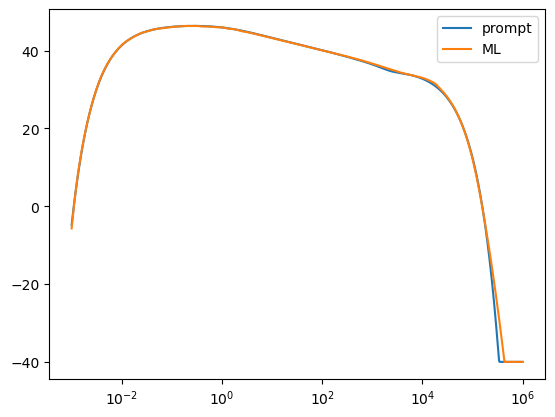

In [74]:
from prompt_progenitor import Prompt
import numpy as np
import matplotlib.pyplot as plt

prompt = Prompt(
    components=("jet",),            # just jet for now
    sample_gw_parameters=False,     # we will pass theta_los
    gw_param_mode="mass",           # so _extract_masses expects mass_1/mass_2
    j_struct="tophat",            # or 1/2/3
    eta_jet=1e-4,
    frac=0.1,
    phi_los_deg=0.0,
    default_theta_los_deg=0.0,
)

prompt.check_print()

params = {
    # jet knobs

    # viewing angle
    "theta_los": 20.0,         # degrees

    # binary / EOS inputs used in _derive_Eiso_jet
    "mass_1": 1.8,             # Msun
    "mass_2": 1.4,             # Msun
    "lambda_2": 300.0,         # dimensionless tidal deformability
}

import sys
print("CELL START")
sys.stdout.flush()

out = prompt.update_model(params, dry_run=False)

print("CELL END", out)
sys.stdout.flush()

def interp_logt(t_new, t, y, left=0.0, right=0.0):
    # assumes t increasing
    return np.interp(t_new, t, y, left=left, right=right)

t_grid = np.logspace(-3, 6, 1000).astype(np.float32)

y_interp = interp_logt(t_grid, prompt.t, prompt.total_X, left=0.0, right=0.0)

# plt.plot(t_grid, np.log10(prompt.total_X+1e-40))
plt.plot(t_grid, np.log10(y_interp+1e-40), label='prompt')
plt.plot(t_grid, np.float64(y[0]), label='ML')

plt.xscale('log')
# plt.yscale('log')
plt.legend()
plt.show()

Object OK!
CELL START
Updating model...
eisojet val 1.1403765767974741e+49
Jet Constructed Successfully...
CELL END None


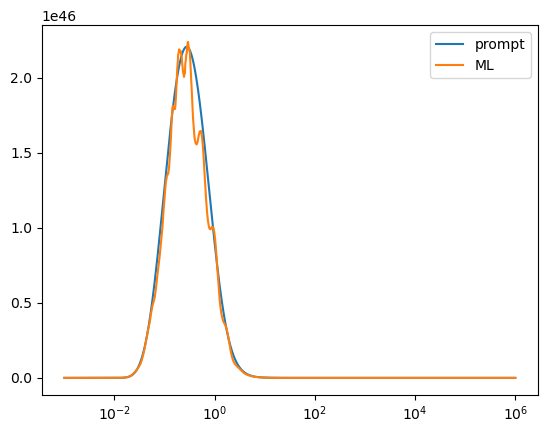

In [75]:
from prompt_progenitor import Prompt
import numpy as np
import matplotlib.pyplot as plt

prompt = Prompt(
    components=("jet",),            # just jet for now
    sample_gw_parameters=False,     # we will pass theta_los
    gw_param_mode="mass",           # so _extract_masses expects mass_1/mass_2
    j_struct="tophat",            # or 1/2/3
    eta_jet=1e-4,
    frac=0.1,
    phi_los_deg=0.0,
    default_theta_los_deg=0.0,
)

prompt.check_print()

params = {
    # jet knobs

    # viewing angle
    "theta_los": 20.0,         # degrees

    # binary / EOS inputs used in _derive_Eiso_jet
    "mass_1": 1.8,             # Msun
    "mass_2": 1.4,             # Msun
    "lambda_2": 300.0,         # dimensionless tidal deformability
}

import sys
print("CELL START")
sys.stdout.flush()

out = prompt.update_model(params, dry_run=False)

print("CELL END", out)
sys.stdout.flush()

def interp_logt(t_new, t, y, left=0.0, right=0.0):
    # assumes t increasing
    return np.interp(t_new, t, y, left=left, right=right)

t_grid = np.logspace(-3, 6, 1000).astype(np.float32)

y_interp = interp_logt(t_grid, prompt.t, prompt.total_X, left=0.0, right=0.0)

# plt.plot(t_grid, np.log10(prompt.total_X+1e-40))
plt.plot(t_grid, (y_interp+1e-40), label='prompt')
plt.plot(t_grid, 10**np.float64(y[0]), label='ML')
# plt.xlim(1e4, 1e6)

plt.xscale('log')
# plt.yscale('log')
plt.legend()
plt.show()

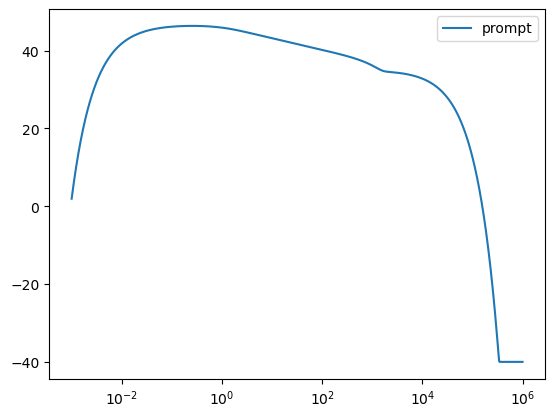

In [82]:
# plt.plot(t_grid, np.log10(prompt.total_X+1e-40))
plt.plot(t_grid, np.log10(y_interp+1e-40), label='prompt')
# plt.plot(t_grid, np.float64(y[0]), label='ML')

plt.xscale('log')
# plt.yscale('log')
plt.legend()
plt.show()

In [76]:
diagnostic = y[0] - np.log10(y_interp+1e-40)

In [70]:
tfive = np.zeros(len(t_grid))
tfivem = np.zeros(len(t_grid))
for i in range(len(tfive)):
    tfive[i] = 0.25
    tfivem[i] = -0.25

(0.01, 100.0)

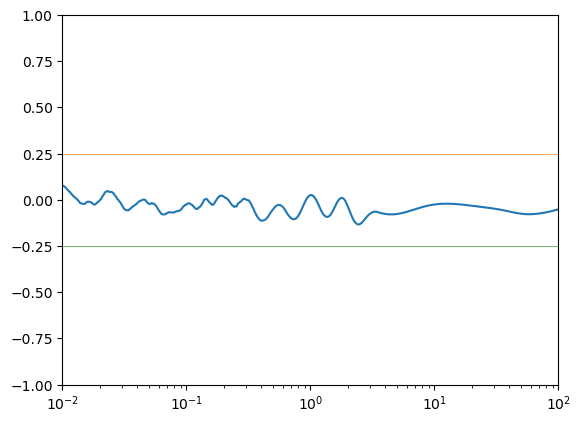

In [77]:
plt.plot(t_grid, diagnostic)
plt.plot(t_grid, tfive, lw=0.5)
plt.plot(t_grid, tfivem, lw=0.5)
plt.xscale('log')
plt.ylim(-1,1)
plt.xlim(1e-2,1e2)

(-1.0, 1.0)

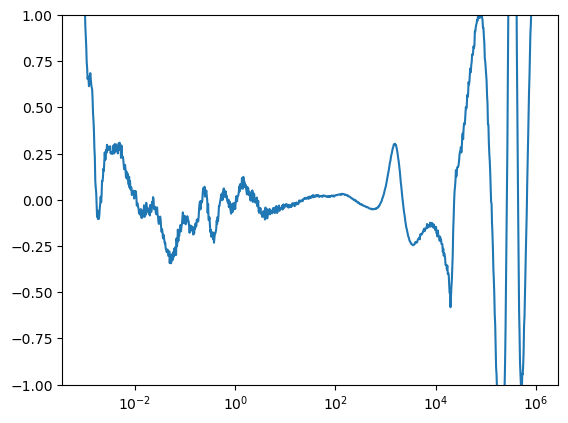

In [60]:
plt.plot(t_grid, diagnostic)

plt.xscale('log')
plt.ylim(-1,1)

In [17]:
# predict_lightcurve.py
import numpy as np
import torch
import torch.nn as nn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_PATH = "lightcurve_mlp_maxmin.pt"

class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.net(x))

class LightCurveMLP(nn.Module):
    def __init__(self, in_dim=4, out_dim=1000, hidden=512, depth=4, dropout=0.05):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.GELU()]
        for _ in range(depth):
            layers.append(ResidualBlock(hidden, dropout=dropout))
        layers += [nn.Dropout(dropout), nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def load_model(model_path=MODEL_PATH):
    ckpt = torch.load(model_path, map_location=DEVICE)

    out_dim = ckpt["y_mean"].shape[1]
    hidden = ckpt["config"]["hidden"]
    depth = ckpt["config"]["depth"]
    dropout = ckpt["config"]["dropout"]

    model = LightCurveMLP(
        in_dim=4,
        out_dim=out_dim,
        hidden=hidden,
        depth=depth,
        dropout=dropout,
    ).to(DEVICE)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    return model, ckpt

def predict(params_4):
    model, ckpt = load_model()

    x = torch.tensor(params_4, dtype=torch.float32, device=DEVICE)
    if x.ndim == 1:
        x = x.unsqueeze(0)
    assert x.shape[1] == 4, f"Expected shape (N,4), got {tuple(x.shape)}"

    x_mean = ckpt["x_min"].to(DEVICE, dtype=torch.float64)
    x_std = ckpt["x_max"].to(DEVICE, dtype=torch.float64)
    y_mean = ckpt["y_mean"].to(DEVICE, dtype=torch.float64)
    y_std = ckpt["y_std"].to(DEVICE, dtype=torch.float64)
    t_grid = ckpt["t_grid"].detach().cpu().numpy()

    xn = (x - x_mean) / (x_std-x_mean)
    xn.type

    with torch.no_grad():
        yn_pred = model(xn)

    y_pred = (yn_pred * (y_std-y_mean) + y_mean).detach().cpu().numpy()
    
    # # enforce physical/log-data floor
    # floor_val = -40.0
    # if "y_floor" in ckpt and ckpt["y_floor"] is not None:
    #     yf = ckpt["y_floor"]
    #     if isinstance(yf, torch.Tensor):
    #         yf = yf.item()
    #     # if stored as linear floor like 1e-40, convert to log10
    #     floor_val = np.log10(yf) if yf > 0 and yf < 1 else float(yf)
    
    # y_pred = np.maximum(y_pred, floor_val)
    return t_grid, y_pred

if __name__ == "__main__":
    # Example
    example_params = [20 / 60.0, 1.8, 1.4, np.log10(300 + 1.0)]
    t, y = predict(example_params)
    print("t_grid shape:", t.shape)
    print("predicted curve shape:", y.shape)

t_grid shape: (1000,)
predicted curve shape: (1, 1000)


In [11]:
# predict_lightcurve.py
import numpy as np
import torch
import torch.nn as nn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_PATH = "lightcurve_mlp.pt"

class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.net(x))

class LightCurveMLP(nn.Module):
    def __init__(self, in_dim=4, out_dim=1000, hidden=512, depth=4, dropout=0.05):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.GELU()]
        for _ in range(depth):
            layers.append(ResidualBlock(hidden, dropout=dropout))
        layers += [nn.Dropout(dropout), nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def load_model(model_path=MODEL_PATH):
    ckpt = torch.load(model_path, map_location=DEVICE)

    out_dim = ckpt["y_mean"].shape[1]
    hidden = ckpt["config"]["hidden"]
    depth = ckpt["config"]["depth"]
    dropout = ckpt["config"]["dropout"]

    model = LightCurveMLP(
        in_dim=4,
        out_dim=out_dim,
        hidden=hidden,
        depth=depth,
        dropout=dropout,
    ).to(DEVICE)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    return model, ckpt

def predict(params_4):
    model, ckpt = load_model()

    x = torch.tensor(params_4, dtype=torch.float32, device=DEVICE)
    if x.ndim == 1:
        x = x.unsqueeze(0)
    assert x.shape[1] == 4, f"Expected shape (N,4), got {tuple(x.shape)}"

    x_mean = ckpt["x_mean"].to(DEVICE, dtype=torch.float32)
    x_std = ckpt["x_std"].to(DEVICE, dtype=torch.float32)
    y_mean = ckpt["y_mean"].to(DEVICE, dtype=torch.float32)
    y_std = ckpt["y_std"].to(DEVICE, dtype=torch.float32)
    t_grid = ckpt["t_grid"].detach().cpu().numpy()

    xn = (x - x_mean) / x_std

    with torch.no_grad():
        yn_pred = model(xn)

    y_pred = (yn_pred * y_std + y_mean).detach().cpu().numpy()
    
    # # enforce physical/log-data floor
    # floor_val = -40.0
    # if "y_floor" in ckpt and ckpt["y_floor"] is not None:
    #     yf = ckpt["y_floor"]
    #     if isinstance(yf, torch.Tensor):
    #         yf = yf.item()
    #     # if stored as linear floor like 1e-40, convert to log10
    #     floor_val = np.log10(yf) if yf > 0 and yf < 1 else float(yf)
    
    # y_pred = np.maximum(y_pred, floor_val)
    return t_grid, y_pred

if __name__ == "__main__":
    # Example
    example_params = [20 / 60.0, 1.8, 1.4, np.log10(300 + 1.0)]
    t, y = predict(example_params)
    print("t_grid shape:", t.shape)
    print("predicted curve shape:", y.shape)

RuntimeError: mat1 and mat2 must have the same dtype, but got Float and Double

In [75]:
# train_lightcurve_net.py
import os
import math
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

# -----------------------------
# Config
# -----------------------------
DATA_PATH = "prompt_bns_dataset_32k.npz"
BATCH_SIZE = 256
EPOCHS = 200
LR = 1e-3
WEIGHT_DECAY = 1e-5
VAL_FRAC = 0.1
TEST_FRAC = 0.1
HIDDEN = 512
DEPTH = 4
DROPOUT = 0.05
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_OUT = "lightcurve_mlp_maxmin.pt"

# -----------------------------
# Reproducibility
# -----------------------------
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# -----------------------------
# Dataset
# -----------------------------
class LightCurveDataset(Dataset):
    def __init__(self, npz_path):
        d = np.load(npz_path)
        self.X = d["X"].astype(np.float32)     # (N, 4)
        self.Y = d["Y"].astype(np.float32)     # (N, 1000)
        self.t_grid = d["t_grid"].astype(np.float32)
        self.y_floor = float(d["y_floor"]) if "y_floor" in d else None

        assert self.X.ndim == 2 and self.X.shape[1] == 4, f"Expected X shape (N,4), got {self.X.shape}"
        assert self.Y.ndim == 2, f"Expected Y shape (N,T), got {self.Y.shape}"
        assert self.X.shape[0] == self.Y.shape[0], "X and Y must have same number of samples"

        # Normalize inputs only
        self.x_max = self.X.max(axis=0, keepdims=True)
        self.x_min = self.X.min(axis=0, keepdims=True)
        self.Xn = (self.X - self.x_min) / (self.x_max - self.x_min)

        # Optionally normalize targets too. This often helps.
        self.y_mean = self.Y.mean(axis=0, keepdims=True)
        self.y_std = self.Y.std(axis=0, keepdims=True) + 1e-8
        self.Yn = (self.Y - self.y_mean) / self.y_std

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return (
            torch.from_numpy(self.Xn[idx]),
            torch.from_numpy(self.Yn[idx]),
        )

# -----------------------------
# Model
# -----------------------------
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.net(x))

class LightCurveMLP(nn.Module):
    def __init__(self, in_dim=4, out_dim=1000, hidden=512, depth=4, dropout=0.05):
        super().__init__()
        layers = [
            nn.Linear(in_dim, hidden),
            nn.GELU(),
        ]
        for _ in range(depth):
            layers.append(ResidualBlock(hidden, dropout=dropout))
        layers += [
            nn.Dropout(dropout),
            nn.Linear(hidden, out_dim),
        ]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# -----------------------------
# Training / Eval
# -----------------------------
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    n = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            pred = model(xb)
            loss = criterion(pred, yb)
            total_loss += loss.item() * xb.size(0)
            n += xb.size(0)
    return total_loss / n

def train():
    ds = LightCurveDataset(DATA_PATH)

    n_total = len(ds)
    n_test = int(TEST_FRAC * n_total)
    n_val = int(VAL_FRAC * n_total)
    n_train = n_total - n_val - n_test

    train_ds, val_ds, test_ds = random_split(
        ds,
        [n_train, n_val, n_test],
        generator=torch.Generator().manual_seed(SEED)
    )

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = LightCurveMLP(
        in_dim=4,
        out_dim=ds.Y.shape[1],
        hidden=HIDDEN,
        depth=DEPTH,
        dropout=DROPOUT,
    ).to(DEVICE)

    # Huber loss is often more stable than pure MSE for curve regression
    criterion = nn.SmoothL1Loss(beta=0.5)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=10
    )

    best_val = float("inf")
    best_state = None
    patience = 25
    bad_epochs = 0

    print(f"Device: {DEVICE}")
    print(f"Train/Val/Test = {n_train}/{n_val}/{n_test}")
    print(f"Input dim = 4, Output dim = {ds.Y.shape[1]}")

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_train = 0.0
        n = 0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_train += loss.item() * xb.size(0)
            n += xb.size(0)

        train_loss = total_train / n
        val_loss = evaluate(model, val_loader, criterion)
        scheduler.step(val_loss)

        lr_now = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch:03d} | train {train_loss:.6f} | val {val_loss:.6f} | lr {lr_now:.2e}")

        if val_loss < best_val:
            best_val = val_loss
            bad_epochs = 0
            best_state = {
                "model_state": model.state_dict(),
                "x_min": torch.tensor(ds.x_min, dtype=torch.float32),
                "x_max": torch.tensor(ds.x_max, dtype=torch.float32),
                "y_mean": torch.tensor(ds.y_mean, dtype=torch.float32),
                "y_std": torch.tensor(ds.y_std, dtype=torch.float32),
                "t_grid": torch.tensor(ds.t_grid, dtype=torch.float32),
                "y_floor": ds.y_floor,
                "config": {
                    "hidden": HIDDEN,
                    "depth": DEPTH,
                    "dropout": DROPOUT,
                    "batch_size": BATCH_SIZE,
                    "lr": LR,
                    "weight_decay": WEIGHT_DECAY,
                },
            }
            torch.save(best_state, MODEL_OUT)
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            print("Early stopping.")
            break

    print(f"Best val loss: {best_val:.6f}")
    print(f"Saved model to: {MODEL_OUT}")

    # Final test evaluation
    ckpt = torch.load(MODEL_OUT, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state"])
    test_loss = evaluate(model, test_loader, criterion)
    print(f"Test loss: {test_loss:.6f}")

if __name__ == "__main__":
    train()

Device: cpu
Train/Val/Test = 25600/3200/3200
Input dim = 4, Output dim = 1000
Epoch 001 | train 0.168746 | val 0.031654 | lr 1.00e-03
Epoch 002 | train 0.030438 | val 0.017070 | lr 1.00e-03
Epoch 003 | train 0.019866 | val 0.011318 | lr 1.00e-03
Epoch 004 | train 0.016431 | val 0.009618 | lr 1.00e-03
Epoch 005 | train 0.013396 | val 0.010081 | lr 1.00e-03
Epoch 006 | train 0.011773 | val 0.015562 | lr 1.00e-03
Epoch 007 | train 0.012130 | val 0.005840 | lr 1.00e-03
Epoch 008 | train 0.009137 | val 0.005131 | lr 1.00e-03
Epoch 009 | train 0.009954 | val 0.011010 | lr 1.00e-03
Epoch 010 | train 0.007763 | val 0.004805 | lr 1.00e-03
Epoch 011 | train 0.007560 | val 0.007491 | lr 1.00e-03
Epoch 012 | train 0.008980 | val 0.017535 | lr 1.00e-03
Epoch 013 | train 0.009538 | val 0.005424 | lr 1.00e-03
Epoch 014 | train 0.010719 | val 0.004860 | lr 1.00e-03
Epoch 015 | train 0.005370 | val 0.003800 | lr 1.00e-03
Epoch 016 | train 0.004815 | val 0.005822 | lr 1.00e-03
Epoch 017 | train 0.006797

In [104]:
# train_lightcurve_net_v2.py
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# Config
# -----------------------------
DATA_PATH = "prompt_bns_dataset_32k.npz"
BATCH_SIZE = 256
EPOCHS = 200
LR = 1e-3
WEIGHT_DECAY = 1e-5
VAL_FRAC = 0.1
TEST_FRAC = 0.1
HIDDEN = 512
DEPTH = 8
DROPOUT = 0.05
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_OUT = "lightcurve_mlp_v4.pt"

torch.set_default_dtype(torch.float64)

# -----------------------------
# Reproducibility
# -----------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# -----------------------------
# Featurization
# -----------------------------
def featurize_physical(theta_los, mass_1, mass_2, lambda_2):
    m1, m2 = mass_1, mass_2
    if m2 > m1:
        m1, m2 = m2, m1
    return np.array(
        [
            theta_los / 60.0,
            m1,
            m2,
            np.log10(lambda_2 + 1.0),
        ],
        dtype=np.float64,
    )

# -----------------------------
# Dataset wrapper
# -----------------------------
class LightCurveDataset(Dataset):
    def __init__(self, Xn, Yn):
        self.Xn = torch.from_numpy(Xn).to(torch.float64)
        self.Yn = torch.from_numpy(Yn).to(torch.float64)

    def __len__(self):
        return self.Xn.shape[0]

    def __getitem__(self, idx):
        return self.Xn[idx], self.Yn[idx]

# -----------------------------
# Model
# -----------------------------
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.net(x))

class LightCurveMLP(nn.Module):
    def __init__(self, in_dim=4, out_dim=1000, hidden=512, depth=8, dropout=0.05):
        super().__init__()
        layers = [
            nn.Linear(in_dim, hidden),
            nn.GELU(),
        ]
        for _ in range(depth):
            layers.append(ResidualBlock(hidden, dropout=dropout))
        layers += [
            nn.Dropout(dropout),
            nn.Linear(hidden, out_dim),
        ]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# -----------------------------
# Loss
# -----------------------------
def hybrid_loss(
    pred,
    target,
    y_mean_t,
    y_std_t,
    floor_log=-40.0,
    margin=0.5,
    beta=0.5,
    bright_weight=3.0,
):
    pred_log = pred * y_std_t + y_mean_t
    true_log = target * y_std_t + y_mean_t

    mask = true_log > (floor_log + margin)

    # base SmoothL1 in normalized space
    diff = pred - target
    abs_diff = torch.abs(diff)
    huber = torch.where(
        abs_diff < beta,
        0.5 * diff * diff / beta,
        abs_diff - 0.5 * beta,
    )

    if mask.sum() == 0:
        return huber.mean()

    # brighter points get more weight, but everything stays in log space
    bright = torch.clamp(true_log - (floor_log + margin), min=0.0)
    weights = 1.0 + bright_weight * bright / bright.mean().clamp_min(1e-12)

    return (huber[mask] * weights[mask]).mean()

# -----------------------------
# Helpers
# -----------------------------
def peak_metrics_batch(pred_denorm, target_denorm):
    pred_peak = pred_denorm.max(dim=1).values
    true_peak = target_denorm.max(dim=1).values

    peak_log_err = pred_peak - true_peak
    peak_mae_log = torch.abs(peak_log_err).mean().item()
    peak_factor = torch.pow(10.0, torch.abs(peak_log_err)).mean().item()

    return peak_mae_log, peak_factor

def make_splits(N, val_frac=0.1, test_frac=0.1, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(N)
    rng.shuffle(idx)

    n_test = int(test_frac * N)
    n_val = int(val_frac * N)
    n_train = N - n_val - n_test

    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train + n_val]
    test_idx = idx[n_train + n_val:]
    return train_idx, val_idx, test_idx

def normalize_X_minmax(X, x_min, x_scale):
    return (X - x_min) / x_scale

def normalize_Y_zscore(Y, y_mean, y_std):
    return (Y - y_mean) / y_std

def denormalize_Y_zscore(Yn, y_mean, y_std):
    return Yn * y_std + y_mean

def evaluate(model, loader, y_mean_t, y_std_t, floor_log):
    model.eval()
    total_loss = 0.0
    total_mae_log = 0.0
    n = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            pred = model(xb)

            yb_denorm = yb * y_std_t + y_mean_t
            loss = hybrid_loss(
                    pred,
                    yb,
                    y_mean_t,
                    y_std_t,
                    floor_log=floor_log)

            pred_denorm = pred * y_std_t + y_mean_t
            peak_mae_log, peak_factor = peak_metrics_batch(pred_denorm, yb_denorm)
            mask = yb_denorm > (floor_log + 0.5)
            if mask.sum() > 0:
                mae_log = torch.abs(pred_denorm - yb_denorm)[mask].mean()
            else:
                mae_log = torch.abs(pred_denorm - yb_denorm).mean()

            bs = xb.size(0)
            total_loss += loss.item() * bs
            total_mae_log += mae_log.item() * bs
            n += bs

    return total_loss / n, total_mae_log / n

# -----------------------------
# Train
# -----------------------------
def train():
    d = np.load(DATA_PATH)
    X = d["X"].astype(np.float64)      # already featurized in your dataset
    Y = d["Y"].astype(np.float64)      # log10 target
    t_grid = d["t_grid"].astype(np.float64)
    y_floor = float(d["y_floor"]) if "y_floor" in d else 1e-40

    assert X.ndim == 2 and X.shape[1] == 4, f"Expected X shape (N,4), got {X.shape}"
    assert Y.ndim == 2 and X.shape[0] == Y.shape[0], f"Bad Y shape {Y.shape}"

    N = X.shape[0]
    train_idx, val_idx, test_idx = make_splits(N, VAL_FRAC, TEST_FRAC, SEED)

    X_train_raw = X[train_idx]
    Y_train_raw = Y[train_idx]

    # X: min-max from TRAIN ONLY
    x_min = X_train_raw.min(axis=0, keepdims=True)
    x_max = X_train_raw.max(axis=0, keepdims=True)
    x_scale = np.maximum(x_max - x_min, 1e-12)

    # Y: z-score from TRAIN ONLY
    y_mean = Y_train_raw.mean(axis=0, keepdims=True)
    y_std = Y_train_raw.std(axis=0, keepdims=True)
    y_std = np.maximum(y_std, 1e-12)

    # Normalize all splits using TRAIN stats
    X_train = normalize_X_minmax(X[train_idx], x_min, x_scale)
    X_val   = normalize_X_minmax(X[val_idx],   x_min, x_scale)
    X_test  = normalize_X_minmax(X[test_idx],  x_min, x_scale)

    Y_train = normalize_Y_zscore(Y[train_idx], y_mean, y_std)
    Y_val   = normalize_Y_zscore(Y[val_idx],   y_mean, y_std)
    Y_test  = normalize_Y_zscore(Y[test_idx],  y_mean, y_std)

    train_ds = LightCurveDataset(X_train, Y_train)
    val_ds   = LightCurveDataset(X_val, Y_val)
    test_ds  = LightCurveDataset(X_test, Y_test)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = LightCurveMLP(
        in_dim=4,
        out_dim=Y.shape[1],
        hidden=HIDDEN,
        depth=DEPTH,
        dropout=DROPOUT,
    ).to(DEVICE).double()

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=10
    )

    y_mean_t = torch.tensor(y_mean, dtype=torch.float64, device=DEVICE)
    y_std_t  = torch.tensor(y_std,  dtype=torch.float64, device=DEVICE)
    floor_log = np.log10(y_floor)

    best_val = float("inf")
    patience = 25
    bad_epochs = 0

    print(f"Device: {DEVICE}")
    print(f"Train/Val/Test = {len(train_ds)}/{len(val_ds)}/{len(test_ds)}")
    print(f"Input dim = 4, Output dim = {Y.shape[1]}")
    print("X train min:", x_min)
    print("X train max:", x_max)

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_train = 0.0
        n = 0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            pred = model(xb)

            yb_denorm = yb * y_std_t + y_mean_t
            loss = hybrid_loss(
                    pred,
                    yb,
                    y_mean_t,
                    y_std_t,
                    floor_log=floor_log)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_train += loss.item() * xb.size(0)
            n += xb.size(0)

        train_loss = total_train / n
        val_loss, val_mae_log = evaluate(model, val_loader, y_mean_t, y_std_t, floor_log)
        scheduler.step(val_loss)

        lr_now = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch:03d} | "
            f"train {train_loss:.6f} | "
            f"val {val_loss:.6f} | "
            f"val_mae_log {val_mae_log:.6f} | "
            f"lr {lr_now:.2e}"
        )

        if val_loss < best_val:
            best_val = val_loss
            bad_epochs = 0

            best_state = {
                "model_state": model.state_dict(),
                "x_min": torch.tensor(x_min, dtype=torch.float64),
                "x_scale": torch.tensor(x_scale, dtype=torch.float64),
                "y_mean": torch.tensor(y_mean, dtype=torch.float64),
                "y_std": torch.tensor(y_std, dtype=torch.float64),
                "t_grid": torch.tensor(t_grid, dtype=torch.float64),
                "y_floor": y_floor,
                "config": {
                    "hidden": HIDDEN,
                    "depth": DEPTH,
                    "dropout": DROPOUT,
                    "batch_size": BATCH_SIZE,
                    "lr": LR,
                    "weight_decay": WEIGHT_DECAY,
                },
            }
            torch.save(best_state, MODEL_OUT)
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            print("Early stopping.")
            break

    print(f"Best val loss: {best_val:.6f}")
    print(f"Saved model to: {MODEL_OUT}")

    ckpt = torch.load(MODEL_OUT, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    test_loss, test_mae_log = evaluate(model, test_loader, y_mean_t, y_std_t, floor_log)
    print(f"Test loss: {test_loss:.6f}")
    print(f"Test MAE(log10): {test_mae_log:.6f}")

if __name__ == "__main__":
    train()

Device: cpu
Train/Val/Test = 25600/3200/3200
Input dim = 4, Output dim = 1000
X train min: [[2.58437649e-05 1.01194203e+00 1.00001585e+00 2.00445127e+00]]
X train max: [[0.99998248 2.19999266 2.19487953 3.30123758]]
Epoch 001 | train 0.549740 | val 0.198860 | val_mae_log 2.268096 | lr 1.00e-03
Epoch 002 | train 0.101394 | val 0.054255 | val_mae_log 1.047094 | lr 1.00e-03
Epoch 003 | train 0.055591 | val 0.034613 | val_mae_log 0.969277 | lr 1.00e-03
Epoch 004 | train 0.043318 | val 0.037988 | val_mae_log 0.900842 | lr 1.00e-03
Epoch 005 | train 0.046051 | val 0.026985 | val_mae_log 0.758155 | lr 1.00e-03
Epoch 006 | train 0.027880 | val 0.012185 | val_mae_log 0.532925 | lr 1.00e-03
Epoch 007 | train 0.034478 | val 0.018526 | val_mae_log 0.557529 | lr 1.00e-03
Epoch 008 | train 0.027319 | val 0.017595 | val_mae_log 0.506185 | lr 1.00e-03
Epoch 009 | train 0.023772 | val 0.016174 | val_mae_log 0.655041 | lr 1.00e-03
Epoch 010 | train 0.026349 | val 0.015502 | val_mae_log 0.564967 | lr 1.0

In [95]:
# train_lightcurve_net_v2.py
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# Config
# -----------------------------
DATA_PATH = "prompt_bns_dataset_32k.npz"
BATCH_SIZE = 256
EPOCHS = 200
LR = 1e-3
WEIGHT_DECAY = 1e-5
VAL_FRAC = 0.1
TEST_FRAC = 0.1
HIDDEN = 512
DEPTH = 8
DROPOUT = 0.05
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_OUT = "lightcurve_mlp_v3.pt"

torch.set_default_dtype(torch.float64)

# -----------------------------
# Reproducibility
# -----------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# -----------------------------
# Featurization
# -----------------------------
def featurize_physical(theta_los, mass_1, mass_2, lambda_2):
    m1, m2 = mass_1, mass_2
    if m2 > m1:
        m1, m2 = m2, m1
    return np.array(
        [
            theta_los / 60.0,
            m1,
            m2,
            np.log10(lambda_2 + 1.0),
        ],
        dtype=np.float64,
    )

# -----------------------------
# Dataset wrapper
# -----------------------------
class LightCurveDataset(Dataset):
    def __init__(self, Xn, Yn):
        self.Xn = torch.from_numpy(Xn).to(torch.float64)
        self.Yn = torch.from_numpy(Yn).to(torch.float64)

    def __len__(self):
        return self.Xn.shape[0]

    def __getitem__(self, idx):
        return self.Xn[idx], self.Yn[idx]

# -----------------------------
# Model
# -----------------------------
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.net(x))

class LightCurveMLP(nn.Module):
    def __init__(self, in_dim=4, out_dim=1000, hidden=512, depth=16, dropout=0.05):
        super().__init__()
        layers = [
            nn.Linear(in_dim, hidden),
            nn.GELU(),
        ]
        for _ in range(depth):
            layers.append(ResidualBlock(hidden, dropout=dropout))
        layers += [
            nn.Dropout(dropout),
            nn.Linear(hidden, out_dim),
        ]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# -----------------------------
# Loss
# -----------------------------
def weighted_masked_smooth_l1_loss(
    pred,
    target,
    target_denorm,
    floor_log=-40.0,
    margin=0.5,
    beta=0.5,
    alpha=2.0,
):
    mask = target_denorm > (floor_log + margin)

    diff = pred - target
    abs_diff = torch.abs(diff)
    huber = torch.where(
        abs_diff < beta,
        0.5 * diff * diff / beta,
        abs_diff - 0.5 * beta,
    )

    if mask.sum() == 0:
        return huber.mean()

    # brighter bins get larger weight
    bright = torch.clamp(target_denorm - (floor_log + margin), min=0.0)
    weights = 1.0 + alpha * bright / bright.mean().clamp_min(1e-12)

    return (huber[mask] * weights[mask]).mean()

# -----------------------------
# Helpers
# -----------------------------
def make_splits(N, val_frac=0.1, test_frac=0.1, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(N)
    rng.shuffle(idx)

    n_test = int(test_frac * N)
    n_val = int(val_frac * N)
    n_train = N - n_val - n_test

    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train + n_val]
    test_idx = idx[n_train + n_val:]
    return train_idx, val_idx, test_idx

def normalize_X_minmax(X, x_min, x_scale):
    return (X - x_min) / x_scale

def normalize_Y_zscore(Y, y_mean, y_std):
    return (Y - y_mean) / y_std

def denormalize_Y_zscore(Yn, y_mean, y_std):
    return Yn * y_std + y_mean

def evaluate(model, loader, y_mean_t, y_std_t, floor_log):
    model.eval()
    total_loss = 0.0
    total_mae_log = 0.0
    n = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            pred = model(xb)

            yb_denorm = yb * y_std_t + y_mean_t
            loss = weighted_masked_smooth_l1_loss(pred, yb, yb_denorm, floor_log=floor_log)

            pred_denorm = pred * y_std_t + y_mean_t
            mask = yb_denorm > (floor_log + 0.5)
            if mask.sum() > 0:
                mae_log = torch.abs(pred_denorm - yb_denorm)[mask].mean()
            else:
                mae_log = torch.abs(pred_denorm - yb_denorm).mean()

            bs = xb.size(0)
            total_loss += loss.item() * bs
            total_mae_log += mae_log.item() * bs
            n += bs

    return total_loss / n, total_mae_log / n

# -----------------------------
# Train
# -----------------------------
def train():
    d = np.load(DATA_PATH)
    X = d["X"].astype(np.float64)      # already featurized in your dataset
    Y = d["Y"].astype(np.float64)      # log10 target
    t_grid = d["t_grid"].astype(np.float64)
    y_floor = float(d["y_floor"]) if "y_floor" in d else 1e-40

    assert X.ndim == 2 and X.shape[1] == 4, f"Expected X shape (N,4), got {X.shape}"
    assert Y.ndim == 2 and X.shape[0] == Y.shape[0], f"Bad Y shape {Y.shape}"

    N = X.shape[0]
    train_idx, val_idx, test_idx = make_splits(N, VAL_FRAC, TEST_FRAC, SEED)

    X_train_raw = X[train_idx]
    Y_train_raw = Y[train_idx]

    # X: min-max from TRAIN ONLY
    x_min = X_train_raw.min(axis=0, keepdims=True)
    x_max = X_train_raw.max(axis=0, keepdims=True)
    x_scale = np.maximum(x_max - x_min, 1e-12)

    # Y: z-score from TRAIN ONLY
    y_mean = Y_train_raw.mean(axis=0, keepdims=True)
    y_std = Y_train_raw.std(axis=0, keepdims=True)
    y_std = np.maximum(y_std, 1e-12)

    # Normalize all splits using TRAIN stats
    X_train = normalize_X_minmax(X[train_idx], x_min, x_scale)
    X_val   = normalize_X_minmax(X[val_idx],   x_min, x_scale)
    X_test  = normalize_X_minmax(X[test_idx],  x_min, x_scale)

    Y_train = normalize_Y_zscore(Y[train_idx], y_mean, y_std)
    Y_val   = normalize_Y_zscore(Y[val_idx],   y_mean, y_std)
    Y_test  = normalize_Y_zscore(Y[test_idx],  y_mean, y_std)

    train_ds = LightCurveDataset(X_train, Y_train)
    val_ds   = LightCurveDataset(X_val, Y_val)
    test_ds  = LightCurveDataset(X_test, Y_test)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = LightCurveMLP(
        in_dim=4,
        out_dim=Y.shape[1],
        hidden=HIDDEN,
        depth=DEPTH,
        dropout=DROPOUT,
    ).to(DEVICE).double()

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=10
    )

    y_mean_t = torch.tensor(y_mean, dtype=torch.float64, device=DEVICE)
    y_std_t  = torch.tensor(y_std,  dtype=torch.float64, device=DEVICE)
    floor_log = np.log10(y_floor)

    best_val = float("inf")
    patience = 25
    bad_epochs = 0

    print(f"Device: {DEVICE}")
    print(f"Train/Val/Test = {len(train_ds)}/{len(val_ds)}/{len(test_ds)}")
    print(f"Input dim = 4, Output dim = {Y.shape[1]}")
    print("X train min:", x_min)
    print("X train max:", x_max)

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_train = 0.0
        n = 0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            pred = model(xb)

            yb_denorm = yb * y_std_t + y_mean_t
            loss = weighted_masked_smooth_l1_loss(pred, yb, yb_denorm, floor_log=floor_log)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_train += loss.item() * xb.size(0)
            n += xb.size(0)

        train_loss = total_train / n
        val_loss, val_mae_log = evaluate(model, val_loader, y_mean_t, y_std_t, floor_log)
        scheduler.step(val_loss)

        lr_now = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch:03d} | "
            f"train {train_loss:.6f} | "
            f"val {val_loss:.6f} | "
            f"val_mae_log {val_mae_log:.6f} | "
            f"lr {lr_now:.2e}"
        )

        if val_loss < best_val:
            best_val = val_loss
            bad_epochs = 0

            best_state = {
                "model_state": model.state_dict(),
                "x_min": torch.tensor(x_min, dtype=torch.float64),
                "x_scale": torch.tensor(x_scale, dtype=torch.float64),
                "y_mean": torch.tensor(y_mean, dtype=torch.float64),
                "y_std": torch.tensor(y_std, dtype=torch.float64),
                "t_grid": torch.tensor(t_grid, dtype=torch.float64),
                "y_floor": y_floor,
                "config": {
                    "hidden": HIDDEN,
                    "depth": DEPTH,
                    "dropout": DROPOUT,
                    "batch_size": BATCH_SIZE,
                    "lr": LR,
                    "weight_decay": WEIGHT_DECAY,
                },
            }
            torch.save(best_state, MODEL_OUT)
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            print("Early stopping.")
            break

    print(f"Best val loss: {best_val:.6f}")
    print(f"Saved model to: {MODEL_OUT}")

    ckpt = torch.load(MODEL_OUT, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    test_loss, test_mae_log = evaluate(model, test_loader, y_mean_t, y_std_t, floor_log)
    print(f"Test loss: {test_loss:.6f}")
    print(f"Test MAE(log10): {test_mae_log:.6f}")

if __name__ == "__main__":
    train()

Device: cpu
Train/Val/Test = 25600/3200/3200
Input dim = 4, Output dim = 1000
X train min: [[2.58437649e-05 1.01194203e+00 1.00001585e+00 2.00445127e+00]]
X train max: [[0.99998248 2.19999266 2.19487953 3.30123758]]
Epoch 001 | train 0.390434 | val 0.085196 | val_mae_log 1.762166 | lr 1.00e-03
Epoch 002 | train 0.072598 | val 0.036600 | val_mae_log 1.110490 | lr 1.00e-03
Epoch 003 | train 0.035506 | val 0.024166 | val_mae_log 0.855687 | lr 1.00e-03
Epoch 004 | train 0.031111 | val 0.029690 | val_mae_log 0.732779 | lr 1.00e-03
Epoch 005 | train 0.033175 | val 0.012060 | val_mae_log 0.585958 | lr 1.00e-03
Epoch 006 | train 0.024250 | val 0.016621 | val_mae_log 0.593911 | lr 1.00e-03
Epoch 007 | train 0.020760 | val 0.007312 | val_mae_log 0.448390 | lr 1.00e-03
Epoch 008 | train 0.021977 | val 0.024018 | val_mae_log 0.607777 | lr 1.00e-03
Epoch 009 | train 0.021900 | val 0.007548 | val_mae_log 0.425225 | lr 1.00e-03
Epoch 010 | train 0.020173 | val 0.010582 | val_mae_log 0.514783 | lr 1.0

In [33]:
# predict_lightcurve_v2.py
import numpy as np
import torch
import torch.nn as nn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_PATH = "lightcurve_mlp_v3.pt"

torch.set_default_dtype(torch.float64)

class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.net(x))

class LightCurveMLP(nn.Module):
    def __init__(self, in_dim=4, out_dim=1000, hidden=512, depth=8, dropout=0.05):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.GELU()]
        for _ in range(depth):
            layers.append(ResidualBlock(hidden, dropout=dropout))
        layers += [nn.Dropout(dropout), nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def featurize_physical(theta_los, mass_1, mass_2, lambda_2):
    m1, m2 = mass_1, mass_2
    if m2 > m1:
        m1, m2 = m2, m1
    return np.array(
        [
            theta_los / 60.0,
            m1,
            m2,
            np.log10(lambda_2 + 1.0),
        ],
        dtype=np.float64,
    )

def load_model(model_path=MODEL_PATH):
    ckpt = torch.load(model_path, map_location=DEVICE, weights_only=False)

    out_dim = ckpt["y_mean"].shape[1]
    hidden = ckpt["config"]["hidden"]
    depth = ckpt["config"]["depth"]
    dropout = ckpt["config"]["dropout"]

    model = LightCurveMLP(
        in_dim=4,
        out_dim=out_dim,
        hidden=hidden,
        depth=depth,
        dropout=dropout,
    ).to(DEVICE).double()

    model.load_state_dict(ckpt["model_state"])
    model.eval()
    return model, ckpt

def predict_from_features(x_feat):
    model, ckpt = load_model()

    x = torch.tensor(x_feat, dtype=torch.float64, device=DEVICE)
    if x.ndim == 1:
        x = x.unsqueeze(0)

    x_min   = ckpt["x_min"].to(DEVICE, dtype=torch.float64)
    x_scale = ckpt["x_scale"].to(DEVICE, dtype=torch.float64)
    y_mean  = ckpt["y_mean"].to(DEVICE, dtype=torch.float64)
    y_std   = ckpt["y_std"].to(DEVICE, dtype=torch.float64)
    t_grid  = ckpt["t_grid"].detach().cpu().numpy()

    xn = (x - x_min) / x_scale
    xn = torch.clamp(xn, 0.0, 1.0)

    with torch.no_grad():
        yn_pred = model(xn)
        y_pred = yn_pred * y_std + y_mean

        floor_log = np.log10(float(ckpt["y_floor"]))
        y_pred = torch.clamp(y_pred, min=floor_log)

    return t_grid, y_pred.detach().cpu().numpy()

def predict_physical(theta_los, mass_1, mass_2, lambda_2):
    x = featurize_physical(theta_los, mass_1, mass_2, lambda_2)
    return predict_from_features(x)

if __name__ == "__main__":
    t, y = predict_physical(
        theta_los=30.0,
        mass_1=1.8,
        mass_2=1.4,
        lambda_2=300.0,
    )
    print("t_grid shape:", t.shape)
    print("predicted curve shape:", y.shape)
    print("pred min/max:", y.min(), y.max())

t_grid shape: (1000,)
predicted curve shape: (1, 1000)
pred min/max: -40.0 46.3484907519369


In [4]:
import numpy as np

file1 = np.load("prompt_bns_dataset_30k.npz", allow_pickle=True)
file2 = np.load("prompt_bns_dataset_2k.npz", allow_pickle=True)

merged = {}

for key in file1.files:
    a = file1[key]
    b = file2[key]

    if key in ["X", "Y"]:
        merged[key] = np.concatenate([a, b], axis=0)

    elif key == "t_grid":
        if not np.array_equal(a, b):
            raise ValueError(f"{key} differs between files: {a.shape} vs {b.shape}")
        merged[key] = a

    elif key == "y_floor":
        if a.item() != b.item():
            raise ValueError(f"{key} differs between files: {a.item()} vs {b.item()}")
        merged[key] = a

    else:
        raise ValueError(f"Unexpected key: {key}")

np.savez("prompt_bns_dataset_32k.npz", **merged)

In [3]:
import numpy as np
from pathlib import Path

# from gemma.ejecta.physics.jet.prompt import Prompt

def interp_logt(t_new, t, y, left=0.0, right=0.0):
    # assumes t increasing
    return np.interp(t_new, t, y, left=left, right=right)

def sample_params(rng):
    m1 = rng.uniform(1.0, 2.2)
    m2 = rng.uniform(1.0, 2.2)
    if m2 > m1:
        m1, m2 = m2, m1

    return {
        "theta_los": rng.uniform(0.0, 60.0),
        "mass_1": m1,
        "mass_2": m2,
        "lambda_2": rng.uniform(100, (2000.0)),  # optional
        # "luminosity_distance": 10**rng.uniform(1.0, np.log10(500.0)),
    }

def featurize(p):
    # Convert dict -> feature vector in a consistent order
    # (Use the same ordering everywhere.)
    theta_los = p["theta_los"] / 60.0
    m1 = p["mass_1"]
    m2 = p["mass_2"]
    lam = np.log10(p["lambda_2"] + 1.0)
    return np.array([theta_los, m1, m2, lam], dtype=np.float32)

def main():
    rng = np.random.default_rng(2)

    # Fixed emulator time grid (choose something covering your regime)
    # You can also clip to what Prompt produces, but fixed is easiest.
    t_grid = np.logspace(-3, 6, 1000).astype(np.float32)  # 1s .. 1e6s

    # Wrapper
    prompt = Prompt(
        components=("jet",),
        sample_gw_parameters=False,
        gw_param_mode="mass",
        j_struct="tophat",
        use_disk_mass_mapping=True,
        output="luminosity",  # or "flux"
        default_theta_los_deg=0.0,
        # if flux:
        # default_distance_mpc=40.0,
        # sample_distance=False,
    )

    N = 2000  # start small; scale later
    X = np.zeros((N, 4), dtype=np.float32)
    Y = np.zeros((N, t_grid.size), dtype=np.float64)

    # floor for log transform (pick something tiny in your chosen units)
    y_floor = 1e-40

    n_ok = 0
    i = 0
    while n_ok < N:
        i += 1
        p = sample_params(rng)

        try:
            prompt.update_model(p, dry_run=False, verbose=False)
            if (not np.isfinite(prompt.mdisk)) or (prompt.mdisk <= 0.0):
                continue

            t_model = np.asarray(prompt.t, dtype=np.float32)
            y_model = np.asarray(prompt.total_X, dtype=np.float64)

            # interpolate onto fixed grid
            y_interp = interp_logt(t_grid, t_model, y_model, left=0.0, right=0.0)

            # log-transform target
            y_target = np.log10(y_interp + y_floor).astype(np.float64)

            X[n_ok] = featurize(p)
            Y[n_ok] = y_target
            n_ok += 1

            if n_ok % 50 == 0:
                print(f"Generated {n_ok}/{N} ok (attempts={i})")

        except Exception as e:
            print(f"Rejected on attempt {i}: {type(e).__name__}: {e}")
            continue

    out = Path("prompt_bns_dataset_2k.npz")
    np.savez(out, X=X, Y=Y, t_grid=t_grid, y_floor=y_floor)
    print("Saved:", out.resolve())

if __name__ == "__main__":
    main()

eisojet val 2.6766180048777525e+46
Jet Constructed Successfully...
eisojet val 3.506280145865356e+46
Jet Constructed Successfully...
eisojet val 1.7797446278516786e+50
Jet Constructed Successfully...
eisojet val 3.2054195797702866e+51
Jet Constructed Successfully...
eisojet val 5.168539442976822e+50
Jet Constructed Successfully...
eisojet val 3.635261682644319e+51
Jet Constructed Successfully...
eisojet val 3.213133966990151e+51
Jet Constructed Successfully...
eisojet val 3.245771586785792e+51
Jet Constructed Successfully...
eisojet val 2.2745523162925696e+51
Jet Constructed Successfully...
eisojet val 2.2379707406321352e+51
Jet Constructed Successfully...
eisojet val 2.813221547860783e+51
Jet Constructed Successfully...
eisojet val 5.803815034612792e+50
Jet Constructed Successfully...
eisojet val 1.5223715338301786e+51
Jet Constructed Successfully...
eisojet val 6.265108929338182e+51
Jet Constructed Successfully...
eisojet val 5.516391076624298e+50
Jet Constructed Successfully...
eiso

['X', 'Y', 't_grid', 'y_floor']


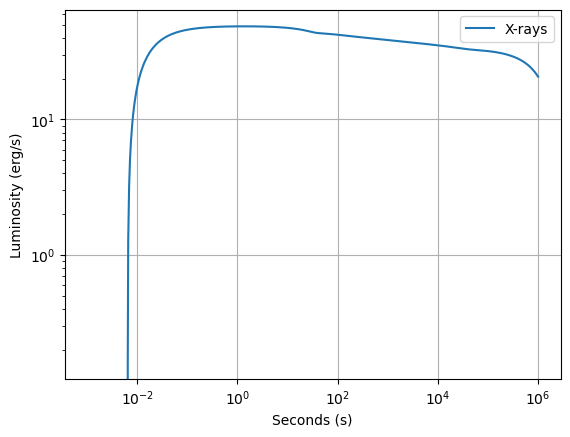

In [20]:
import numpy as np

data = np.load("prompt_bns_dataset_32k.npz")   # returns an NpzFile (dict-like)
print(data.files)            # list of array names (keys)

testx = data['t_grid']
testy = data['Y'][5]

import matplotlib.pyplot as plt

plt.plot(testx, testy, label = 'X-rays')
# plt.plot(prompt.t, prompt.total_gamma, label = 'Gamma-Rays')
# plt.ylim([1e36, 2e52])
plt.ylabel('Luminosity (erg/s)')
plt.xlabel('Seconds (s)')
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.legend()
plt.show()

In [21]:
testy

array([-40.        , -40.        , -40.        , -40.        ,
       -40.        , -40.        , -40.        , -40.        ,
       -40.        , -40.        , -40.        , -40.        ,
       -40.        , -40.        , -40.        , -40.        ,
       -40.        , -40.        , -40.        , -40.        ,
       -40.        , -40.        , -40.        , -40.        ,
       -40.        , -40.        , -40.        , -40.        ,
       -40.        , -40.        , -40.        , -40.        ,
       -40.        , -40.        , -40.        , -40.        ,
       -40.        , -40.        , -40.        , -40.        ,
       -40.        , -40.        , -40.        , -40.        ,
       -40.        , -40.        , -40.        , -40.        ,
       -40.        , -40.        , -40.        , -40.        ,
       -40.        , -40.        , -40.        , -40.        ,
       -40.        , -39.99999999, -39.9999994 , -39.99988398,
       -39.99575008, -39.59956167, -38.29970182, -36.21

In [4]:
# train_emulator_smooth64.py
import argparse
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# --------- Model ---------
class MLP(nn.Module):
    def __init__(self, n_in, n_out, width=512, depth=4, dropout=0.0):
        super().__init__()
        layers = []
        d = n_in
        for _ in range(depth):
            layers += [nn.Linear(d, width), nn.ReLU()]
            if dropout > 0:
                layers += [nn.Dropout(dropout)]
            d = width
        layers += [nn.Linear(d, n_out)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# --------- Smoothness penalties ---------
def smoothness_penalty(pred, kind="d2"):
    """
    pred: [B, T]
    kind:
      - "d1": penalize first differences (less strict)
      - "d2": penalize second differences (strong anti-wiggle)
      - "d1+d2": both
    """
    loss = pred.new_tensor(0.0)
    if "d1" in kind:
        d1 = pred[:, 1:] - pred[:, :-1]
        loss = loss + (d1 * d1).mean()
    if "d2" in kind:
        d2 = pred[:, 2:] - 2.0 * pred[:, 1:-1] + pred[:, :-2]
        loss = loss + (d2 * d2).mean()
    return loss

# --------- Utilities ---------
def to_linear_from_log10(Y_log10, y_floor):
    """
    Y_log10 is log10(y + y_floor). Convert back to y (linear).
    Uses exp(log(10)*x) and clips to avoid overflow in extreme cases.
    """
    # float64 safe-ish clip (exp(709) ~ 8e307 is near float64 max)
    # exp(log(10)*x) => log(10)*x <= 709 => x <= 709/log(10) ~ 307.65
    x = np.clip(Y_log10, -1e6, 307.0).astype(np.float64)
    y = np.exp(np.log(10.0) * x) - float(y_floor)
    return y.astype(np.float64)

def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--data", default="lc_20k_flux.npz")
    ap.add_argument("--out", default="promptx_emulator_smooth643.pt")
    ap.add_argument("--epochs", type=int, default=100)
    ap.add_argument("--batch", type=int, default=128)
    ap.add_argument("--lr", type=float, default=1e-3)
    ap.add_argument("--weight_decay", type=float, default=1e-6)
    ap.add_argument("--width", type=int, default=512)
    ap.add_argument("--depth", type=int, default=4)
    ap.add_argument("--dropout", type=float, default=0.0)
    ap.add_argument("--smooth_lambda", type=float, default=1e-3)   # main anti-wiggle knob
    ap.add_argument("--smooth_kind", default="d2", choices=["d1", "d2", "d1+d2"])
    ap.add_argument("--target", default="log10", choices=["log10", "linear"])
    ap.add_argument("--patience", type=int, default=15)
    ap.add_argument("--seed", type=int, default=42)
    ap.add_argument("--grad_clip", type=float, default=0.0)  # e.g. 1.0 if you want
    args, _unknown = ap.parse_known_args()

    # Force float64 everywhere (inputs, model, stats)
    torch.set_default_dtype(torch.float64)

    data = np.load(args.data)
    X = data["X"].astype(np.float64)
    Y = data["Y"].astype(np.float64)          # your dataset stores log10(y + floor)
    from scipy.signal import savgol_filter
    Y = savgol_filter(Y, window_length=31, polyorder=3, axis=1)
    t_grid = data["t_grid"].astype(np.float64)
    y_floor = 1e-90
    print(X.shape)

if __name__ == "__main__":
    main()


(20000, 8)


In [7]:
d2 = np.load("lc_20k_flux_6.npz")

X2 = d2["X"].astype(np.float64)

X2.shape

(20000, 7)

In [54]:
# train_emulator_better64.py
import argparse
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# ---------------- Model ----------------
class MLP(nn.Module):
    def __init__(self, n_in, n_out, width=512, depth=8, dropout=0.0):
        super().__init__()
        layers = []
        d = n_in
        for _ in range(depth):
            layers += [nn.Linear(d, width), nn.ReLU()]
            if dropout > 0:
                layers += [nn.Dropout(dropout)]
            d = width
        layers += [nn.Linear(d, n_out)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# ------------- Smoothness -------------
def smoothness_d2(y):
    # y: [B, T]  (in "physical" space: de-normalized log10 curve)
    d2 = y[:, 2:] - 2.0 * y[:, 1:-1] + y[:, :-2]
    return (d2 * d2).mean()

def smoothness_d2_weighted(y, w):
    # y: [B,T], w:[B,T]
    d2 = y[:, 2:] - 2.0*y[:, 1:-1] + y[:, :-2]
    # weight for d2 lives between points -> use center weights
    wc = w[:, 1:-1]
    return ((d2*d2) * wc).sum() / wc.sum().clamp_min(1e-12)


# ------------- Weighted MSE -------------
def weighted_mse(pred, target, weight, eps=1e-12):
    # pred/target/weight: [B, T]
    num = ((pred - target) ** 2 * weight).sum()
    den = weight.sum().clamp_min(eps)
    return num / den

# ---- log10 -> linear helpers (for relative-linear loss) ----
LOG10_T = None  # will be initialized on the right device inside main()

def log10_to_linear_torch(log10y, y_floor_t):
    # log10y = log10(y + floor)
    # clamp to avoid exp overflow in float64
    log10y = torch.clamp(log10y, -300.0, 120.0)  # tighten upper bound
    return torch.exp(LOG10_T * log10y) - y_floor_t


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--data", default="prompt_dataset_25kmerged.npz")
    ap.add_argument("--out", default="emulator.pt")
    ap.add_argument("--epochs", type=int, default=120)
    ap.add_argument("--batch", type=int, default=256)
    ap.add_argument("--lr", type=float, default=5e-4)
    ap.add_argument("--weight_decay", type=float, default=1e-6)
    ap.add_argument("--width", type=int, default=512)
    ap.add_argument("--depth", type=int, default=4)
    ap.add_argument("--dropout", type=float, default=0.0)

    # smoothing / masking knobs
    ap.add_argument("--smooth_lambda", type=float, default=5e-4)  # start ~1e-4..1e-3
    ap.add_argument("--mask_delta", type=float, default=1.0)      # ignore region within 1 dex of floor
    ap.add_argument("--mask_soft", type=float, default=0.25)      # softness of transition in dex

    ap.add_argument("--patience", type=int, default=10)
    ap.add_argument("--seed", type=int, default=42)
    ap.add_argument("--grad_clip", type=float, default=1.0)
    ap.add_argument("--savgol_window", type=int, default=31)
    ap.add_argument("--savgol_poly", type=int, default=3)
    args, _unknown = ap.parse_known_args()

    # float64 everywhere
    torch.set_default_dtype(torch.float64)

    d = np.load(args.data)

    X = d["X"].astype(np.float64)  # (N, 8) in your file
    X[:,1] = X[:,1]*90/60
    if "Y_lum_log" in d:
        Ylog = d["Y_lum_log"].astype(np.float64)  # (N, T)
        y_floor = float(d["y_floor"].item()) if "y_floor" in d else 1e-40
        print('check: ', y_floor)
        floor_log10 = np.log10(y_floor)
        # Luminosity does NOT depend on distance, so drop the distance feature if present:
        # Your X is (N,8) and the last column looks like distance; training is better with (N,7).
        if X.shape[1] == 7:
            X = X[:, :6]
        target_name = "luminosity_log10"
    else:
        # fallback: use flux log targets (harder)
        Ylog = d["Y"].astype(np.float64)
        # flux floor in your file varies per sample; for masking we’ll use the *minimum* as the floor
        if "y_floor_flux_log10" in d:
            floor_log10 = float(np.min(d["y_floor_flux_log10"]))
            y_floor = 10.0 ** floor_log10
        else:
            y_floor = float(d["y_floor"].item()) if "y_floor" in d else 1e-90
            floor_log10 = np.log10(y_floor)
        target_name = "luminosity_log10"

    N, T = Ylog.shape

    # Fix t_grid mismatch (your file has t_grid length 2000 but Y is 1000)
    if "t_grid" in d:
        t_grid = d["t_grid"].astype(np.float64).ravel()
        tmin, tmax = float(t_grid.min()), float(t_grid.max())
    else:
        tmin, tmax = 1e-3, 1e6

    if t_grid.shape[0] != T:
        t_grid = np.logspace(np.log10(tmin), np.log10(tmax), T).astype(np.float64)

    # Smooth targets in log space (this helps a LOT)
    from scipy.signal import savgol_filter
    win = args.savgol_window
    if win >= T:
        win = T - 1 if (T % 2 == 0) else T
    if win % 2 == 0:
        win += 1
    Ylog = savgol_filter(Ylog, window_length=win, polyorder=args.savgol_poly, axis=1, mode="interp")

    # Split
    rng = np.random.default_rng(args.seed)
    idx = rng.permutation(N)
    n_train = int(0.9 * N)
    tr, va = idx[:n_train], idx[n_train:]
    Xtr, Ytr = X[tr], Ylog[tr]
    Xva, Yva = X[va], Ylog[va]

    # Standardize X
    x_mean = Xtr.mean(axis=0, keepdims=True)
    x_std = Xtr.std(axis=0, keepdims=True) +1e-12
    Xtrn = (Xtr - x_mean) / x_std
    Xvan = (Xva - x_mean) / x_std

    # Standardize Y per-time (OK), BUT penalties will be computed on de-normalized curves
    y_mean = Ytr.mean(axis=0, keepdims=True)
    y_std = Ytr.std(axis=0, keepdims=True)+1e-12
    Ytrn = (Ytr - y_mean) / y_std
    Yvan = (Yva - y_mean) / y_std

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    global LOG10_T
    LOG10_T = torch.tensor(np.log(10.0), dtype=torch.float64, device=device)
    y_floor_t = torch.tensor(y_floor, dtype=torch.float64, device=device)


    train_dl = DataLoader(
        TensorDataset(torch.from_numpy(Xtrn), torch.from_numpy(Ytrn)),
        batch_size=args.batch, shuffle=True
    )
    val_dl = DataLoader(
        TensorDataset(torch.from_numpy(Xvan), torch.from_numpy(Yvan)),
        batch_size=max(512, args.batch), shuffle=False
    )

    model = MLP(n_in=X.shape[1], n_out=T, width=args.width, depth=args.depth, dropout=args.dropout).to(device).double()
    opt = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt, mode="min", factor=0.5, patience=5, min_lr=1e-6)


    best_val = float("inf")
    bad = 0

    # tensors for de-normalization
    y_mean_t = torch.tensor(y_mean, dtype=torch.float64, device=device)
    y_std_t  = torch.tensor(y_std,  dtype=torch.float64, device=device)

    # mask settings (in log10 space)
    floor_log10_t = torch.tensor(floor_log10, dtype=torch.float64, device=device)
    delta = torch.tensor(args.mask_delta, dtype=torch.float64, device=device)
    soft  = torch.tensor(args.mask_soft,  dtype=torch.float64, device=device)

    for epoch in range(1, args.epochs + 1):
        model.train()
        tr_loss = 0.0

        for xb, yb_norm in train_dl:
            xb = xb.to(device, dtype=torch.float64)
            yb_norm = yb_norm.to(device, dtype=torch.float64)

            opt.zero_grad(set_to_none=True)

            pred_norm = model(xb)

            # de-normalize to physical log10 curve
            pred_log = pred_norm * y_std_t + y_mean_t
            true_log = yb_norm   * y_std_t + y_mean_t

            # soft mask: downweight points near the floor (where L~0 / F~0)
            # weight ~ 0 below floor+delta, weight ~ 1 above
            w_true = torch.sigmoid((true_log - (floor_log10_t + delta)) / soft)
            w_pred = torch.sigmoid((pred_log - (floor_log10_t + delta)) / soft)
            w = torch.minimum(w_true, w_pred)   # conservative
            # only compute rel where mask is meaningfully "on"
            w_cut = 0.2  # try 0.1–0.3
            mask = (w > w_cut)
            dex_err = pred_log - true_log
            loss_dex = weighted_mse(dex_err, torch.zeros_like(dex_err), w)


            loss_fit = weighted_mse(pred_norm, yb_norm, w)  # fit in normalized coords, weighted by physical mask
            loss_smooth = smoothness_d2(pred_log)           # smoothness in physical coords
            alpha_dex = 0.1  # try 0.05–0.2
            loss = loss_fit + args.smooth_lambda * loss_smooth + alpha_dex * loss_dex


            loss.backward()
            if args.grad_clip and args.grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), args.grad_clip)
            opt.step()

            tr_loss += loss.item() * xb.size(0)

        tr_loss /= len(train_dl.dataset)

        # validation
        model.eval()
        va_loss = 0.0
        with torch.no_grad():
            for xb, yb_norm in val_dl:
                xb = xb.to(device, dtype=torch.float64)
                yb_norm = yb_norm.to(device, dtype=torch.float64)

                pred_norm = model(xb)
                pred_log = pred_norm * y_std_t + y_mean_t
                true_log = yb_norm   * y_std_t + y_mean_t
                w = torch.sigmoid((true_log - (floor_log10_t + delta)) / soft)

                loss_fit = weighted_mse(pred_norm, yb_norm, w)
                loss_smooth = smoothness_d2_weighted(pred_log, w)
                loss = loss_fit + args.smooth_lambda * loss_smooth

                va_loss += loss.item() * xb.size(0)

        va_loss /= len(val_dl.dataset)

        print(f"epoch={epoch:03d} train={tr_loss:.4e} val={va_loss:.4e}")
        sched.step(va_loss)

        if va_loss < best_val:
            best_val = va_loss
            bad = 0
            ckpt = {
                "model_state": model.state_dict(),
                "x_mean": torch.tensor(x_mean, dtype=torch.float64),
                "x_std":  torch.tensor(x_std,  dtype=torch.float64),
                "y_mean": torch.tensor(y_mean, dtype=torch.float64),
                "y_std":  torch.tensor(y_std,  dtype=torch.float64),
                "t_grid": torch.tensor(t_grid, dtype=torch.float64),
                "y_floor": float(y_floor),
                "floor_log10": float(floor_log10),
                "target_name": target_name,
                "arch": {"width": args.width, "depth": args.depth, "dropout": args.dropout},
                "mask": {"delta": float(args.mask_delta), "soft": float(args.mask_soft)},
                "smooth_lambda": float(args.smooth_lambda),
            }
            torch.save(ckpt, args.out)
            print(f"  saved best -> {args.out} (best val={best_val:.4e})")
        else:
            bad += 1
            if bad >= args.patience:
                print(f"Early stopping at epoch {epoch} (best val={best_val:.4e})")
                break

    print("Done.")

if __name__ == "__main__":
    main()


epoch=001 train=7.9471e+00 val=1.1783e-01
  saved best -> emulator.pt (best val=1.1783e-01)
epoch=002 train=1.0430e+00 val=1.0722e-01
  saved best -> emulator.pt (best val=1.0722e-01)
epoch=003 train=5.7049e-01 val=1.3463e-01


KeyboardInterrupt: 

In [34]:
# train_emulator_smooth64.py
import argparse
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# --------- Model ---------
class MLP(nn.Module):
    def __init__(self, n_in, n_out, width=512, depth=4, dropout=0.0):
        super().__init__()
        layers = []
        d = n_in
        for _ in range(depth):
            layers += [nn.Linear(d, width), nn.ReLU()]
            if dropout > 0:
                layers += [nn.Dropout(dropout)]
            d = width
        layers += [nn.Linear(d, n_out)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# --------- Smoothness penalties ---------
def smoothness_penalty(pred, kind="d2"):
    """
    pred: [B, T]
    kind:
      - "d1": penalize first differences (less strict)
      - "d2": penalize second differences (strong anti-wiggle)
      - "d1+d2": both
    """
    loss = pred.new_tensor(0.0)
    if "d1" in kind:
        d1 = pred[:, 1:] - pred[:, :-1]
        loss = loss + (d1 * d1).mean()
    if "d2" in kind:
        d2 = pred[:, 2:] - 2.0 * pred[:, 1:-1] + pred[:, :-2]
        loss = loss + (d2 * d2).mean()
    return loss

# --------- Utilities ---------
def to_linear_from_log10(Y_log10, y_floor):
    """
    Y_log10 is log10(y + y_floor). Convert back to y (linear).
    Uses exp(log(10)*x) and clips to avoid overflow in extreme cases.
    """
    # float64 safe-ish clip (exp(709) ~ 8e307 is near float64 max)
    # exp(log(10)*x) => log(10)*x <= 709 => x <= 709/log(10) ~ 307.65
    x = np.clip(Y_log10, -1e6, 307.0).astype(np.float64)
    y = np.exp(np.log(10.0) * x) - float(y_floor)
    return y.astype(np.float64)

def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--data", default="lc_20k_flux.npz")
    ap.add_argument("--out", default="promptx_emulator_smooth643.pt")
    ap.add_argument("--epochs", type=int, default=100)
    ap.add_argument("--batch", type=int, default=128)
    ap.add_argument("--lr", type=float, default=1e-3)
    ap.add_argument("--weight_decay", type=float, default=1e-6)
    ap.add_argument("--width", type=int, default=512)
    ap.add_argument("--depth", type=int, default=4)
    ap.add_argument("--dropout", type=float, default=0.0)
    ap.add_argument("--smooth_lambda", type=float, default=1e-3)   # main anti-wiggle knob
    ap.add_argument("--smooth_kind", default="d2", choices=["d1", "d2", "d1+d2"])
    ap.add_argument("--target", default="log10", choices=["log10", "linear"])
    ap.add_argument("--patience", type=int, default=15)
    ap.add_argument("--seed", type=int, default=42)
    ap.add_argument("--grad_clip", type=float, default=0.0)  # e.g. 1.0 if you want
    args, _unknown = ap.parse_known_args()

    # Force float64 everywhere (inputs, model, stats)
    torch.set_default_dtype(torch.float64)

    data = np.load(args.data)
    X = data["X"].astype(np.float64)
    Y = data["Y"].astype(np.float64)          # your dataset stores log10(y + floor)
    from scipy.signal import savgol_filter
    Y = savgol_filter(Y, window_length=31, polyorder=3, axis=1)
    t_grid = data["t_grid"].astype(np.float64)
    y_floor = 1e-90

    if args.target == "linear":
        # Convert targets to linear space
        Y = to_linear_from_log10(Y, y_floor)

    # Split
    rng = np.random.default_rng(args.seed)
    idx = rng.permutation(len(X))
    n_train = int(0.9 * len(X))
    tr, va = idx[:n_train], idx[n_train:]
    Xtr, Ytr = X[tr], Y[tr]
    Xva, Yva = X[va], Y[va]

    # Standardize inputs
    x_mean = Xtr.mean(axis=0, keepdims=True)
    x_std  = Xtr.std(axis=0, keepdims=True) + 1e-12
    Xtrn = (Xtr - x_mean) / x_std
    Xvan = (Xva - x_mean) / x_std

    # Standardize outputs (per-time-point)
    y_mean = Ytr.mean(axis=0, keepdims=True)
    y_std  = Ytr.std(axis=0, keepdims=True) + 1e-12
    Ytrn = (Ytr - y_mean) / y_std
    Yvan = (Yva - y_mean) / y_std

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_dl = DataLoader(
        TensorDataset(torch.from_numpy(Xtrn), torch.from_numpy(Ytrn)),
        batch_size=args.batch, shuffle=True, num_workers=0
    )
    val_dl = DataLoader(
        TensorDataset(torch.from_numpy(Xvan), torch.from_numpy(Yvan)),
        batch_size=max(256, args.batch), shuffle=False, num_workers=0
    )

    model = MLP(n_in=X.shape[1], n_out=Y.shape[1],
                width=args.width, depth=args.depth, dropout=args.dropout).to(device)
    model = model.double()

    opt = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
    mse = nn.MSELoss()

    best_val = float("inf")
    bad = 0

    for epoch in range(1, args.epochs + 1):
        model.train()
        tr_loss = 0.0

        for xb, yb in train_dl:
            xb = xb.to(device, dtype=torch.float64)
            yb = yb.to(device, dtype=torch.float64)

            opt.zero_grad(set_to_none=True)
            pred = model(xb)

            loss_mse = mse(pred, yb)
            loss_smooth = smoothness_penalty(pred, kind=args.smooth_kind)
            loss = loss_mse + args.smooth_lambda * loss_smooth

            loss.backward()
            if args.grad_clip and args.grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), args.grad_clip)
            opt.step()

            tr_loss += loss.item() * xb.size(0)

        tr_loss /= len(train_dl.dataset)

        model.eval()
        va_loss = 0.0
        va_mse = 0.0
        va_smooth = 0.0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb = xb.to(device, dtype=torch.float64)
                yb = yb.to(device, dtype=torch.float64)
                pred = model(xb)
                lmse = mse(pred, yb)
                ls = smoothness_penalty(pred, kind=args.smooth_kind)
                l = lmse + args.smooth_lambda * ls
                va_loss += l.item() * xb.size(0)
                va_mse += lmse.item() * xb.size(0)
                va_smooth += ls.item() * xb.size(0)

        va_loss /= len(val_dl.dataset)
        va_mse /= len(val_dl.dataset)
        va_smooth /= len(val_dl.dataset)

        print(
            f"epoch={epoch:03d} "
            f"train={tr_loss:.4e} "
            f"val={va_loss:.4e} "
            f"(val_mse={va_mse:.4e}, val_smooth={va_smooth:.4e})"
        )

        if va_loss < best_val:
            best_val = va_loss
            bad = 0

            ckpt = {
                "model_state": model.state_dict(),
                "x_mean": torch.tensor(x_mean, dtype=torch.float64),
                "x_std":  torch.tensor(x_std, dtype=torch.float64),
                "y_mean": torch.tensor(y_mean, dtype=torch.float64),
                "y_std":  torch.tensor(y_std, dtype=torch.float64),
                "t_grid": torch.tensor(t_grid, dtype=torch.float64),
                "y_floor": float(y_floor),
                "target": args.target,                # "log10" or "linear"
                "smooth_lambda": float(args.smooth_lambda),
                "smooth_kind": args.smooth_kind,
                "arch": {"width": args.width, "depth": args.depth, "dropout": args.dropout},
            }
            torch.save(ckpt, args.out)
            print(f"  saved -> {args.out} (best val={best_val:.4e})")
        # else:
        #     bad += 1
        #     if bad >= args.patience:
        #         print(f"Early stopping at epoch {epoch} (best val={best_val:.4e})")
        #         break

    print("Done.")

if __name__ == "__main__":
    main()

epoch=001 train=1.9992e-01 val=6.7395e-02 (val_mse=6.7387e-02, val_smooth=8.2987e-03)
  saved -> promptx_emulator_smooth643.pt (best val=6.7395e-02)
epoch=002 train=4.6197e-02 val=3.3426e-02 (val_mse=3.3422e-02, val_smooth=4.4942e-03)
  saved -> promptx_emulator_smooth643.pt (best val=3.3426e-02)
epoch=003 train=3.0984e-02 val=2.8836e-02 (val_mse=2.8833e-02, val_smooth=3.8949e-03)
  saved -> promptx_emulator_smooth643.pt (best val=2.8836e-02)
epoch=004 train=2.2708e-02 val=2.4498e-02 (val_mse=2.4494e-02, val_smooth=3.4498e-03)
  saved -> promptx_emulator_smooth643.pt (best val=2.4498e-02)
epoch=005 train=1.8570e-02 val=2.3488e-02 (val_mse=2.3486e-02, val_smooth=2.4461e-03)
  saved -> promptx_emulator_smooth643.pt (best val=2.3488e-02)
epoch=006 train=1.4729e-02 val=1.4902e-02 (val_mse=1.4900e-02, val_smooth=2.1443e-03)
  saved -> promptx_emulator_smooth643.pt (best val=1.4902e-02)
epoch=007 train=1.3854e-02 val=2.8059e-02 (val_mse=2.8056e-02, val_smooth=2.4749e-03)
epoch=008 train=1.28